# 06 — Comparación final de modelos

## Fase 1 — Integridad, alineación y consolidación de resultados

### Pregunta central

> **¿Cuánto valor adicional aporta la complejidad de modelos de Machine Learning y Deep Learning frente a modelos estadísticos clásicos correctamente especificados?**

Este notebook se construirá por fases. La primera fase no compara desempeños, no genera rankings, no selecciona ganadores y no modifica ningún modelo. Su objetivo es establecer una base de comparación reproducible: comprobar que todos los resultados existen, que tienen el esquema esperado, que describen exactamente las mismas observaciones y que las métricas homónimas fueron calculadas con definiciones compatibles.

Los notebooks `03_statistical_models.ipynb`, `04_machine_learning.ipynb` y `05_deep_learning.ipynb` se consideran **resultados congelados**. Este notebook es independiente de su memoria: sólo lee archivos de `../results/tables/`.

## 1. Protocolo experimental documentado

### Unidad de análisis y particiones

- Se utilizó un split maestro reproducible con `SEED = 42`: 8,000 pólizas para entrenamiento y 2,000 para test.
- Los modelos de frecuencia y prima pura trabajan a nivel póliza.
- Los modelos de severidad trabajan a nivel siniestro. Cada claim heredó la partición de su `policy_id`; los claims de una misma póliza no se dividieron entre entrenamiento y test.
- Las variables oracle se excluyeron de las variables predictoras.

### Targets y oracles

| Problema | Target observado | Oracle | Métrica distribucional |
|---|---|---|---|
| Frecuencia | `numero_siniestros` | `lambda_real` | Poisson deviance |
| Severidad | `severidad` | `severidad_esperada_real` | Gamma deviance |
| Prima pura | `costo_siniestros` | `prima_pura_real` | Tweedie deviance, \(p=1.25\) |

Las métricas observadas mezclan error de estimación con variabilidad aleatoria de la realización. Las métricas oracle comparan con la esperanza condicional verdadera del DGP y, por tanto, permiten estudiar recuperación de señal. En esta fase sólo se verifica su consistencia; su interpretación comparativa queda para fases posteriores.

### Modelos congelados

- **Estadísticos:** GLM Poisson; GLM Gamma; log-severidad con corrección de Duan; prima pura Poisson × Gamma; GLM Tweedie directo.
- **Machine Learning:** Random Forest y XGBoost para frecuencia y severidad; sus productos F×S; Random Forest y XGBoost directos para costo agregado.
- **Deep Learning:** MLP Poisson; MLP Gamma; producto MLP F×S; MLP Tweedie directo.

### Selección y ajuste

- El GLM Tweedie eligió su potencia dentro del conjunto de entrenamiento mediante una partición fit/validation y después se reajustó con las 8,000 pólizas. La potencia final empleada por los tres paradigmas para evaluación fue `p=1.25`.
- Machine Learning utilizó `RandomizedSearchCV`: 5 folds para frecuencia, `GroupKFold(5)` por `policy_id` para severidad y `KFold(5, shuffle=True, random_state=42)` para costo directo. Los modelos seleccionados se refitieron sobre el conjunto de entrenamiento disponible.
- Deep Learning subdividió las 8,000 pólizas en 6,400 train y 1,600 validation, estratificando por `tuvo_siniestro`. Empleó optimización bayesiana y validaciones con distintas semillas. Frecuencia se refitó finalmente con las 8,000 pólizas; severidad y Tweedie directo conservaron train/validation y early stopping.

### Limitaciones metodológicas que deben acompañar la comparación

1. El test estuvo excluido del fitting, CV, HPO y early stopping, pero fue inspeccionado durante el desarrollo. Es el conjunto común de evaluación, no un holdout nunca observado.
2. Los protocolos finales de DL no usan exactamente la misma cantidad de datos: frecuencia incorpora validation en el refit; severidad y Tweedie directo no.
3. Keras HPO optimizó `val_loss`, que incluye la penalización L2 cuando existe; las deviances externas no incluyen L2. El criterio de selección y el de evaluación son relacionados, pero no idénticos.
4. La correlación oracle exportada es Pearson: mide asociación lineal, no ordenamiento de riesgo. Spearman se añadirá en una fase posterior.
5. No se retuneará ningún modelo a partir de lo que se observe en este notebook, para evitar selección post-hoc sobre test.

In [135]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_poisson_deviance,
    mean_gamma_deviance,
    mean_tweedie_deviance,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RESULTS_DIR = Path("../results/tables")
TWEEDIE_POWER = 1.25

EXPECTED_FILES = [
    "statistical_frequency_metrics.csv",
    "statistical_severity_metrics.csv",
    "statistical_pure_premium_metrics.csv",
    "statistical_test_predictions.csv",
    "statistical_severity_test_predictions.csv",
    "ml_frequency_metrics.csv",
    "ml_severity_metrics.csv",
    "ml_pure_premium_metrics.csv",
    "ml_test_predictions.csv",
    "ml_severity_test_predictions.csv",
    "dl_frequency_metrics.csv",
    "dl_severity_metrics.csv",
    "dl_pure_premium_metrics.csv",
    "dl_test_predictions.csv",
    "dl_severity_test_predictions.csv",
]

print("Directorio de resultados:", RESULTS_DIR.resolve())

Directorio de resultados: C:\Users\derec\Desktop\Proyectos\Modelos_estadisticosvsMLvsDeep-Learning\results\tables


## 2. Existencia y carga de los 15 CSV

La comparación sólo es válida si está completo el conjunto de exportaciones: tres tablas de métricas y dos tablas de predicciones por paradigma. Se detiene la ejecución si falta un archivo, en lugar de producir una comparación parcial silenciosa.

In [136]:
existence = pd.DataFrame({
    "archivo": EXPECTED_FILES,
    "existe": [(RESULTS_DIR / name).is_file() for name in EXPECTED_FILES],
})
display(existence)

missing = existence.loc[~existence["existe"], "archivo"].tolist()
if missing:
    raise FileNotFoundError(
        "Faltan archivos requeridos en ../results/tables/: " + ", ".join(missing)
    )

tables = {name: pd.read_csv(RESULTS_DIR / name) for name in EXPECTED_FILES}
print(f"Carga completa: {len(tables)} de {len(EXPECTED_FILES)} archivos.")

,archivo,existe
0,statistical_frequency_metrics.csv,True
1,statistical_severity_metrics.csv,True
2,statistical_pure_premium_metrics.csv,True
3,statistical_test_predictions.csv,True
4,statistical_severity_test_predictions.csv,True
5,ml_frequency_metrics.csv,True
6,ml_severity_metrics.csv,True
7,ml_pure_premium_metrics.csv,True
8,ml_test_predictions.csv,True
9,ml_severity_test_predictions.csv,True


Carga completa: 15 de 15 archivos.


**Interpretación.** Los 15 archivos requeridos están presentes. Esta tabla no evalúa desempeño; confirma que ningún paradigma o tarea quedó representado de forma parcial.

## 3. Validación de dimensiones y columnas

Las dimensiones esperadas provienen de los contratos de exportación de 03–05. Se exigen 2,000 pólizas de test y 315 claims de test. Las tablas de métricas tienen una fila por modelo final: 1/2/2 para estadísticos, 2/2/4 para ML y 1/1/2 para DL en frecuencia, severidad y prima pura, respectivamente.

Se validan columnas mínimas, no un orden rígido, para permitir metadatos adicionales sin debilitar el contrato analítico.

In [137]:
EXPECTED_ROWS = {
    "statistical_frequency_metrics.csv": 1,
    "statistical_severity_metrics.csv": 2,
    "statistical_pure_premium_metrics.csv": 2,
    "statistical_test_predictions.csv": 2000,
    "statistical_severity_test_predictions.csv": 315,
    "ml_frequency_metrics.csv": 2,
    "ml_severity_metrics.csv": 2,
    "ml_pure_premium_metrics.csv": 4,
    "ml_test_predictions.csv": 2000,
    "ml_severity_test_predictions.csv": 315,
    "dl_frequency_metrics.csv": 1,
    "dl_severity_metrics.csv": 1,
    "dl_pure_premium_metrics.csv": 2,
    "dl_test_predictions.csv": 2000,
    "dl_severity_test_predictions.csv": 315,
}

COMMON_METRICS = {
    "modelo", "MAE_test", "RMSE_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
}
EXPECTED_COLUMNS = {
    "statistical_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "ml_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "dl_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "statistical_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "ml_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "dl_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "statistical_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "ml_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "dl_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "statistical_test_predictions.csv": {
        "policy_id", "lambda_real", "prima_pura_real", "costo_siniestros",
        "freq_glm_poisson", "sev_glm_gamma", "pp_poisson_gamma", "pp_tweedie",
    },
    "ml_test_predictions.csv": {
        "policy_id", "lambda_real", "prima_pura_real", "costo_siniestros",
        "freq_rf", "freq_xgb", "sev_rf", "sev_xgb", "pp_rf_fs", "pp_xgb_fs",
        "pp_rf_direct", "pp_xgb_direct",
    },
    "dl_test_predictions.csv": {
        "policy_id", "numero_siniestros", "lambda_real", "severidad_esperada_real",
        "costo_siniestros", "prima_pura_real", "freq_mlp", "sev_mlp",
        "pp_mlp_fs", "pp_mlp_tweedie",
    },
    "statistical_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real",
        "sev_glm_gamma", "sev_log_duan",
    },
    "ml_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real",
        "sev_rf", "sev_xgb",
    },
    "dl_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real", "sev_mlp",
    },
}

inventory = []
for name, frame in tables.items():
    missing_columns = sorted(EXPECTED_COLUMNS[name] - set(frame.columns))
    inventory.append({
        "archivo": name,
        "filas": len(frame),
        "columnas": frame.shape[1],
        "filas_esperadas": EXPECTED_ROWS[name],
        "faltantes": ", ".join(missing_columns) or "—",
        "nulos": int(frame.isna().sum().sum()),
    })
    assert len(frame) == EXPECTED_ROWS[name], f"Dimensión inesperada en {name}"
    assert not missing_columns, f"Columnas faltantes en {name}: {missing_columns}"

inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["nulos"] == 0).all(), "Se detectaron valores nulos en exportaciones."
print("Validación de dimensiones, columnas mínimas y ausencia de nulos: OK")

,archivo,filas,columnas,filas_esperadas,faltantes,nulos
0,statistical_frequency_metrics.csv,1,7,1,—,0
1,statistical_severity_metrics.csv,2,7,2,—,0
2,statistical_pure_premium_metrics.csv,2,8,2,—,0
3,statistical_test_predictions.csv,2000,8,2000,—,0
4,statistical_severity_test_predictions.csv,315,13,315,—,0
5,ml_frequency_metrics.csv,2,9,2,—,0
6,ml_severity_metrics.csv,2,9,2,—,0
7,ml_pure_premium_metrics.csv,4,8,4,—,0
8,ml_test_predictions.csv,2000,12,2000,—,0
9,ml_severity_test_predictions.csv,315,13,315,—,0


Validación de dimensiones, columnas mínimas y ausencia de nulos: OK


**Interpretación.** Todas las dimensiones coinciden con los contratos de exportación, las columnas mínimas están completas y no hay nulos. Por tanto, las comparaciones posteriores utilizan la población de test prevista, no subconjuntos creados accidentalmente por archivos incompletos.

## 4. Uniones por identificador y auditoría de observaciones

Nunca se supone que dos CSV tienen el mismo orden de filas. Primero se comprueba unicidad del identificador y coincidencia exacta de conjuntos de IDs. Después se ejecuta `merge(..., validate="one_to_one")`.

Cuando dos paradigmas repiten una columna base —por ejemplo `lambda_real`, `costo_siniestros`, `severidad` o una feature— también se verifica igualdad por ID. Sólo después de esa auditoría se conserva una copia. Esto evita atribuir a un modelo el target u oracle de otra observación.

In [138]:
stat_policy = tables["statistical_test_predictions.csv"]
ml_policy = tables["ml_test_predictions.csv"]
dl_policy = tables["dl_test_predictions.csv"]
stat_claim = tables["statistical_severity_test_predictions.csv"]
ml_claim = tables["ml_severity_test_predictions.csv"]
dl_claim = tables["dl_severity_test_predictions.csv"]

def values_match(left, right):
    if pd.api.types.is_numeric_dtype(left) and pd.api.types.is_numeric_dtype(right):
        return np.allclose(left.to_numpy(), right.to_numpy(), rtol=1e-10, atol=1e-10, equal_nan=True)
    return left.astype(str).to_numpy().tolist() == right.astype(str).to_numpy().tolist()

def merge_one_to_one_with_audit(base, other, key, base_name, other_name):
    assert base[key].is_unique, f"{base_name}: {key} no es único"
    assert other[key].is_unique, f"{other_name}: {key} no es único"

    id_check = base[[key]].merge(other[[key]], on=key, how="outer", indicator=True, validate="one_to_one")
    assert id_check["_merge"].eq("both").all(), f"IDs distintos entre {base_name} y {other_name}"

    repeated = sorted((set(base.columns) & set(other.columns)) - {key})
    if repeated:
        audit = base[[key] + repeated].merge(
            other[[key] + repeated], on=key, how="inner", validate="one_to_one",
            suffixes=("__base", "__other"),
        )
        for column in repeated:
            assert values_match(audit[column + "__base"], audit[column + "__other"]), (
                f"{column} difiere entre {base_name} y {other_name}"
            )

    unique_other = [key] + [c for c in other.columns if c != key and c not in repeated]
    return base.merge(other[unique_other], on=key, how="inner", validate="one_to_one")

policy_predictions = merge_one_to_one_with_audit(
    dl_policy, stat_policy, "policy_id", "Deep Learning", "Estadístico"
)
policy_predictions = merge_one_to_one_with_audit(
    policy_predictions, ml_policy, "policy_id", "DL+Estadístico", "Machine Learning"
)

severity_predictions = merge_one_to_one_with_audit(
    dl_claim, stat_claim, "claim_id", "Deep Learning", "Estadístico"
)
severity_predictions = merge_one_to_one_with_audit(
    severity_predictions, ml_claim, "claim_id", "DL+Estadístico", "Machine Learning"
)

assert len(policy_predictions) == 2000 and policy_predictions["policy_id"].is_unique
assert len(severity_predictions) == 315 and severity_predictions["claim_id"].is_unique
print("Predicciones a nivel póliza:", policy_predictions.shape)
print("Predicciones de severidad:  ", severity_predictions.shape)
print("Alineación de IDs y columnas base repetidas: OK")

Predicciones a nivel póliza: (2000, 28)
Predicciones de severidad:   (315, 16)
Alineación de IDs y columnas base repetidas: OK


## 5. Tablas consolidadas de métricas

La columna `paradigma` se añade antes de concatenar para preservar la procedencia de cada resultado. No se ordenan las tablas por desempeño y no se calcula ninguna mejora relativa en esta fase.

In [139]:
def with_paradigm(frame, paradigm):
    result = frame.copy()
    result.insert(0, "paradigma", paradigm)
    return result

frequency_metrics = pd.concat([
    with_paradigm(tables["statistical_frequency_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_frequency_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_frequency_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

severity_metrics = pd.concat([
    with_paradigm(tables["statistical_severity_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_severity_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_severity_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

pure_premium_metrics = pd.concat([
    with_paradigm(tables["statistical_pure_premium_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_pure_premium_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_pure_premium_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

print("Frecuencia:", frequency_metrics.shape)
display(frequency_metrics)
print("Severidad:", severity_metrics.shape)
display(severity_metrics)
print("Prima pura:", pure_premium_metrics.shape)
display(pure_premium_metrics)

Frecuencia: (4, 16)


,paradigma,modelo,MAE_test,RMSE_test,Poisson_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,CV_deviance,Search_time_seconds,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds,final_epochs
0,Estadístico,GLM Poisson,0.255862,0.390971,0.587152,0.013578,0.017865,0.981365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Machine Learning,Random Forest,0.258924,0.392079,0.592515,0.026815,0.037533,0.884533,0.585377,34.353675,NaN,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,XGBoost,0.258263,0.391349,0.589806,0.022880,0.031772,0.921215,0.583738,10.126873,NaN,NaN,NaN,NaN,NaN,NaN
3,Deep Learning,MLP Poisson,0.270559,0.392080,0.592096,0.029398,0.046499,0.837959,NaN,NaN,Bayesian HPO,529.0,16 -> 8 -> 8 -> 8,12.267598,337.161389,34.0


Severidad: (5, 16)


,paradigma,modelo,MAE_test,RMSE_test,Gamma_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,CV_deviance,Search_time_seconds,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds,best_epoch
0,Estadístico,GLM Gamma,5689.121329,8821.826163,0.317156,696.646021,1043.530463,0.982558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Estadístico,Log-severidad + Duan,5677.705139,8807.103748,0.315653,705.662194,1068.387468,0.981217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,Random Forest,5757.483089,8925.693274,0.325031,1024.247097,1431.764012,0.971030,0.300583,14.058264,NaN,NaN,NaN,NaN,NaN,NaN
3,Machine Learning,XGBoost,5640.362900,8861.761411,0.318965,806.398957,1285.295716,0.975129,0.299728,4.834363,NaN,NaN,NaN,NaN,NaN,NaN
4,Deep Learning,MLP Gamma,5820.470703,8962.862043,0.322431,1159.052490,1643.348563,0.950288,NaN,NaN,Bayesian HPO,257.0,16.0,7.712415,315.660124,37.0


Prima pura: (8, 14)


,paradigma,modelo,estrategia,MAE_test,RMSE_test,Tweedie_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds
0,Estadístico,Poisson × Gamma,Frecuencia × Severidad,3184.319010,6387.810262,1162.832922,198.187975,287.664493,0.984688,NaN,NaN,NaN,NaN,NaN
1,Estadístico,GLM Tweedie,Directo,3186.569913,6382.115855,1161.789798,190.702458,280.870926,0.985267,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,Random Forest F×S,Frecuencia × Severidad,3207.991478,6446.506813,1179.889515,423.432449,701.599529,0.917740,NaN,NaN,NaN,NaN,NaN
3,Machine Learning,XGBoost F×S,Frecuencia × Severidad,3175.127887,6426.867103,1171.389162,338.743818,598.304171,0.948913,NaN,NaN,NaN,NaN,NaN
4,Machine Learning,Random Forest directo,Directo,3226.327926,6438.165607,1184.541443,505.275561,743.192651,0.884798,NaN,NaN,NaN,NaN,NaN
5,Machine Learning,XGBoost directo,Directo,3185.237448,6391.374676,1159.819072,308.072567,522.930463,0.951525,NaN,NaN,NaN,NaN,NaN
6,Deep Learning,MLP F×S,Frecuencia × Severidad,3348.958008,6448.411898,1175.861694,438.083466,828.179894,0.872776,Bayesian HPO,786.0,Freq: 16 -> 8 -> 8 -> 8 | Sev: 16,19.980013,652.821513
7,Deep Learning,MLP Tweedie,Directo,3170.163330,6440.011801,1175.522583,356.607513,636.741510,0.925930,Bayesian HPO,513.0,32,7.241770,325.494325


**Interpretación.** La consolidación produce cuatro modelos de frecuencia, cinco de severidad y ocho de prima pura, conservando la procedencia mediante `paradigma`. En esta etapa la tabla sólo establece el universo comparable; la interpretación de sus diferencias se realiza en las fases específicas.

## 6. Verificación de definiciones de deviance

Una columna con el mismo nombre no garantiza por sí sola que se haya calculado igual. Se recalcula cada deviance desde los targets y predicciones exportados:

- frecuencia: `sklearn.metrics.mean_poisson_deviance(numero_siniestros, predicción)`;
- severidad: `sklearn.metrics.mean_gamma_deviance(severidad, predicción)`;
- prima pura: `sklearn.metrics.mean_tweedie_deviance(costo_siniestros, predicción, power=1.25)`.

Las predicciones se limitan inferiormente a `1e-10` únicamente para respetar el dominio positivo de las tres funciones, de la misma forma que en los notebooks de origen. La validación compara el valor recalculado con el publicado en el CSV. Una discrepancia detiene el notebook.

In [140]:
PREDICTION_MAP = {
    "frequency": {
        "GLM Poisson": "freq_glm_poisson",
        "Random Forest": "freq_rf",
        "XGBoost": "freq_xgb",
        "MLP Poisson": "freq_mlp",
    },
    "severity": {
        "GLM Gamma": "sev_glm_gamma",
        "Log-severidad + Duan": "sev_log_duan",
        "Random Forest": "sev_rf",
        "XGBoost": "sev_xgb",
        "MLP Gamma": "sev_mlp",
    },
    "pure_premium": {
        "Poisson × Gamma": "pp_poisson_gamma",
        "GLM Tweedie": "pp_tweedie",
        "Random Forest F×S": "pp_rf_fs",
        "XGBoost F×S": "pp_xgb_fs",
        "Random Forest directo": "pp_rf_direct",
        "XGBoost directo": "pp_xgb_direct",
        "MLP F×S": "pp_mlp_fs",
        "MLP Tweedie": "pp_mlp_tweedie",
    },
}

def verify_deviance(metrics, predictions, model_map, target, metric_column, kind):
    rows = []
    for _, result in metrics.iterrows():
        model = result["modelo"]
        assert model in model_map, f"No existe mapeo de predicción para {model}"
        column = model_map[model]
        assert column in predictions.columns, f"Falta la predicción {column}"
        y = predictions[target].to_numpy(float)
        yhat = np.clip(predictions[column].to_numpy(float), 1e-10, None)
        if kind == "poisson":
            recalculated = mean_poisson_deviance(y, yhat)
        elif kind == "gamma":
            recalculated = mean_gamma_deviance(y, yhat)
        else:
            recalculated = mean_tweedie_deviance(y, yhat, power=TWEEDIE_POWER)
        published = float(result[metric_column])
        rows.append({
            "paradigma": result["paradigma"],
            "modelo": model,
            "deviance_publicada": published,
            "deviance_recalculada": recalculated,
            "diferencia_absoluta": abs(published - recalculated),
        })
        assert np.isclose(published, recalculated, rtol=1e-6, atol=1e-8), (
            f"Definición o cálculo inconsistente para {model}: {published} vs {recalculated}"
        )
    return pd.DataFrame(rows)

poisson_audit = verify_deviance(
    frequency_metrics, policy_predictions, PREDICTION_MAP["frequency"],
    "numero_siniestros", "Poisson_deviance_test", "poisson",
)
gamma_audit = verify_deviance(
    severity_metrics, severity_predictions, PREDICTION_MAP["severity"],
    "severidad", "Gamma_deviance_test", "gamma",
)
tweedie_audit = verify_deviance(
    pure_premium_metrics, policy_predictions, PREDICTION_MAP["pure_premium"],
    "costo_siniestros", "Tweedie_deviance_test", "tweedie",
)

display(poisson_audit)
display(gamma_audit)
display(tweedie_audit)
print("Definiciones y valores de Poisson, Gamma y Tweedie deviance: consistentes.")

,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,GLM Poisson,0.587152,0.587152,0.000000e+00
1,Machine Learning,Random Forest,0.592515,0.592515,0.000000e+00
2,Machine Learning,XGBoost,0.589806,0.589805,5.498058e-08
3,Deep Learning,MLP Poisson,0.592096,0.592096,1.333969e-08


,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,GLM Gamma,0.317156,0.317156,5.551115e-17
1,Estadístico,Log-severidad + Duan,0.315653,0.315653,0.000000e+00
2,Machine Learning,Random Forest,0.325031,0.325031,5.551115e-17
3,Machine Learning,XGBoost,0.318965,0.318965,4.581929e-11
4,Deep Learning,MLP Gamma,0.322431,0.322431,8.412889e-09


,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,Poisson × Gamma,1162.832922,1162.832922,2.273737e-13
1,Estadístico,GLM Tweedie,1161.789798,1161.789798,0.000000e+00
2,Machine Learning,Random Forest F×S,1179.889515,1179.889515,0.000000e+00
3,Machine Learning,XGBoost F×S,1171.389162,1171.389162,6.202888e-07
4,Machine Learning,Random Forest directo,1184.541443,1184.541443,0.000000e+00
5,Machine Learning,XGBoost directo,1159.819072,1159.819072,5.748659e-07
6,Deep Learning,MLP F×S,1175.861694,1175.861683,1.171522e-05
7,Deep Learning,MLP Tweedie,1175.522583,1175.522604,2.100942e-05


Definiciones y valores de Poisson, Gamma y Tweedie deviance: consistentes.


## 7. Estado al cierre de la fase 1

Si todas las celdas anteriores terminan sin excepción, quedan establecidos los insumos de las fases analíticas posteriores:

- 15 exportaciones presentes y legibles;
- dimensiones, columnas mínimas y ausencia de nulos verificadas;
- 2,000 pólizas alineadas por `policy_id` mediante relaciones uno-a-uno;
- 315 claims alineados por `claim_id` mediante relaciones uno-a-uno;
- targets, oracles y features repetidas iguales después de alinear por ID;
- tres tablas métricas consolidadas con procedencia explícita en `paradigma`;
- deviances recalculadas con una definición común por problema.

En esta fase no se interpretan diferencias de desempeño. Las tablas mantienen el orden de sus fuentes y no contienen rankings, mejoras relativas ni conclusiones sobre superioridad de modelos.

# Fase 2 — Comparación de frecuencia

Esta fase compara exclusivamente los cuatro modelos finales congelados:

- GLM Poisson;
- Random Forest;
- XGBoost;
- MLP Poisson.

La evaluación se divide deliberadamente en cuatro preguntas diferentes:

1. **Predicción del conteo observado:** ¿qué tan cerca queda \(\hat\lambda_i\) de la realización `numero_siniestros`? Esta comparación contiene ruido Poisson irreducible.
2. **Recuperación de la esperanza condicional:** ¿qué tan cerca queda \(\hat\lambda_i\) de `lambda_real`? En este DGP sintético ésta es la medida directa de cuánto se aprendió de la función de riesgo.
3. **Discriminación:** ¿el modelo conserva el orden relativo de las pólizas? Pearson mide asociación lineal; Spearman mide concordancia de rangos.
4. **Calibración:** ¿las predicciones reproducen el nivel medio del riesgo, tanto en toda la cartera como en segmentos de riesgo?

Ninguna métrica responde por sí sola las cuatro preguntas. Por ello no se construye un ranking agregado ni se declara un ganador global.

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance

sns.set_theme(style="whitegrid", context="notebook")

FREQUENCY_MODELS = {
    "GLM Poisson": "freq_glm_poisson",
    "Random Forest": "freq_rf",
    "XGBoost": "freq_xgb",
    "MLP Poisson": "freq_mlp",
}

required_frequency_columns = {
    "policy_id", "numero_siniestros", "lambda_real", *FREQUENCY_MODELS.values()
}
missing_frequency_columns = required_frequency_columns - set(policy_predictions.columns)
assert not missing_frequency_columns, f"Faltan columnas de frecuencia: {sorted(missing_frequency_columns)}"

assert (policy_predictions[list(FREQUENCY_MODELS.values())] > 0).all().all(), (
    "Poisson deviance requiere predicciones estrictamente positivas."
)
print(f"Base común de frecuencia: {len(policy_predictions):,} pólizas.")

Base común de frecuencia: 2,000 pólizas.


## 8. Métricas observadas y recuperación oracle

MAE y RMSE contra el conteo observado responden a una pregunta predictiva válida, pero el target es una realización discreta muy ruidosa. El RMSE da más peso a errores grandes; el MAE refleja el error absoluto típico; Poisson deviance evalúa las medias predichas con una pérdida coherente con conteos Poisson.

Las mismas distancias contra `lambda_real` eliminan el ruido de realización y miden recuperación de la esperanza condicional. Que dos modelos tengan RMSE observado casi idéntico no implica que hayan aprendido igual de bien la función de riesgo.

In [142]:
frequency_diagnostics_rows = []
y_count = policy_predictions["numero_siniestros"].to_numpy(float)
y_lambda = policy_predictions["lambda_real"].to_numpy(float)

for model, column in FREQUENCY_MODELS.items():
    pred = policy_predictions[column].to_numpy(float)
    frequency_diagnostics_rows.append({
        "modelo": model,
        "MAE_test": mean_absolute_error(y_count, pred),
        "RMSE_test": np.sqrt(np.mean((y_count - pred) ** 2)),
        "Poisson_deviance_test": mean_poisson_deviance(y_count, pred),
        "Oracle_MAE": mean_absolute_error(y_lambda, pred),
        "Oracle_RMSE": np.sqrt(np.mean((y_lambda - pred) ** 2)),
        "Pearson_lambda": np.corrcoef(y_lambda, pred)[0, 1],
        "Spearman_lambda": spearmanr(y_lambda, pred).statistic,
    })

frequency_diagnostics = pd.DataFrame(frequency_diagnostics_rows)

# Contraste con los valores consolidados: evita analizar una predicción distinta
# de la que produjo las métricas publicadas.
published_frequency = frequency_metrics[[
    "modelo", "MAE_test", "RMSE_test", "Poisson_deviance_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
]].copy()
frequency_metric_audit = frequency_diagnostics.merge(
    published_frequency, on="modelo", validate="one_to_one", suffixes=("_recalculado", "_publicado")
)
for metric in ["MAE_test", "RMSE_test", "Poisson_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    assert np.allclose(
        frequency_metric_audit[f"{metric}_recalculado"],
        frequency_metric_audit[f"{metric}_publicado"],
        rtol=1e-6, atol=1e-8,
    ), f"La métrica {metric} no coincide con el CSV consolidado."
assert np.allclose(
    frequency_metric_audit["Pearson_lambda"], frequency_metric_audit["Oracle_correlation"],
    rtol=1e-6, atol=1e-8,
)

display(frequency_diagnostics.round(6))

,modelo,MAE_test,RMSE_test,Poisson_deviance_test,Oracle_MAE,Oracle_RMSE,Pearson_lambda,Spearman_lambda
0,GLM Poisson,0.255862,0.390971,0.587152,0.013578,0.017865,0.981365,0.975124
1,Random Forest,0.258924,0.392079,0.592515,0.026815,0.037533,0.884533,0.875829
2,XGBoost,0.258263,0.391349,0.589805,0.022880,0.031772,0.921215,0.903927
3,MLP Poisson,0.270559,0.392080,0.592096,0.029398,0.046499,0.837959,0.914984


### Lectura conjunta

Las diferencias contra el conteo observado son pequeñas: los RMSE se concentran aproximadamente entre 0.3910 y 0.3921 y las Poisson deviances entre 0.5872 y 0.5925. Esto ocurre porque, a nivel individual, la variación de una realización Poisson domina buena parte del error total. Una diferencia pequeña en test observado no demuestra que las funciones de riesgo estimadas sean equivalentes.

La comparación oracle separa mucho más los modelos. El GLM presenta `Oracle_RMSE ≈ 0.0179`; XGBoost, `0.0318`; Random Forest, `0.0375`; y el MLP, `0.0465`. Frente al GLM, esos RMSE oracle son aproximadamente 78%, 110% y 160% mayores, respectivamente. En este DGP, la especificación clásica está muy próxima a la forma generadora y recupera con mayor fidelidad el nivel de `lambda_real`. Esto no convierte al GLM en ganador universal: indica que, para esta señal concreta y este tamaño muestral, la flexibilidad adicional no compensa la ventaja de una especificación paramétrica correcta.

Pearson y Spearman también cuentan historias ligeramente distintas. En el MLP, Spearman (`≈0.915`) supera ampliamente a Pearson (`≈0.838`): la red conserva una parte importante del orden relativo, pero reproduce peor la escala lineal del riesgo. Esa combinación es compatible con compresión del rango y descalibración, que se examinan a continuación.

## 9. Cambios relativos frente al GLM Poisson

El GLM se utiliza como referencia predefinida porque representa el modelo estadístico clásico correctamente especificado; no fue escogido después de observar test. Para métricas de error se reporta el cambio porcentual, donde un valor positivo significa más error. Para las correlaciones se usa diferencia absoluta en puntos, pues una razón porcentual sobre una correlación acotada puede ser engañosa.

In [143]:
glm_reference = frequency_diagnostics.loc[
    frequency_diagnostics["modelo"].eq("GLM Poisson")
].iloc[0]

frequency_relative = frequency_diagnostics[["modelo"]].copy()
for metric in ["MAE_test", "RMSE_test", "Poisson_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    frequency_relative[f"Δ {metric} vs GLM (%)"] = 100 * (
        frequency_diagnostics[metric] / glm_reference[metric] - 1
    )
for metric in ["Pearson_lambda", "Spearman_lambda"]:
    frequency_relative[f"Δ {metric} vs GLM"] = (
        frequency_diagnostics[metric] - glm_reference[metric]
    )

display(frequency_relative.round(3))

,modelo,Δ MAE_test vs GLM (%),Δ RMSE_test vs GLM (%),Δ Poisson_deviance_test vs GLM (%),Δ Oracle_MAE vs GLM (%),Δ Oracle_RMSE vs GLM (%),Δ Pearson_lambda vs GLM,Δ Spearman_lambda vs GLM
0,GLM Poisson,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Random Forest,1.197,0.284,0.913,97.490,110.092,-0.097,-0.099
2,XGBoost,0.938,0.097,0.452,68.512,77.843,-0.060,-0.071
3,MLP Poisson,5.744,0.284,0.842,116.516,160.276,-0.143,-0.060


La diferencia entre los dos bloques es sustantiva. Frente al GLM, los incrementos de MAE observado son aproximadamente 0.9% para XGBoost, 1.2% para Random Forest y 5.7% para el MLP; en RMSE observado, todas las diferencias son menores a 0.3%. En cambio, los errores oracle aumentan mucho más. Esto evidencia que el ruido del conteo puede ocultar diferencias relevantes en recuperación de la media condicional.

## 10. Calibración agregada

La calibración agregada compara el promedio predicho con dos referencias:

- la frecuencia observada media, que es el resultado económico realizado en esta muestra;
- la lambda oracle media, que es el nivel esperado verdadero de la cartera.

Ambas son informativas. La primera puede apartarse de la segunda por azar aun cuando el modelo esté perfectamente calibrado respecto al DGP.

In [144]:
observed_mean = policy_predictions["numero_siniestros"].mean()
oracle_mean = policy_predictions["lambda_real"].mean()
aggregate_rows = []

for model, column in FREQUENCY_MODELS.items():
    prediction_mean = policy_predictions[column].mean()
    aggregate_rows.append({
        "modelo": model,
        "media_observada": observed_mean,
        "media_lambda_real": oracle_mean,
        "media_predicha": prediction_mean,
        "sesgo_vs_observado": prediction_mean - observed_mean,
        "sesgo_vs_observado_%": 100 * (prediction_mean / observed_mean - 1),
        "sesgo_vs_oracle": prediction_mean - oracle_mean,
        "sesgo_vs_oracle_%": 100 * (prediction_mean / oracle_mean - 1),
    })

frequency_aggregate_calibration = pd.DataFrame(aggregate_rows)
display(frequency_aggregate_calibration.round(6))

,modelo,media_observada,media_lambda_real,media_predicha,sesgo_vs_observado,sesgo_vs_observado_%,sesgo_vs_oracle,sesgo_vs_oracle_%
0,GLM Poisson,0.1575,0.158894,0.153042,-0.004458,-2.830193,-0.005852,-3.682875
1,Random Forest,0.1575,0.158894,0.153696,-0.003804,-2.415458,-0.005199,-3.271780
2,XGBoost,0.1575,0.158894,0.153349,-0.004151,-2.635421,-0.005545,-3.489812
3,MLP Poisson,0.1575,0.158894,0.167968,0.010468,6.646594,0.009074,5.710752


La frecuencia observada media es `0.1575`, mientras que la lambda oracle media es aproximadamente `0.1589`; su diferencia ya muestra variación de realización. GLM, Random Forest y XGBoost predicen medias próximas a `0.153–0.154`: subestiman el observado entre 2.4% y 2.8% y el oracle entre 3.3% y 3.7%. El MLP predice aproximadamente `0.1680`, sobreestimando 6.6% frente al observado y 5.7% frente al oracle.

Una media global cercana no garantiza calibración segmentada: sobreestimaciones en bajo riesgo pueden cancelarse con subestimaciones en alto riesgo. Por eso se estudian cuantiles.

## 11. Calibración por cuantiles de riesgo oracle

Como el DGP es conocido, los deciles se construyen con `lambda_real`. Esto permite preguntar directamente si cada modelo reproduce el nivel verdadero dentro de segmentos de riesgo. En datos reales este diagnóstico no sería observable y sería necesario agrupar por predicción o recurrir a validación externa.

También se muestra el conteo medio realizado. Su trayectoria puede ser menos suave que la de `lambda_real`, especialmente en deciles con frecuencias bajas, porque cada póliza aporta una realización Poisson.

In [145]:
frequency_quantiles = policy_predictions[[
    "policy_id", "numero_siniestros", "lambda_real", *FREQUENCY_MODELS.values()
]].copy()
frequency_quantiles["decil_riesgo"] = pd.qcut(
    frequency_quantiles["lambda_real"], q=10, labels=range(1, 11), duplicates="drop"
)

quantile_means = frequency_quantiles.groupby("decil_riesgo", observed=True).agg(
    n=("policy_id", "size"),
    observado=("numero_siniestros", "mean"),
    lambda_real=("lambda_real", "mean"),
    GLM_Poisson=("freq_glm_poisson", "mean"),
    Random_Forest=("freq_rf", "mean"),
    XGBoost=("freq_xgb", "mean"),
    MLP_Poisson=("freq_mlp", "mean"),
).reset_index()

for column in ["GLM_Poisson", "Random_Forest", "XGBoost", "MLP_Poisson"]:
    quantile_means[f"ratio_{column}_vs_oracle"] = quantile_means[column] / quantile_means["lambda_real"]

display(quantile_means.round(4))

,decil_riesgo,n,observado,lambda_real,GLM_Poisson,Random_Forest,XGBoost,MLP_Poisson,ratio_GLM_Poisson_vs_oracle,ratio_Random_Forest_vs_oracle,ratio_XGBoost_vs_oracle,ratio_MLP_Poisson_vs_oracle
0,1,200,0.0900,0.0708,0.0693,0.0851,0.0836,0.0999,0.9800,1.2030,1.1819,1.4117
1,2,201,0.1045,0.0915,0.0872,0.0998,0.0993,0.1154,0.9530,1.0907,1.0849,1.2613
2,3,199,0.0955,0.1060,0.0998,0.1111,0.1088,0.1286,0.9419,1.0484,1.0268,1.2136
3,4,200,0.1000,0.1188,0.1112,0.1203,0.1185,0.1390,0.9355,1.0124,0.9974,1.1700
4,5,202,0.1287,0.1324,0.1208,0.1249,0.1246,0.1491,0.9122,0.9429,0.9408,1.1256
5,6,199,0.1457,0.1476,0.1386,0.1426,0.1431,0.1693,0.9387,0.9662,0.9692,1.1467
6,7,199,0.1608,0.1669,0.1559,0.1556,0.1554,0.1851,0.9341,0.9322,0.9310,1.1093
7,8,200,0.1800,0.1898,0.1797,0.1792,0.1795,0.2046,0.9468,0.9441,0.9458,1.0779
8,9,201,0.2388,0.2249,0.2191,0.2210,0.2192,0.2335,0.9742,0.9826,0.9744,1.0382
9,10,199,0.3317,0.3411,0.3497,0.2980,0.3022,0.2556,1.0254,0.8737,0.8861,0.7493


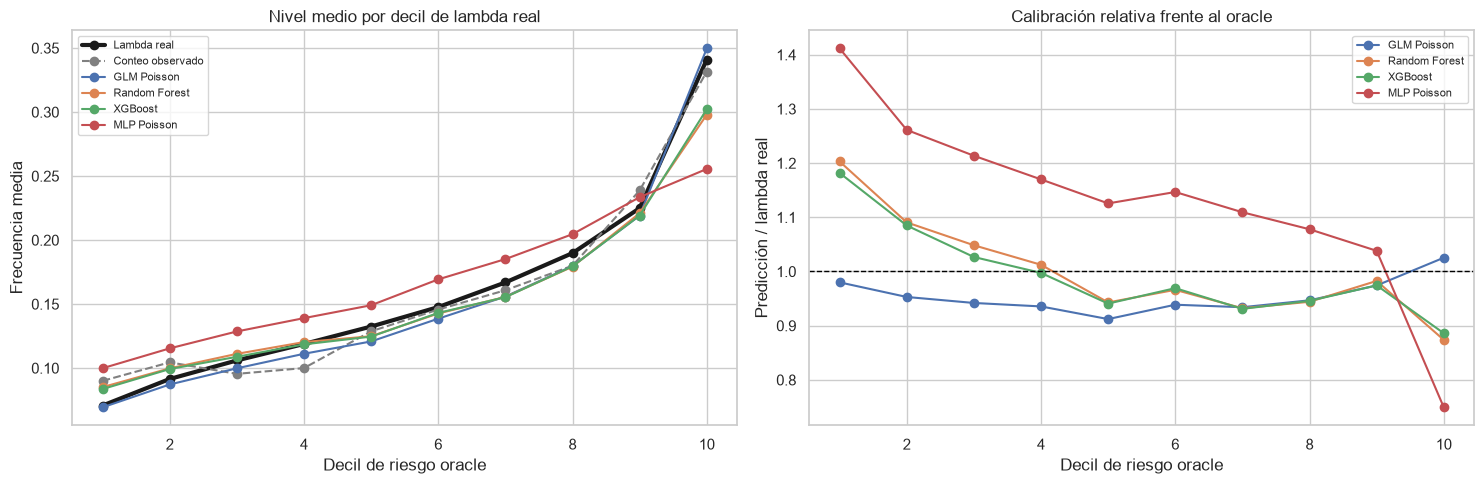

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(quantile_means["decil_riesgo"], quantile_means["lambda_real"], "k-o", lw=3, label="Lambda real")
axes[0].plot(quantile_means["decil_riesgo"], quantile_means["observado"], color="gray", marker="o", ls="--", label="Conteo observado")
for label, column in {
    "GLM Poisson": "GLM_Poisson", "Random Forest": "Random_Forest",
    "XGBoost": "XGBoost", "MLP Poisson": "MLP_Poisson",
}.items():
    axes[0].plot(quantile_means["decil_riesgo"], quantile_means[column], marker="o", label=label)
axes[0].set(title="Nivel medio por decil de lambda real", xlabel="Decil de riesgo oracle", ylabel="Frecuencia media")
axes[0].legend(fontsize=8)

for label, column in {
    "GLM Poisson": "ratio_GLM_Poisson_vs_oracle",
    "Random Forest": "ratio_Random_Forest_vs_oracle",
    "XGBoost": "ratio_XGBoost_vs_oracle",
    "MLP Poisson": "ratio_MLP_Poisson_vs_oracle",
}.items():
    axes[1].plot(quantile_means["decil_riesgo"], quantile_means[column], marker="o", label=label)
axes[1].axhline(1, color="black", ls="--", lw=1)
axes[1].set(title="Calibración relativa frente al oracle", xlabel="Decil de riesgo oracle", ylabel="Predicción / lambda real")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

El patrón por deciles revela una diferencia que la media agregada oculta. En el primer decil, Random Forest y XGBoost sobreestiman el oracle aproximadamente 20% y 18%; el MLP, cerca de 41%. En el décimo decil, los mismos modelos subestiman aproximadamente 13%, 11% y 25%. Esto es **compresión hacia el promedio**: reduce la separación entre riesgos bajos y altos y puede producir subsidios cruzados si las predicciones se trasladan directamente a tarifa.

El GLM permanece cerca del oracle en ambos extremos —aproximadamente −2% en el primer decil y +2.5% en el décimo—. La diferencia entre la línea observada y `lambda_real` no debe atribuirse automáticamente al modelo: representa la realización aleatoria de los conteos dentro de cada decil.

## 12. Predicción frente a `lambda_real`

La diagonal representa recuperación perfecta de la esperanza condicional. Separación vertical indica error de nivel; una nube con pendiente menor que uno sugiere compresión del rango; dispersión alrededor de una relación monotónica afecta Pearson y errores oracle, aunque Spearman puede mantenerse relativamente alto.

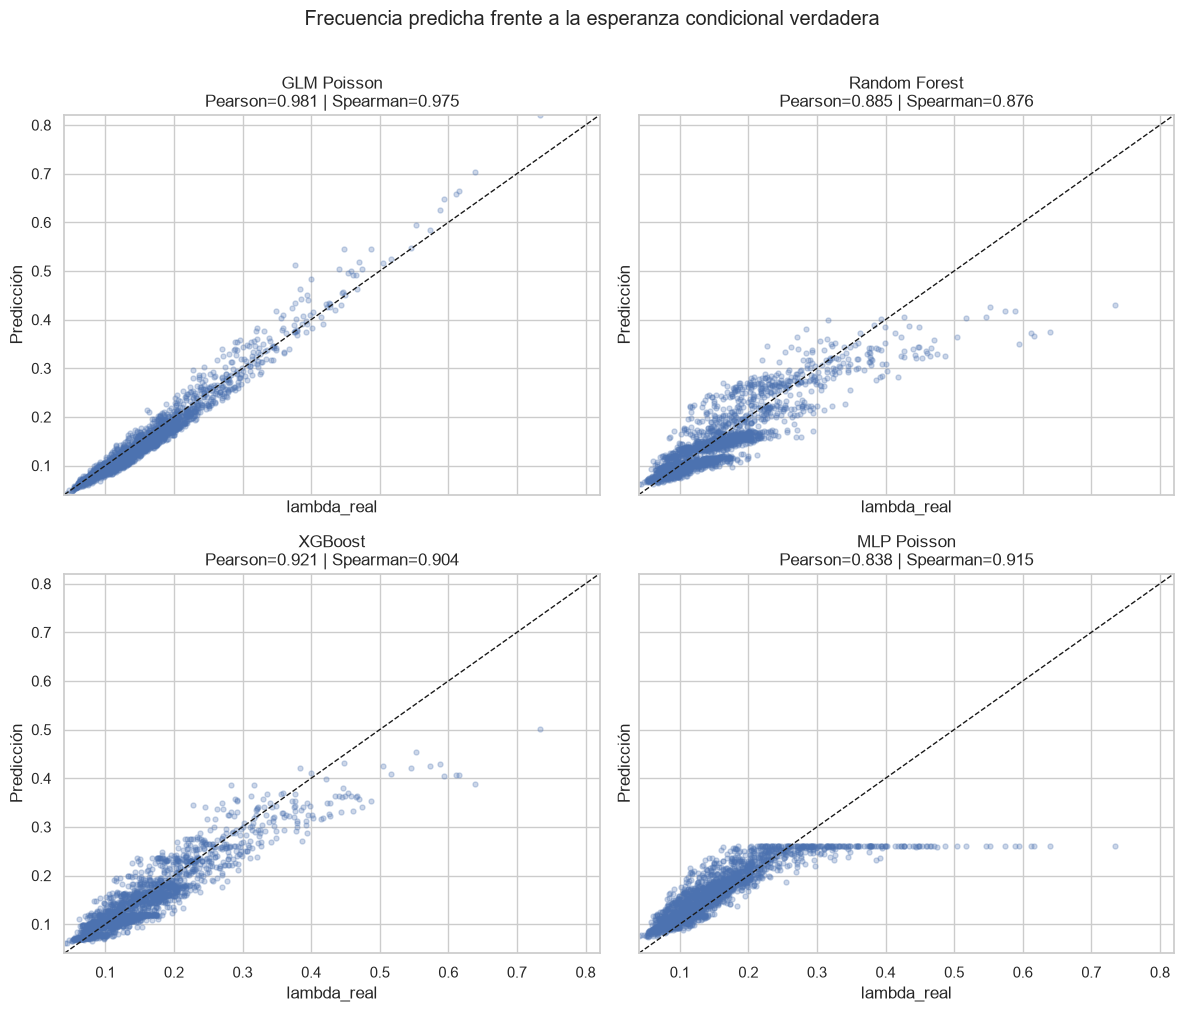

In [147]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
lower = min(policy_predictions["lambda_real"].min(), policy_predictions[list(FREQUENCY_MODELS.values())].min().min())
upper = max(policy_predictions["lambda_real"].max(), policy_predictions[list(FREQUENCY_MODELS.values())].max().max())

for ax, (model, column) in zip(axes.ravel(), FREQUENCY_MODELS.items()):
    ax.scatter(policy_predictions["lambda_real"], policy_predictions[column], s=13, alpha=0.28)
    ax.plot([lower, upper], [lower, upper], "k--", lw=1)
    pearson = frequency_diagnostics.loc[frequency_diagnostics.modelo.eq(model), "Pearson_lambda"].iloc[0]
    spearman = frequency_diagnostics.loc[frequency_diagnostics.modelo.eq(model), "Spearman_lambda"].iloc[0]
    ax.set(title=f"{model}\nPearson={pearson:.3f} | Spearman={spearman:.3f}", xlabel="lambda_real", ylabel="Predicción")
    ax.set_xlim(lower, upper); ax.set_ylim(lower, upper)

fig.suptitle("Frecuencia predicha frente a la esperanza condicional verdadera", y=1.01)
plt.tight_layout()
plt.show()

El gráfico hace visible la diferencia entre discriminación y calibración. Random Forest y XGBoost mantienen una relación creciente, pero sus máximos (`≈0.43` y `≈0.50`) quedan por debajo del máximo oracle (`≈0.73`). El MLP comprime aún más el rango (`≈0.074–0.262`): puede ordenar muchas pólizas correctamente —de ahí su Spearman relativamente alto— sin reproducir la magnitud de los extremos. El GLM cubre un rango más próximo al oracle, aunque genera algunas predicciones superiores al máximo oracle de esta muestra.

## 13. Distribución y rango de las predicciones

Los percentiles permiten distinguir cambios de centro, dispersión y extremos. Una distribución más estrecha no es necesariamente más robusta: también puede significar que el modelo suaviza excesivamente la heterogeneidad real.

,serie,mínimo,p01,p05,mediana,media,p95,p99,máximo,desv_est
0,Lambda real,0.040844,0.057960,0.072042,0.139387,0.158894,0.314129,0.448216,0.733814,0.079685
1,GLM Poisson,0.040308,0.056279,0.069737,0.130147,0.153042,0.326085,0.491360,0.820505,0.085314
2,Random Forest,0.061346,0.068949,0.077179,0.134811,0.153696,0.300868,0.364548,0.430154,0.069641
3,XGBoost,0.060755,0.069194,0.075930,0.130707,0.153349,0.300604,0.367928,0.500571,0.069154
4,MLP Poisson,0.073907,0.081954,0.093373,0.162419,0.167968,0.261104,0.261287,0.261748,0.052998


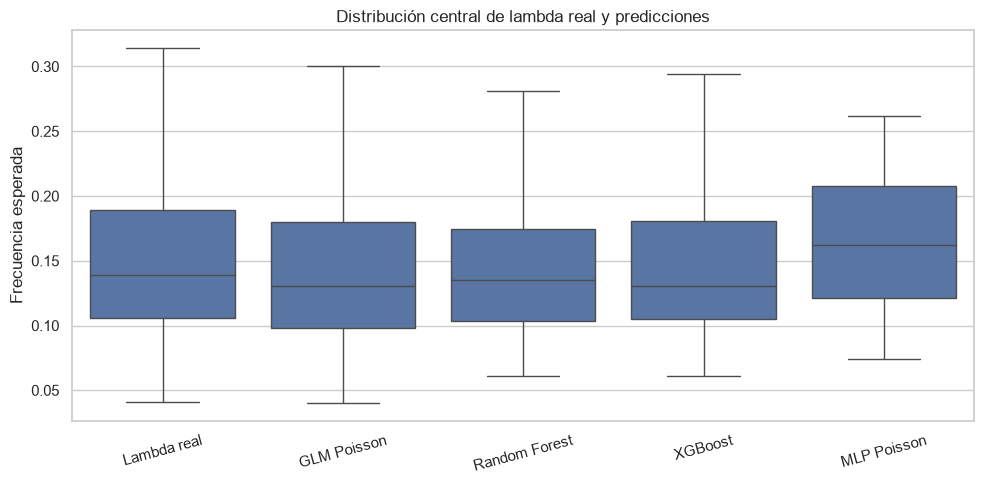

In [148]:
distribution_rows = []
for label, column in {"Lambda real": "lambda_real", **FREQUENCY_MODELS}.items():
    values = policy_predictions[column]
    distribution_rows.append({
        "serie": label, "mínimo": values.min(), "p01": values.quantile(.01),
        "p05": values.quantile(.05), "mediana": values.median(),
        "media": values.mean(), "p95": values.quantile(.95),
        "p99": values.quantile(.99), "máximo": values.max(), "desv_est": values.std(),
    })
frequency_prediction_distribution = pd.DataFrame(distribution_rows)
display(frequency_prediction_distribution.round(6))

long_predictions = policy_predictions[["lambda_real", *FREQUENCY_MODELS.values()]].rename(
    columns={"lambda_real": "Lambda real", **{v: k for k, v in FREQUENCY_MODELS.items()}}
).melt(var_name="serie", value_name="valor")

plt.figure(figsize=(10, 5))
sns.boxplot(data=long_predictions, x="serie", y="valor", showfliers=False)
plt.title("Distribución central de lambda real y predicciones")
plt.xlabel(""); plt.ylabel("Frecuencia esperada")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

**Interpretación.** El diagrama confirma que Random Forest, XGBoost y, con mayor intensidad, el MLP concentran sus predicciones de frecuencia en un intervalo más estrecho que `lambda_real`. La menor dispersión no implica por sí sola menor error: en este caso coincide con la sobreestimación de segmentos bajos y la subestimación de segmentos altos observada en los deciles.

## 14. Distribución de errores oracle

Se define \(e_i=\hat\lambda_i-\lambda_i\). Un error centrado cerca de cero indica ausencia de sesgo local en la mayor parte de la cartera; colas asimétricas muestran dónde el modelo falla con mayor intensidad. En particular, una cola negativa larga es consistente con subestimación de riesgos altos.

,media,mediana,desviación,mínimo,máximo
modelo,,,,,
GLM Poisson,-0.005852,-0.007024,0.016884,-0.037360,0.136095
MLP Poisson,0.009074,0.015319,0.045616,-0.472709,0.099807
Random Forest,-0.005199,-0.004112,0.037181,-0.303660,0.117901
XGBoost,-0.005545,-0.003939,0.031292,-0.251339,0.117077


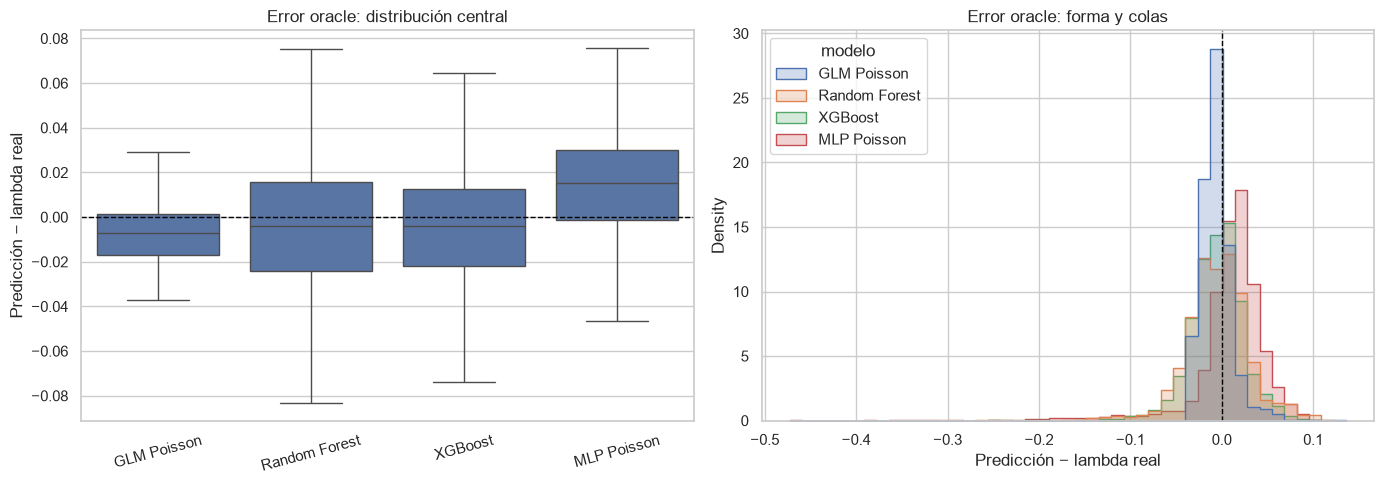

In [149]:
oracle_errors = pd.concat([
    pd.DataFrame({
        "modelo": model,
        "error_oracle": policy_predictions[column] - policy_predictions["lambda_real"],
    })
    for model, column in FREQUENCY_MODELS.items()
], ignore_index=True)

error_summary = oracle_errors.groupby("modelo")["error_oracle"].agg(
    media="mean", mediana="median", desviación="std",
    mínimo="min", máximo="max",
)
display(error_summary.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=oracle_errors, x="modelo", y="error_oracle", showfliers=False, ax=axes[0])
axes[0].axhline(0, color="black", ls="--", lw=1)
axes[0].set(title="Error oracle: distribución central", xlabel="", ylabel="Predicción − lambda real")
axes[0].tick_params(axis="x", rotation=15)

sns.histplot(data=oracle_errors, x="error_oracle", hue="modelo", element="step", stat="density", common_norm=False, bins=45, ax=axes[1])
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set(title="Error oracle: forma y colas", xlabel="Predicción − lambda real")

plt.tight_layout(); plt.show()

Las colas negativas de los modelos flexibles confirman que sus mayores errores aparecen al subestimar pólizas de riesgo alto. El MLP tiene una mediana positiva, coherente con la sobreestimación agregada, pero simultáneamente una cola negativa mucho más larga: sobreestima buena parte de los riesgos bajos y subestima los extremos altos. La media agregada por sí sola no mostraría esta combinación.

## 15. Perfiles marginales por variables de riesgo

Las predicciones DL conservan las seis features originales de test, lo que permite contrastar perfiles descriptivos. Para variables numéricas se agrupa por cuantiles; para categóricas se calcula la media por categoría.

Estos gráficos **no son efectos causales ni partial dependence**: cada punto promedia la distribución observada de las demás variables dentro del grupo. Su función es detectar si un modelo aplana, exagera o desplaza patrones visibles en `lambda_real`.

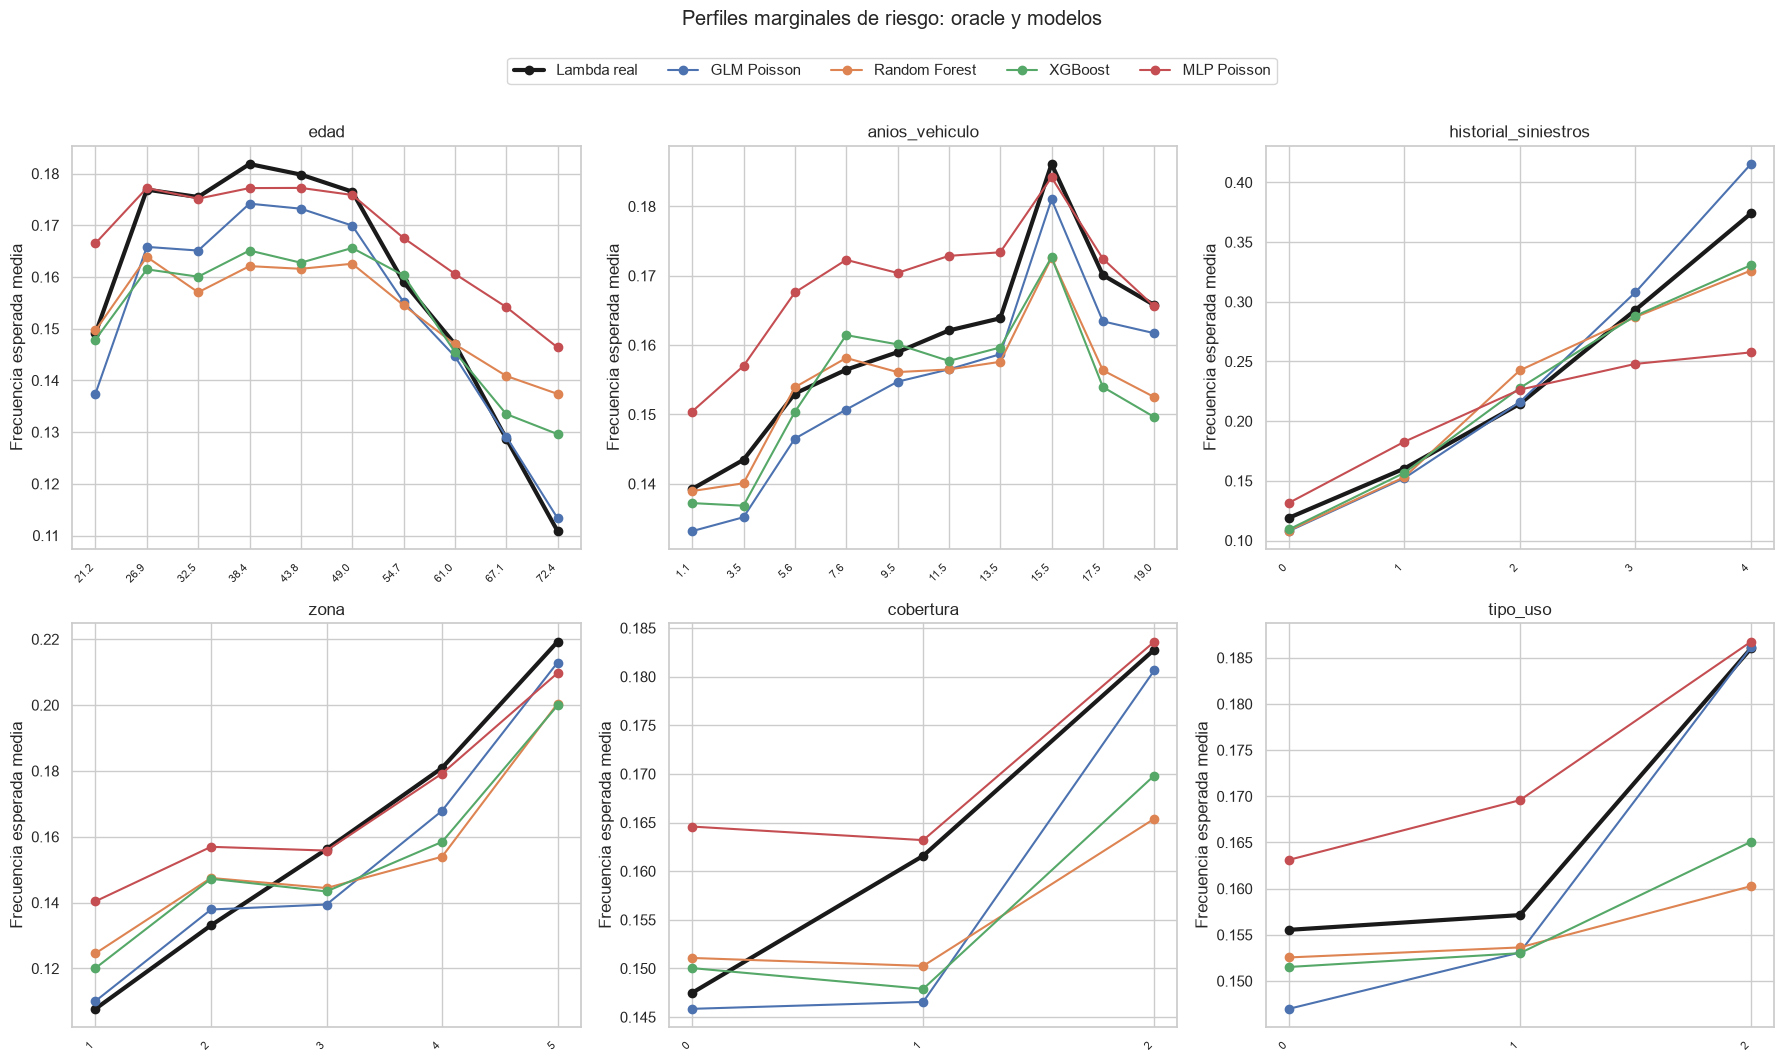

In [150]:
FEATURES = ["edad", "anios_vehiculo", "historial_siniestros", "zona", "cobertura", "tipo_uso"]
missing_features = [f for f in FEATURES if f not in policy_predictions.columns]
assert not missing_features, f"No están disponibles las features: {missing_features}"

def feature_profile(frame, feature):
    columns = [feature, "lambda_real", *FREQUENCY_MODELS.values()]
    data = frame[columns].dropna().copy()
    if pd.api.types.is_numeric_dtype(data[feature]) and data[feature].nunique() > 10:
        data["grupo"] = pd.qcut(data[feature], q=10, duplicates="drop")
        profile = data.groupby("grupo", observed=True).mean(numeric_only=True)
        profile["etiqueta"] = profile[feature].round(1).astype(str)
    else:
        profile = data.groupby(feature, observed=True).mean(numeric_only=True)
        profile = profile.sort_values("lambda_real")
        profile["etiqueta"] = profile.index.astype(str)
    return profile.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feature in zip(axes.ravel(), FEATURES):
    profile = feature_profile(policy_predictions, feature)
    x = np.arange(len(profile))
    ax.plot(x, profile["lambda_real"], "k-o", lw=3, label="Lambda real")
    for model, column in FREQUENCY_MODELS.items():
        ax.plot(x, profile[column], marker="o", label=model)
    ax.set_title(feature)
    ax.set_xticks(x)
    ax.set_xticklabels(profile["etiqueta"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Frecuencia esperada media")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Perfiles marginales de riesgo: oracle y modelos", y=1.06)
plt.tight_layout(); plt.show()

**Interpretación.** Los perfiles marginales muestran que los modelos coinciden mejor en zonas densas de las features y divergen en niveles asociados con riesgos extremos. El GLM sigue más de cerca la forma media del oracle; los modelos flexibles tienden a suavizarla. Como las demás variables no se fijan, estos perfiles describen asociaciones de la muestra y no efectos causales.

### Síntesis de frecuencia, sin ganador global

- **Conteo observado:** los cuatro modelos tienen RMSE y Poisson deviance muy próximos. La aleatoriedad del conteo limita cuánto se separan en estas métricas individuales.
- **Esperanza condicional:** las diferencias oracle son bastante mayores. El GLM reproduce con especial precisión el DGP correctamente especificado; XGBoost es el modelo flexible más próximo en escala lineal, mientras Random Forest y MLP muestran mayor error de nivel.
- **Ordenamiento:** todos conservan señal. Pearson y Spearman no son intercambiables: el MLP ordena mejor de lo que calibra linealmente, evidenciado por `Spearman > Pearson`.
- **Calibración:** GLM, Random Forest y XGBoost subestiman ligeramente el promedio; el MLP lo sobreestima. Por deciles, los modelos flexibles comprimen el rango, elevando riesgos bajos y reduciendo riesgos altos.
- **Implicación práctica:** dos modelos con error observado casi idéntico pueden producir segmentaciones tarifarias distintas. En un DGP donde la forma paramétrica está bien especificada, la complejidad adicional no garantiza recuperar mejor la heterogeneidad real; puede aportar flexibilidad, pero también suavizar extremos y dificultar la calibración.

Esta síntesis se limita a frecuencia. No se combina con severidad o prima pura y no se utiliza para retunear ninguno de los modelos congelados.

# Fase 3 — Comparación de severidad

Esta fase utiliza exclusivamente las predicciones finales a nivel claim ya alineadas por `claim_id` durante la fase 1. Se comparan:

- GLM Gamma;
- OLS sobre log-severidad con corrección de Duan;
- Random Forest;
- XGBoost;
- MLP Gamma.

La distinción central es entre la severidad observada \(Y_i\) y su esperanza condicional verdadera \(\mu_i=E[Y_i\mid X_i]\):

- comparar \(\hat\mu_i\) con `severidad` incluye tanto ruido individual del claim como error del modelo;
- comparar \(\hat\mu_i\) con `severidad_esperada_real` mide directamente qué tan bien se recuperó la media condicional del DGP.

No se analiza todavía prima pura y los modelos permanecen congelados.

In [151]:
SEVERITY_MODELS = {
    "GLM Gamma": "sev_glm_gamma",
    "Log-severidad + Duan": "sev_log_duan",
    "Random Forest": "sev_rf",
    "XGBoost": "sev_xgb",
    "MLP Gamma": "sev_mlp",
}

required_severity_columns = {
    "claim_id", "policy_id", "severidad", "severidad_esperada_real",
    *SEVERITY_MODELS.values(),
}
missing_severity_columns = required_severity_columns - set(severity_predictions.columns)
assert not missing_severity_columns, f"Faltan columnas de severidad: {sorted(missing_severity_columns)}"
assert severity_predictions["claim_id"].is_unique
assert (severity_predictions[["severidad", "severidad_esperada_real", *SEVERITY_MODELS.values()]] > 0).all().all()

print(f"Base común de severidad: {len(severity_predictions):,} claims.")
print(f"Pólizas representadas: {severity_predictions['policy_id'].nunique():,}.")

Base común de severidad: 315 claims.
Pólizas representadas: 292.


## 16. Métricas contra la realización y contra el oracle

MAE, RMSE y Gamma deviance contra `severidad` evalúan predicción de claims realizados. Estas métricas son necesarias para uso operativo, pero incluyen la variación Gamma que persiste incluso si se conoce exactamente \(E[Y\mid X]\).

Oracle MAE y Oracle RMSE comparan con `severidad_esperada_real`. Pearson mide asociación lineal con la media verdadera; Spearman mide si las pólizas se ordenan correctamente por severidad esperada. Una correlación alta no garantiza calibración de nivel.

In [152]:
severity_diagnostic_rows = []
y_severity = severity_predictions["severidad"].to_numpy(float)
mu_severity = severity_predictions["severidad_esperada_real"].to_numpy(float)

for model, column in SEVERITY_MODELS.items():
    pred = severity_predictions[column].to_numpy(float)
    severity_diagnostic_rows.append({
        "modelo": model,
        "MAE_test": mean_absolute_error(y_severity, pred),
        "RMSE_test": np.sqrt(np.mean((y_severity - pred) ** 2)),
        "Gamma_deviance_test": mean_gamma_deviance(y_severity, pred),
        "Oracle_MAE": mean_absolute_error(mu_severity, pred),
        "Oracle_RMSE": np.sqrt(np.mean((mu_severity - pred) ** 2)),
        "Pearson_mu": np.corrcoef(mu_severity, pred)[0, 1],
        "Spearman_mu": spearmanr(mu_severity, pred).statistic,
    })

severity_diagnostics = pd.DataFrame(severity_diagnostic_rows)

published_severity = severity_metrics[[
    "modelo", "MAE_test", "RMSE_test", "Gamma_deviance_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
]].copy()
severity_metric_audit = severity_diagnostics.merge(
    published_severity, on="modelo", validate="one_to_one", suffixes=("_recalculado", "_publicado")
)
for metric in ["MAE_test", "RMSE_test", "Gamma_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    assert np.allclose(
        severity_metric_audit[f"{metric}_recalculado"],
        severity_metric_audit[f"{metric}_publicado"],
        rtol=1e-6, atol=1e-6,
    ), f"La métrica {metric} no coincide con su CSV."
assert np.allclose(
    severity_metric_audit["Pearson_mu"], severity_metric_audit["Oracle_correlation"],
    rtol=1e-6, atol=1e-8,
)

display(severity_diagnostics.round(6))

,modelo,MAE_test,RMSE_test,Gamma_deviance_test,Oracle_MAE,Oracle_RMSE,Pearson_mu,Spearman_mu
0,GLM Gamma,5689.121329,8821.826163,0.317156,696.646021,1043.530463,0.982558,0.992875
1,Log-severidad + Duan,5677.705139,8807.103748,0.315653,705.662194,1068.387468,0.981217,0.993489
2,Random Forest,5757.483089,8925.693274,0.325031,1024.247097,1431.764012,0.971030,0.973563
3,XGBoost,5640.362901,8861.761419,0.318965,806.398961,1285.295753,0.975129,0.984201
4,MLP Gamma,5820.470445,8962.862783,0.322431,1159.052506,1643.348541,0.950288,0.968953


### Qué significan las diferencias

Contra la severidad observada, los resultados están relativamente próximos: el MAE se mueve aproximadamente entre 5,640 y 5,820; el RMSE, entre 8,807 y 8,963; y la Gamma deviance, entre 0.3157 y 0.3250. Estas cifras están dominadas por la variabilidad individual de los claims.

Contra el oracle, la separación es mucho mayor. GLM Gamma y log-severidad + Duan tienen Oracle RMSE cercanos a 1,044 y 1,068. XGBoost alcanza aproximadamente 1,285; Random Forest, 1,432; y MLP Gamma, 1,643. En consecuencia, diferencias pequeñas en error observado pueden coexistir con diferencias claras en la recuperación de la esperanza condicional.

El modelo log-severidad + Duan obtiene ligeramente menor error observado y Gamma deviance que GLM Gamma, pero su Oracle MAE y RMSE son ligeramente mayores. Esto no es contradictorio: en esta muestra concreta puede alinearse algo mejor con realizaciones aleatorias sin aproximar mejor la función condicional verdadera.

## 17. Comparación relativa con GLM Gamma

GLM Gamma se fija como referencia estadística principal porque modela directamente una media positiva bajo varianza Gamma. El modelo log+Duan se conserva como segunda referencia estadística. Para errores se reporta el cambio porcentual respecto al GLM; para correlaciones, diferencias absolutas.

In [153]:
glm_gamma_reference = severity_diagnostics.loc[
    severity_diagnostics["modelo"].eq("GLM Gamma")
].iloc[0]

severity_relative = severity_diagnostics[["modelo"]].copy()
for metric in ["MAE_test", "RMSE_test", "Gamma_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    severity_relative[f"Δ {metric} vs GLM Gamma (%)"] = 100 * (
        severity_diagnostics[metric] / glm_gamma_reference[metric] - 1
    )
for metric in ["Pearson_mu", "Spearman_mu"]:
    severity_relative[f"Δ {metric} vs GLM Gamma"] = (
        severity_diagnostics[metric] - glm_gamma_reference[metric]
    )

display(severity_relative.round(3))

,modelo,Δ MAE_test vs GLM Gamma (%),Δ RMSE_test vs GLM Gamma (%),Δ Gamma_deviance_test vs GLM Gamma (%),Δ Oracle_MAE vs GLM Gamma (%),Δ Oracle_RMSE vs GLM Gamma (%),Δ Pearson_mu vs GLM Gamma,Δ Spearman_mu vs GLM Gamma
0,GLM Gamma,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Log-severidad + Duan,-0.201,-0.167,-0.474,1.294,2.382,-0.001,0.001
2,Random Forest,1.202,1.177,2.483,47.025,37.204,-0.012,-0.019
3,XGBoost,-0.857,0.453,0.571,15.754,23.168,-0.007,-0.009
4,MLP Gamma,2.309,1.599,1.663,66.376,57.480,-0.032,-0.024


Las mejoras observadas del modelo log+Duan frente al GLM Gamma son menores a 0.5%, mientras su Oracle RMSE aumenta alrededor de 2.4%. XGBoost reduce el MAE observado alrededor de 0.9%, pero aumenta el Oracle RMSE cerca de 23%. Random Forest y MLP muestran incrementos todavía mayores en error oracle. La lectura adecuada no es que una métrica sea “correcta” y la otra no: miden componentes distintos del problema.

## 18. ¿Cuánto error proviene del ruido individual?

El oracle permite construir un benchmark inalcanzable en datos reales: usar directamente \(\mu_i\) como predicción. Su error contra \(Y_i\) es puro ruido de realización.

Para RMSE se obtiene además una descomposición exacta. Definiendo:

\[
\varepsilon_i=Y_i-\mu_i,
\qquad
\delta_i=\mu_i-\hat\mu_i,
\]

entonces:

\[
\operatorname{MSE}(Y,\hat\mu)
=E[\varepsilon^2]+E[\delta^2]+2E[\varepsilon\delta].
\]

El primer término es ruido individual; el segundo es error de estimación de la esperanza condicional; el tercero es una interacción muestral. En la población, bajo una media condicional correcta y un predictor función de \(X\), se espera que la interacción sea cero. En sólo 315 claims puede no serlo.

In [154]:
oracle_as_predictor = pd.DataFrame([{
    "predictor": "severidad_esperada_real",
    "MAE_observado": mean_absolute_error(y_severity, mu_severity),
    "RMSE_observado": np.sqrt(np.mean((y_severity - mu_severity) ** 2)),
    "Gamma_deviance_observada": mean_gamma_deviance(y_severity, mu_severity),
    "media_observada": y_severity.mean(),
    "media_oracle": mu_severity.mean(),
}])
display(oracle_as_predictor.round(6))

claim_noise = y_severity - mu_severity
noise_mse = np.mean(claim_noise ** 2)
decomposition_rows = []

for model, column in SEVERITY_MODELS.items():
    pred = severity_predictions[column].to_numpy(float)
    estimation_error = mu_severity - pred
    observed_mse = np.mean((y_severity - pred) ** 2)
    estimation_mse = np.mean(estimation_error ** 2)
    interaction = 2 * np.mean(claim_noise * estimation_error)
    decomposition_rows.append({
        "modelo": model,
        "MSE_observado": observed_mse,
        "MSE_ruido_claim": noise_mse,
        "MSE_estimación_media": estimation_mse,
        "interacción_muestral": interaction,
        "% MSE ruido": 100 * noise_mse / observed_mse,
        "% MSE estimación": 100 * estimation_mse / observed_mse,
        "% MSE interacción": 100 * interaction / observed_mse,
        "error_identidad": observed_mse - noise_mse - estimation_mse - interaction,
    })

severity_mse_decomposition = pd.DataFrame(decomposition_rows)
display(severity_mse_decomposition.round(4))
assert np.allclose(severity_mse_decomposition["error_identidad"], 0, atol=1e-6)

,predictor,MAE_observado,RMSE_observado,Gamma_deviance_observada,media_observada,media_oracle
0,severidad_esperada_real,5616.968636,8743.140025,0.313367,12753.534055,12820.099326


,modelo,MSE_observado,MSE_ruido_claim,MSE_estimación_media,interacción_muestral,% MSE ruido,% MSE estimación,% MSE interacción,error_identidad
0,GLM Gamma,7.782462e+07,7.644250e+07,1.088956e+06,2.931635e+05,98.2241,1.3992,0.3767,-0.0
1,Log-severidad + Duan,7.756508e+07,7.644250e+07,1.141452e+06,-1.887285e+04,98.5527,1.4716,-0.0243,-0.0
2,Random Forest,7.966800e+07,7.644250e+07,2.049948e+06,1.175555e+06,95.9513,2.5731,1.4756,-0.0
3,XGBoost,7.853082e+07,7.644250e+07,1.651985e+06,4.363328e+05,97.3408,2.1036,0.5556,-0.0
4,MLP Gamma,8.033291e+07,7.644250e+07,2.700594e+06,1.189817e+06,95.1571,3.3618,1.4811,-0.0


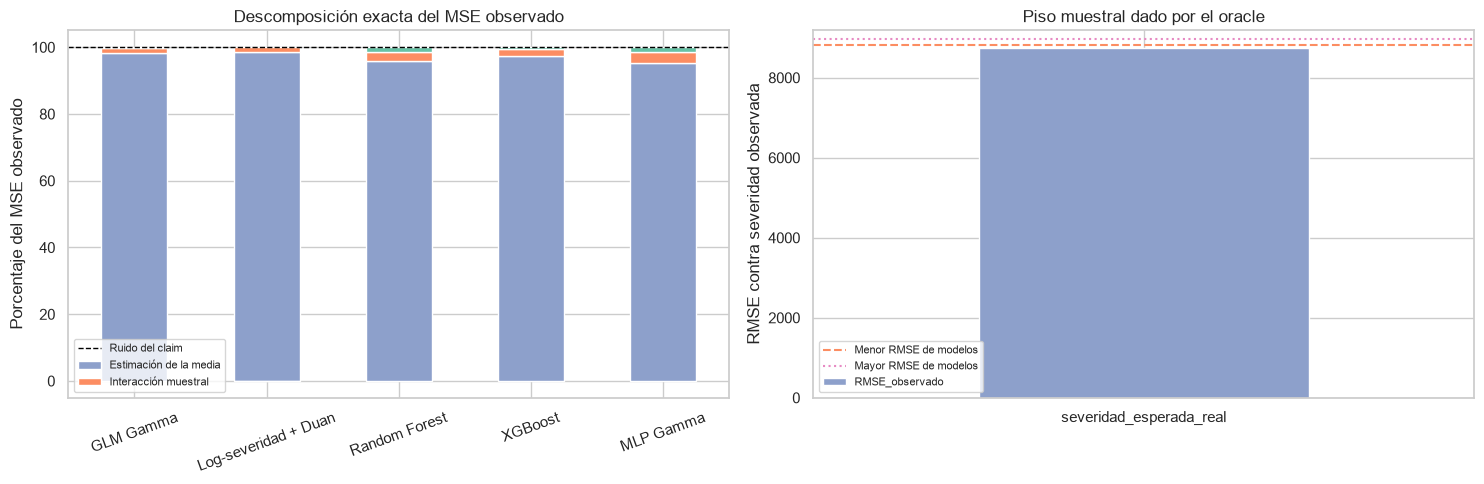

In [155]:
decomposition_plot = severity_mse_decomposition.set_index("modelo")[[
    "% MSE ruido", "% MSE estimación", "% MSE interacción"
]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
decomposition_plot.plot(kind="bar", stacked=True, ax=axes[0], color=["#8da0cb", "#fc8d62", "#66c2a5"])
axes[0].axhline(100, color="black", ls="--", lw=1)
axes[0].set(title="Descomposición exacta del MSE observado", xlabel="", ylabel="Porcentaje del MSE observado")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(["Ruido del claim", "Estimación de la media", "Interacción muestral"], fontsize=8)

oracle_as_predictor.set_index("predictor")[["RMSE_observado"]].plot(kind="bar", ax=axes[1], color="#8da0cb", legend=False)
axes[1].axhline(severity_diagnostics["RMSE_test"].min(), color="#fc8d62", ls="--", label="Menor RMSE de modelos")
axes[1].axhline(severity_diagnostics["RMSE_test"].max(), color="#e78ac3", ls=":", label="Mayor RMSE de modelos")
axes[1].set(title="Piso muestral dado por el oracle", xlabel="", ylabel="RMSE contra severidad observada")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

El oracle mismo tiene MAE observado cercano a 5,617 y RMSE cercano a 8,743. Los modelos presentan RMSE entre aproximadamente 8,807 y 8,963: la mayor parte de su error observable seguiría existiendo incluso con conocimiento perfecto de la media condicional.

En términos de MSE, el ruido individual explica aproximadamente entre 95% y 99% del error observado, según el modelo. El error puro al estimar la media representa cerca de 1.4% para GLM Gamma, 1.5% para log+Duan, 2.1% para XGBoost, 2.6% para Random Forest y 3.4% para MLP Gamma. La interacción completa la identidad y depende de esta muestra particular.

Esta descomposición no debe interpretarse como que mejorar el modelo carece de valor. Una reducción pequeña del error total puede corresponder a una reducción importante del componente controlable —la estimación de \(E[Y\mid X]\)— porque el componente de ruido no puede eliminarse.

## 19. Realización individual frente a esperanza condicional

El siguiente gráfico muestra directamente por qué evaluar sólo contra claims observados puede ocultar diferencias estructurales. La dispersión vertical alrededor de la diagonal es variación individual Gamma; `severidad_esperada_real` describe el centro, no el valor exacto que debe tomar cada claim.

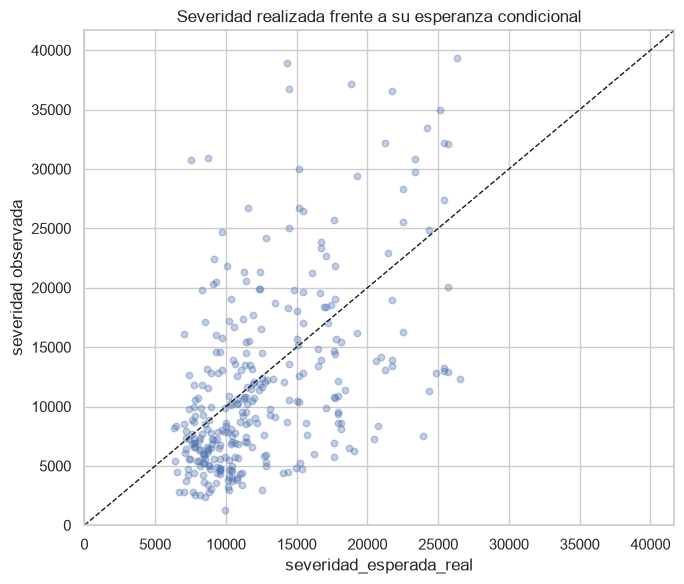

In [156]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(severity_predictions["severidad_esperada_real"], severity_predictions["severidad"], s=22, alpha=.35)
limit = np.percentile(np.r_[severity_predictions["severidad_esperada_real"], severity_predictions["severidad"]], 99)
ax.plot([0, limit], [0, limit], "k--", lw=1)
ax.set_xlim(0, limit); ax.set_ylim(0, limit)
ax.set(
    title="Severidad realizada frente a su esperanza condicional",
    xlabel="severidad_esperada_real", ylabel="severidad observada",
)
plt.tight_layout(); plt.show()

**Interpretación.** La gran dispersión de `severidad` alrededor de la diagonal demuestra que una predicción de la media condicional no pretende acertar el monto exacto de cada claim. Incluso el oracle queda lejos de numerosas realizaciones; por ello las diferencias pequeñas de RMSE observado no deben confundirse con equivalencia en recuperación de la señal.

## 20. Predicción frente a `severidad_esperada_real`

Ahora se elimina visualmente el ruido individual y se contrasta cada modelo con la función objetivo. Cercanía a la diagonal implica calibración de nivel; una relación creciente sostiene discriminación; una pendiente visual menor que uno sugiere compresión del rango.

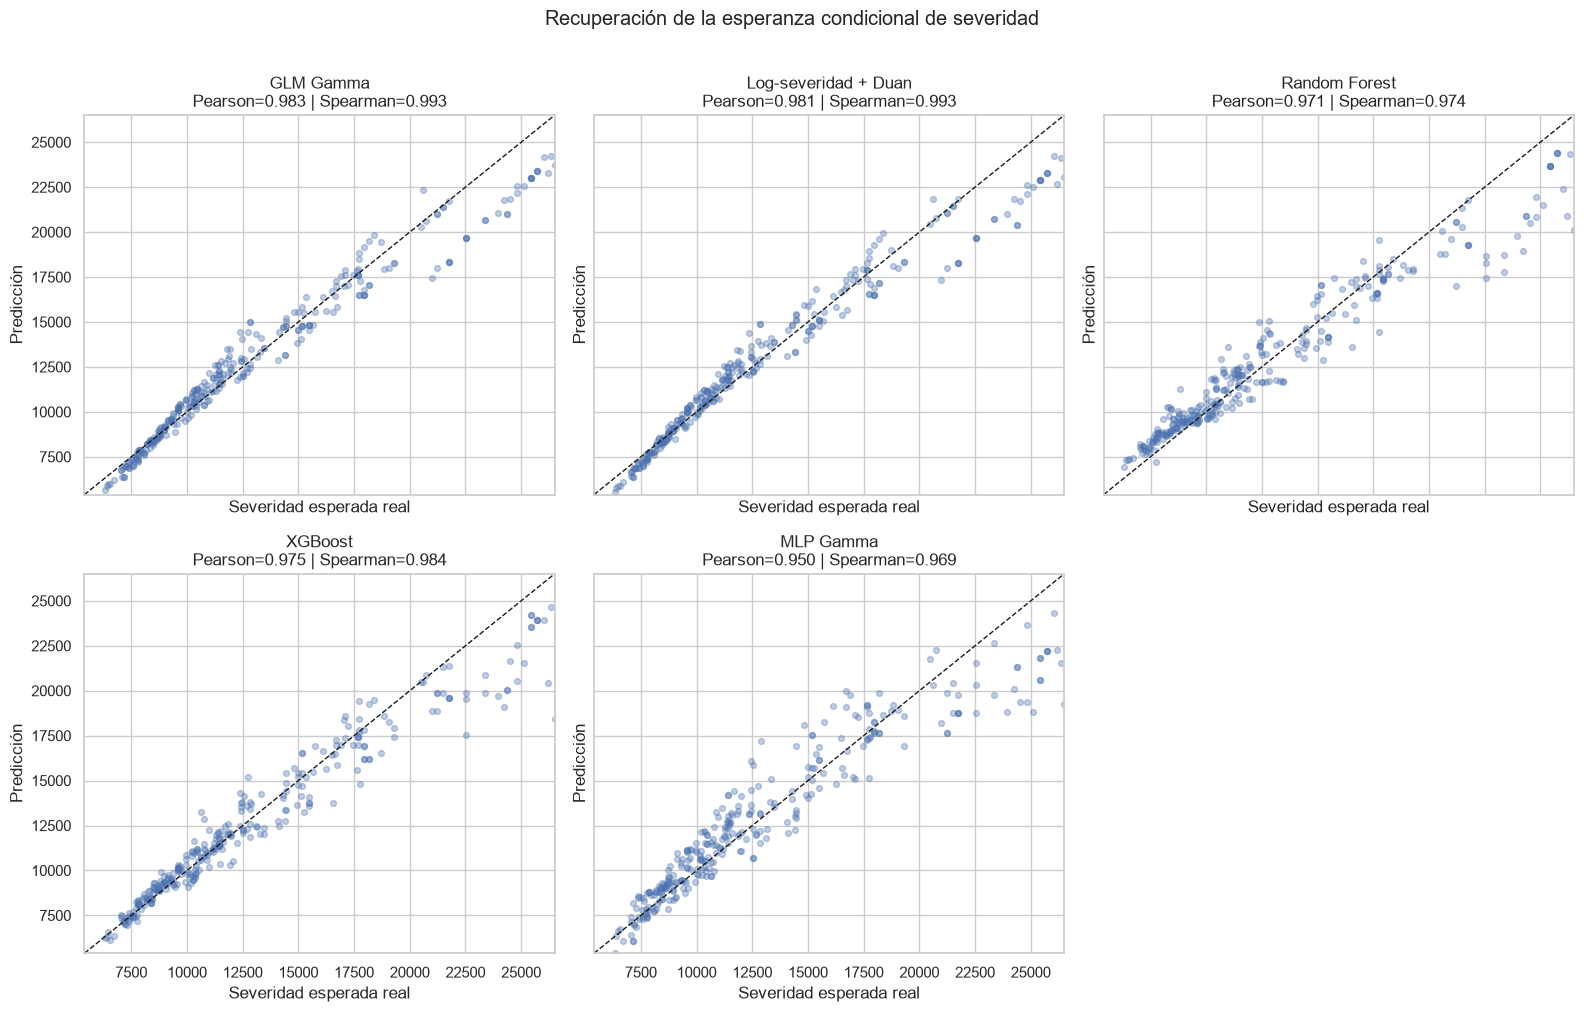

In [157]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()
lower = min(severity_predictions["severidad_esperada_real"].min(), severity_predictions[list(SEVERITY_MODELS.values())].min().min())
upper = max(severity_predictions["severidad_esperada_real"].max(), severity_predictions[list(SEVERITY_MODELS.values())].max().max())

for ax, (model, column) in zip(axes, SEVERITY_MODELS.items()):
    ax.scatter(severity_predictions["severidad_esperada_real"], severity_predictions[column], s=18, alpha=.35)
    ax.plot([lower, upper], [lower, upper], "k--", lw=1)
    pearson = severity_diagnostics.loc[severity_diagnostics.modelo.eq(model), "Pearson_mu"].iloc[0]
    spearman = severity_diagnostics.loc[severity_diagnostics.modelo.eq(model), "Spearman_mu"].iloc[0]
    ax.set(title=f"{model}\nPearson={pearson:.3f} | Spearman={spearman:.3f}", xlabel="Severidad esperada real", ylabel="Predicción")
    ax.set_xlim(lower, upper); ax.set_ylim(lower, upper)

axes[-1].axis("off")
fig.suptitle("Recuperación de la esperanza condicional de severidad", y=1.01)
plt.tight_layout(); plt.show()

Los dos modelos estadísticos muestran una relación casi lineal con el oracle y correlaciones cercanas a 0.98–0.99. Log+Duan obtiene un Spearman marginalmente superior al GLM Gamma, aunque su error de nivel oracle es algo mayor: ordenamiento y calibración no son la misma propiedad.

Random Forest, XGBoost y MLP mantienen una señal clara, pero exhiben más dispersión o suavización en los extremos. Esto afecta Oracle RMSE aun cuando el error contra la realización individual apenas cambie.

## 21. Calibración por cuantiles de severidad esperada

Se forman deciles mediante `severidad_esperada_real`. Cada grupo contiene aproximadamente 31–32 claims, por lo que la media observada todavía puede fluctuar de forma considerable. La línea oracle es la referencia para calibración condicional; la línea observada ilustra el ruido que permanece después de agrupar.

In [158]:
severity_quantiles = severity_predictions[[
    "claim_id", "severidad", "severidad_esperada_real", *SEVERITY_MODELS.values()
]].copy()
severity_quantiles["decil_riesgo"] = pd.qcut(
    severity_quantiles["severidad_esperada_real"], q=10, labels=range(1, 11), duplicates="drop"
)

severity_quantile_means = severity_quantiles.groupby("decil_riesgo", observed=True).agg(
    n=("claim_id", "size"),
    observado=("severidad", "mean"),
    oracle=("severidad_esperada_real", "mean"),
    GLM_Gamma=("sev_glm_gamma", "mean"),
    Log_Duan=("sev_log_duan", "mean"),
    Random_Forest=("sev_rf", "mean"),
    XGBoost=("sev_xgb", "mean"),
    MLP_Gamma=("sev_mlp", "mean"),
).reset_index()

for column in ["GLM_Gamma", "Log_Duan", "Random_Forest", "XGBoost", "MLP_Gamma"]:
    severity_quantile_means[f"ratio_{column}_vs_oracle"] = (
        severity_quantile_means[column] / severity_quantile_means["oracle"]
    )

display(severity_quantile_means.round(4))

,decil_riesgo,n,observado,oracle,GLM_Gamma,Log_Duan,Random_Forest,XGBoost,MLP_Gamma,ratio_GLM_Gamma_vs_oracle,ratio_Log_Duan_vs_oracle,ratio_Random_Forest_vs_oracle,ratio_XGBoost_vs_oracle,ratio_MLP_Gamma_vs_oracle
0,1,32,7830.3917,7293.3340,6891.4960,6827.0565,8021.7845,7305.1340,7340.8477,0.9449,0.9361,1.0999,1.0016,1.0065
1,2,33,7508.7602,8257.5261,8152.8540,8126.1183,9121.9566,8538.9109,8668.1827,0.9873,0.9841,1.1047,1.0341,1.0497
2,3,30,9518.1693,9004.8730,9155.1120,9118.2265,9608.9332,9315.2825,9433.5925,1.0167,1.0126,1.0671,1.0345,1.0476
3,4,32,8339.6927,9904.8405,10275.7624,10244.2494,10113.9627,10073.3985,10533.8319,1.0374,1.0343,1.0211,1.0170,1.0635
4,5,31,8495.3549,10706.9915,11025.5628,11031.8282,11154.8760,10898.8689,11227.9526,1.0298,1.0303,1.0418,1.0179,1.0487
5,6,32,12366.2868,11653.5517,12304.6096,12305.5925,12010.8495,11743.0147,12651.8712,1.0559,1.0560,1.0307,1.0077,1.0857
6,7,32,15991.8693,13290.6893,13565.3260,13702.0317,13288.1967,13272.3564,13384.5795,1.0207,1.0309,0.9998,0.9986,1.0071
7,8,30,15706.7169,15825.6977,15683.3604,15814.1508,15759.6858,15611.2910,16456.8896,0.9910,0.9993,0.9958,0.9865,1.0399
8,9,33,16155.1822,18665.9519,18254.9793,18309.8743,17788.5291,17917.0985,18413.0439,0.9780,0.9809,0.9530,0.9599,0.9865
9,10,30,26381.5613,24148.8454,21714.2542,21601.3188,21099.0019,21300.6540,20662.7606,0.8992,0.8945,0.8737,0.8821,0.8556


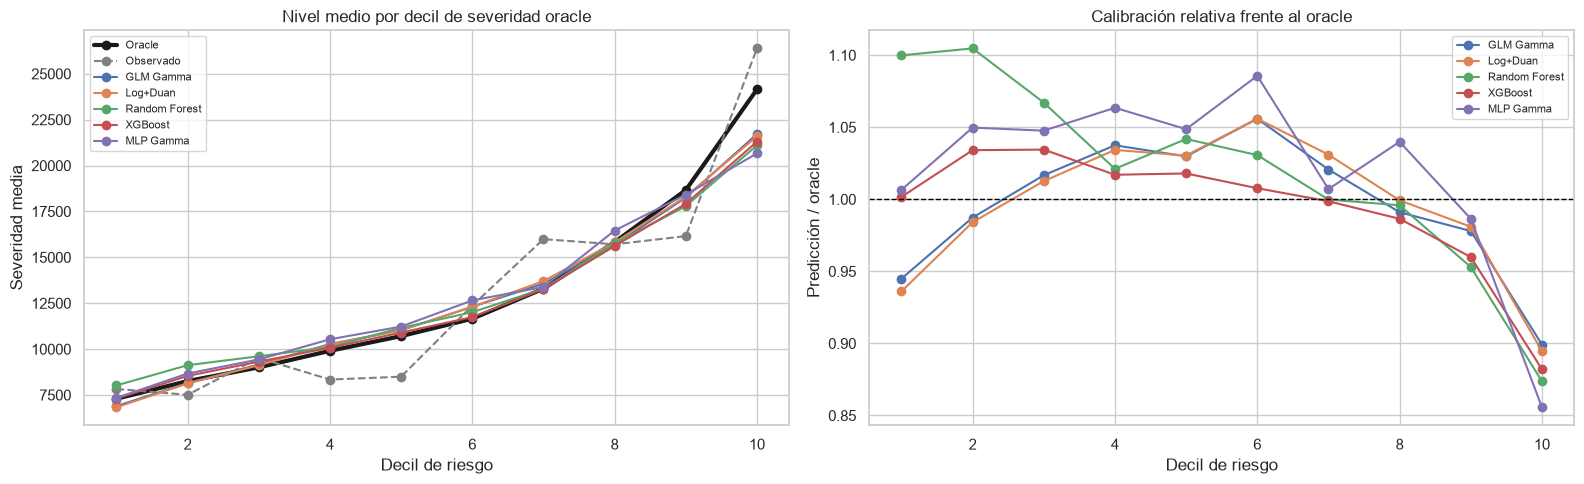

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(severity_quantile_means["decil_riesgo"], severity_quantile_means["oracle"], "k-o", lw=3, label="Oracle")
axes[0].plot(severity_quantile_means["decil_riesgo"], severity_quantile_means["observado"], color="gray", ls="--", marker="o", label="Observado")

severity_plot_columns = {
    "GLM Gamma": "GLM_Gamma", "Log+Duan": "Log_Duan", "Random Forest": "Random_Forest",
    "XGBoost": "XGBoost", "MLP Gamma": "MLP_Gamma",
}
for label, column in severity_plot_columns.items():
    axes[0].plot(severity_quantile_means["decil_riesgo"], severity_quantile_means[column], marker="o", label=label)
    axes[1].plot(severity_quantile_means["decil_riesgo"], severity_quantile_means[f"ratio_{column}_vs_oracle"], marker="o", label=label)

axes[0].set(title="Nivel medio por decil de severidad oracle", xlabel="Decil de riesgo", ylabel="Severidad media")
axes[0].legend(fontsize=8)
axes[1].axhline(1, color="black", ls="--", lw=1)
axes[1].set(title="Calibración relativa frente al oracle", xlabel="Decil de riesgo", ylabel="Predicción / oracle")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

La media observada por decil no sigue de forma perfectamente suave al oracle: por ejemplo, algunos deciles intermedios intercambian posiciones debido al ruido individual y al tamaño reducido de los grupos. Esto refuerza por qué no conviene evaluar recuperación de riesgo únicamente con realizaciones.

Los modelos estadísticos siguen de cerca al oracle en buena parte del rango, aunque subestiman el decil superior alrededor de 10%. Los modelos flexibles también comprimen el extremo alto; el MLP presenta la mayor subestimación en ese decil, cercana a 14%. La calibración agregada puede seguir siendo buena porque desviaciones positivas y negativas se compensan.

## 22. Calibración agregada y distribución de predicciones

La media predicha se contrasta tanto con la media observada como con la media oracle. También se resumen rango y percentiles para detectar suavización de heterogeneidad.

In [160]:
severity_aggregate_rows = []
for model, column in SEVERITY_MODELS.items():
    values = severity_predictions[column]
    severity_aggregate_rows.append({
        "modelo": model,
        "media_observada": severity_predictions["severidad"].mean(),
        "media_oracle": severity_predictions["severidad_esperada_real"].mean(),
        "media_predicha": values.mean(),
        "sesgo_vs_observado_%": 100 * (values.mean() / severity_predictions["severidad"].mean() - 1),
        "sesgo_vs_oracle_%": 100 * (values.mean() / severity_predictions["severidad_esperada_real"].mean() - 1),
        "mínimo": values.min(), "p05": values.quantile(.05), "mediana": values.median(),
        "p95": values.quantile(.95), "máximo": values.max(),
    })

severity_aggregate_calibration = pd.DataFrame(severity_aggregate_rows)
display(severity_aggregate_calibration.round(4))

,modelo,media_observada,media_oracle,media_predicha,sesgo_vs_observado_%,sesgo_vs_oracle_%,mínimo,p05,mediana,p95,máximo
0,GLM Gamma,12753.5341,12820.0993,12657.2157,-0.7552,-1.2705,5671.9050,6978.4198,11533.8856,21804.5183,24205.6754
1,Log-severidad + Duan,12753.5341,12820.0993,12663.2098,-0.7082,-1.2238,5565.4191,6885.9280,11734.9767,21821.1860,24224.0714
2,Random Forest,12753.5341,12820.0993,12754.8863,0.0106,-0.5087,6957.0395,8038.2904,11657.0283,20861.1485,24376.1293
3,XGBoost,12753.5341,12820.0993,12553.4444,-1.5689,-2.0800,6156.5170,7408.5472,11285.6940,20619.4999,24681.6480
4,MLP Gamma,12753.5341,12820.0993,12836.5094,0.6506,0.1280,5392.7324,7396.8702,11870.4050,20616.2870,24347.9980


Todos los modelos presentan medias agregadas próximas a las dos referencias. MLP Gamma es el más cercano a la media oracle, pero tiene el mayor Oracle RMSE. Esto demuestra que **calibración global no implica calibración individual ni segmentada**: los errores positivos y negativos pueden cancelarse en el total de la cartera.

## 23. Distribución de errores oracle

El error \(\hat\mu_i-\mu_i\) muestra únicamente la imperfección al estimar la esperanza condicional. Su dispersión es mucho menor que la del error contra la severidad observada.

,media,mediana,desviación,mínimo,máximo
modelo,,,,,
GLM Gamma,-162.884,-14.348,1032.380,-3557.208,2150.757
Log-severidad + Duan,-156.890,0.619,1058.487,-3964.615,2034.157
MLP Gamma,16.410,204.967,1645.881,-7246.717,4328.757
Random Forest,-65.213,330.423,1432.554,-6406.627,2654.555
XGBoost,-266.655,33.125,1259.331,-8101.316,2602.561


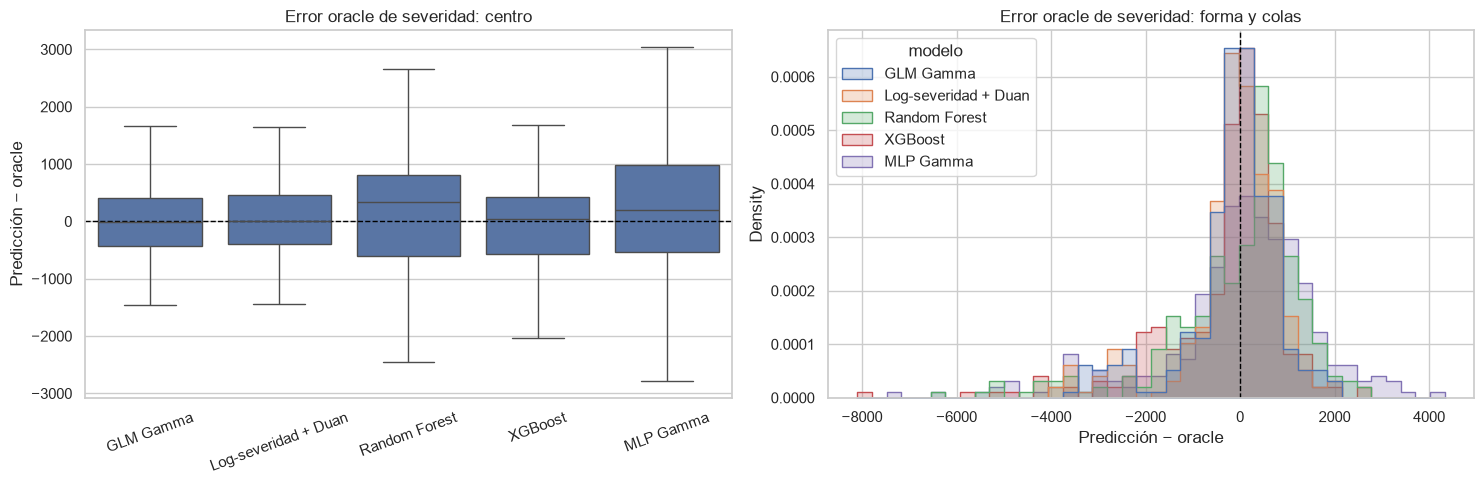

In [161]:
severity_oracle_errors = pd.concat([
    pd.DataFrame({
        "modelo": model,
        "error_oracle": severity_predictions[column] - severity_predictions["severidad_esperada_real"],
    })
    for model, column in SEVERITY_MODELS.items()
], ignore_index=True)

severity_error_summary = severity_oracle_errors.groupby("modelo")["error_oracle"].agg(
    media="mean", mediana="median", desviación="std", mínimo="min", máximo="max"
)
display(severity_error_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=severity_oracle_errors, x="modelo", y="error_oracle", showfliers=False, ax=axes[0])
axes[0].axhline(0, color="black", ls="--", lw=1)
axes[0].set(title="Error oracle de severidad: centro", xlabel="", ylabel="Predicción − oracle")
axes[0].tick_params(axis="x", rotation=20)

sns.histplot(data=severity_oracle_errors, x="error_oracle", hue="modelo", element="step", stat="density", common_norm=False, bins=40, ax=axes[1])
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set(title="Error oracle de severidad: forma y colas", xlabel="Predicción − oracle")
plt.tight_layout(); plt.show()

**Interpretación.** Los errores oracle de GLM Gamma y log+Duan están más concentrados alrededor de cero. Los modelos flexibles presentan mayor dispersión y colas, aunque todos preservan señal. Esta figura explica la separación de Oracle RMSE que apenas era visible en el error contra severidades realizadas.

## 24. Síntesis de severidad, sin extenderse a prima pura

- **Predicción del claim realizado:** las diferencias de MAE, RMSE y Gamma deviance son pequeñas porque el ruido individual domina el error total.
- **Recuperación de la media:** los errores oracle separan mejor las especificaciones. Los dos modelos estadísticos reproducen con mayor precisión la función condicional de este DGP; XGBoost conserva una recuperación razonable, seguido por Random Forest y MLP Gamma.
- **Ordenamiento:** las correlaciones son altas en todos los modelos. Log+Duan obtiene el Spearman más alto, pero eso no implica el menor error de nivel oracle.
- **Calibración:** una media agregada correcta puede coexistir con subestimación del extremo superior. Los deciles y las distribuciones de error son necesarios para detectar esa compensación.
- **Ruido frente a error controlable:** aproximadamente 95%–99% del MSE observado corresponde al ruido del claim. El error de estimar la media es una fracción menor del total, pero es precisamente la parte sobre la que puede actuar el modelo.

La fase termina aquí. No se combinan todavía frecuencia y severidad ni se analiza prima pura.

# Fase 4 — Comparación de prima pura

La prima pura puede estimarse mediante dos estrategias distintas:

1. **Frecuencia × Severidad (F×S):** se estiman por separado \(\lambda(X)\) y \(\mu_S(X)\), y se multiplica \(\hat\lambda(X)\hat\mu_S(X)\).
2. **Modelado directo:** se estima \(E[C\mid X]\), donde `C = costo_siniestros`, con un único modelo para costo agregado.

Se comparan ocho resultados finales congelados:

| Paradigma | F×S | Directo |
|---|---|---|
| Estadístico | Poisson × Gamma | GLM Tweedie |
| Machine Learning | RF F×S; XGBoost F×S | RF directo; XGBoost directo |
| Deep Learning | MLP F×S | MLP Tweedie |

Todas las Tweedie deviances se calculan con **power = 1.25**. Primero se estudia cada predicción frente al costo realizado y frente a `prima_pura_real`; después se comparan F×S y directo dentro de cada paradigma.

In [162]:
PURE_PREMIUM_MODELS = {
    "Poisson × Gamma": {"columna": "pp_poisson_gamma", "estrategia": "Frecuencia × Severidad", "paradigma": "Estadístico"},
    "GLM Tweedie": {"columna": "pp_tweedie", "estrategia": "Directo", "paradigma": "Estadístico"},
    "Random Forest F×S": {"columna": "pp_rf_fs", "estrategia": "Frecuencia × Severidad", "paradigma": "Machine Learning"},
    "XGBoost F×S": {"columna": "pp_xgb_fs", "estrategia": "Frecuencia × Severidad", "paradigma": "Machine Learning"},
    "Random Forest directo": {"columna": "pp_rf_direct", "estrategia": "Directo", "paradigma": "Machine Learning"},
    "XGBoost directo": {"columna": "pp_xgb_direct", "estrategia": "Directo", "paradigma": "Machine Learning"},
    "MLP F×S": {"columna": "pp_mlp_fs", "estrategia": "Frecuencia × Severidad", "paradigma": "Deep Learning"},
    "MLP Tweedie": {"columna": "pp_mlp_tweedie", "estrategia": "Directo", "paradigma": "Deep Learning"},
}

required_pp_columns = {
    "policy_id", "costo_siniestros", "prima_pura_real",
    *[spec["columna"] for spec in PURE_PREMIUM_MODELS.values()],
}
missing_pp_columns = required_pp_columns - set(policy_predictions.columns)
assert not missing_pp_columns, f"Faltan columnas de prima pura: {sorted(missing_pp_columns)}"
assert (policy_predictions[[spec["columna"] for spec in PURE_PREMIUM_MODELS.values()]] > 0).all().all()
assert TWEEDIE_POWER == 1.25

print(f"Base común de prima pura: {len(policy_predictions):,} pólizas.")
print(f"Proporción de costos observados iguales a cero: {(policy_predictions['costo_siniestros'] == 0).mean():.1%}")

Base común de prima pura: 2,000 pólizas.
Proporción de costos observados iguales a cero: 85.4%


## 25. Métricas observadas y recuperación de la prima pura verdadera

Las métricas contra `costo_siniestros` evalúan una realización con aproximadamente 85% de ceros y una cola positiva pronunciada. Las métricas contra `prima_pura_real` evalúan la recuperación de \(E[C\mid X]\), que es una función continua y mucho más estable.

- **MAE** da el mismo peso lineal a cada desviación. Con una masa grande en cero, puede favorecer predicciones bajas; no es una función de pérdida propia para la media condicional.
- **RMSE** enfatiza errores monetarios grandes.
- **Tweedie deviance con \(p=1.25\)** es coherente con un costo agregado compuesto Poisson–Gamma y permite comparar las dos estrategias bajo una definición común.
- **Pearson** evalúa asociación lineal con la prima pura real.
- **Spearman** evalúa ordenamiento de riesgo, aunque la escala esté comprimida o desplazada.

In [163]:
pp_rows = []
y_cost = policy_predictions["costo_siniestros"].to_numpy(float)
mu_premium = policy_predictions["prima_pura_real"].to_numpy(float)

for model, spec in PURE_PREMIUM_MODELS.items():
    pred = policy_predictions[spec["columna"]].to_numpy(float)
    pp_rows.append({
        "paradigma": spec["paradigma"],
        "estrategia": spec["estrategia"],
        "modelo": model,
        "MAE_test": mean_absolute_error(y_cost, pred),
        "RMSE_test": np.sqrt(np.mean((y_cost - pred) ** 2)),
        "Tweedie_deviance_test": mean_tweedie_deviance(y_cost, pred, power=TWEEDIE_POWER),
        "Oracle_MAE": mean_absolute_error(mu_premium, pred),
        "Oracle_RMSE": np.sqrt(np.mean((mu_premium - pred) ** 2)),
        "Pearson_prima": np.corrcoef(mu_premium, pred)[0, 1],
        "Spearman_prima": spearmanr(mu_premium, pred).statistic,
    })

pure_premium_diagnostics = pd.DataFrame(pp_rows)

published_pp = pure_premium_metrics[[
    "modelo", "estrategia", "MAE_test", "RMSE_test", "Tweedie_deviance_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
]].copy()
pp_metric_audit = pure_premium_diagnostics.merge(
    published_pp, on=["modelo", "estrategia"], validate="one_to_one",
    suffixes=("_recalculado", "_publicado"),
)
for metric in ["MAE_test", "RMSE_test", "Tweedie_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    assert np.allclose(
        pp_metric_audit[f"{metric}_recalculado"], pp_metric_audit[f"{metric}_publicado"],
        rtol=1e-6, atol=1e-5,
    ), f"La métrica {metric} no coincide con el CSV."
assert np.allclose(
    pp_metric_audit["Pearson_prima"], pp_metric_audit["Oracle_correlation"],
    rtol=1e-6, atol=1e-8,
)

display(pure_premium_diagnostics.round(6))

,paradigma,estrategia,modelo,MAE_test,RMSE_test,Tweedie_deviance_test,Oracle_MAE,Oracle_RMSE,Pearson_prima,Spearman_prima
0,Estadístico,Frecuencia × Severidad,Poisson × Gamma,3184.319010,6387.810262,1162.832922,198.187975,287.664493,0.984688,0.985468
1,Estadístico,Directo,GLM Tweedie,3186.569913,6382.115855,1161.789798,190.702458,280.870926,0.985267,0.987026
2,Machine Learning,Frecuencia × Severidad,Random Forest F×S,3207.991478,6446.506813,1179.889515,423.432449,701.599529,0.917740,0.922846
3,Machine Learning,Frecuencia × Severidad,XGBoost F×S,3175.127888,6426.867102,1171.389162,338.743817,598.304168,0.948913,0.955402
4,Machine Learning,Directo,Random Forest directo,3226.327926,6438.165607,1184.541443,505.275561,743.192651,0.884798,0.857714
5,Machine Learning,Directo,XGBoost directo,3185.237448,6391.374677,1159.819072,308.072570,522.930465,0.951525,0.962103
6,Deep Learning,Frecuencia × Severidad,MLP F×S,3348.958088,6448.411840,1175.861683,438.083456,828.179900,0.872776,0.954756
7,Deep Learning,Directo,MLP Tweedie,3170.163282,6440.011958,1175.522604,356.607476,636.741513,0.925930,0.952389


### Por qué el costo observado separa poco a los modelos

Los MAE observados se concentran aproximadamente entre 3,170 y 3,349; los RMSE, entre 6,382 y 6,449; y las Tweedie deviances, entre 1,160 y 1,185. En contraste, los Oracle RMSE abarcan aproximadamente de 281 a 828.

La diferencia se debe a que el costo realizado combina ausencia aleatoria de siniestros, número de siniestros y severidades individuales. Dos pólizas con la misma prima pura pueden producir cero y un costo muy alto. Ese ruido domina las métricas individuales y hace que predicciones estructuralmente distintas parezcan cercanas frente al costo observado.

El MAE observado merece especial cautela: `prima_pura_real`, aunque es la media condicional correcta, tiene MAE observado mayor que varios modelos. No significa que esos modelos conozcan mejor la media; con 85% de ceros, el MAE favorece valores cercanos a la mediana condicional, frecuentemente cero. Tweedie deviance y las métricas oracle son más adecuadas para evaluar la media de costo.

## 26. Ruido de realización frente a error de estimación

Se aplica la misma identidad cuadrática utilizada en severidad:

\[
C-\hat\pi=(C-\pi)+(\pi-\hat\pi),
\]

donde \(\pi\) es `prima_pura_real`. Así, el MSE observado se divide en ruido del costo, error de estimación de la prima pura e interacción muestral.

In [164]:
oracle_premium_benchmark = pd.DataFrame([{
    "predictor": "prima_pura_real",
    "MAE_observado": mean_absolute_error(y_cost, mu_premium),
    "RMSE_observado": np.sqrt(np.mean((y_cost - mu_premium) ** 2)),
    "Tweedie_deviance": mean_tweedie_deviance(y_cost, mu_premium, power=TWEEDIE_POWER),
    "media_costo_observado": y_cost.mean(),
    "media_prima_pura_real": mu_premium.mean(),
    "proporción_ceros": np.mean(y_cost == 0),
}])
display(oracle_premium_benchmark.round(6))

cost_noise = y_cost - mu_premium
cost_noise_mse = np.mean(cost_noise ** 2)
pp_decomposition_rows = []
for model, spec in PURE_PREMIUM_MODELS.items():
    pred = policy_predictions[spec["columna"]].to_numpy(float)
    estimation_error = mu_premium - pred
    observed_mse = np.mean((y_cost - pred) ** 2)
    estimation_mse = np.mean(estimation_error ** 2)
    interaction = 2 * np.mean(cost_noise * estimation_error)
    pp_decomposition_rows.append({
        "modelo": model,
        "estrategia": spec["estrategia"],
        "MSE_observado": observed_mse,
        "MSE_ruido_costo": cost_noise_mse,
        "MSE_estimación_prima": estimation_mse,
        "interacción_muestral": interaction,
        "% MSE ruido": 100 * cost_noise_mse / observed_mse,
        "% MSE estimación": 100 * estimation_mse / observed_mse,
        "% MSE interacción": 100 * interaction / observed_mse,
        "error_identidad": observed_mse - cost_noise_mse - estimation_mse - interaction,
    })

premium_mse_decomposition = pd.DataFrame(pp_decomposition_rows)
display(premium_mse_decomposition.round(4))
assert np.allclose(premium_mse_decomposition["error_identidad"], 0, atol=1e-5)

,predictor,MAE_observado,RMSE_observado,Tweedie_deviance,media_costo_observado,media_prima_pura_real,proporción_ceros
0,prima_pura_real,3239.864195,6369.049262,1153.778706,2008.681614,1982.528922,0.854


,modelo,estrategia,MSE_observado,MSE_ruido_costo,MSE_estimación_prima,interacción_muestral,% MSE ruido,% MSE estimación,% MSE interacción,error_identidad
0,Poisson × Gamma,Frecuencia × Severidad,4.080412e+07,4.056479e+07,82750.8605,156580.5844,99.4135,0.2028,0.3837,-0.0
1,GLM Tweedie,Directo,4.073140e+07,4.056479e+07,78888.4768,87725.8076,99.5909,0.1937,0.2154,0.0
2,Random Forest F×S,Frecuencia × Severidad,4.155745e+07,4.056479e+07,492241.8987,500419.6900,97.6114,1.1845,1.2042,-0.0
3,XGBoost F×S,Frecuencia × Severidad,4.130462e+07,4.056479e+07,357967.8773,381864.3689,98.2088,0.8667,0.9245,0.0
4,Random Forest directo,Directo,4.144998e+07,4.056479e+07,552335.3165,332852.5677,97.8644,1.3325,0.8030,-0.0
5,XGBoost directo,Directo,4.084967e+07,4.056479e+07,273456.2710,11425.4968,99.3026,0.6694,0.0280,-0.0
6,MLP F×S,Frecuencia × Severidad,4.158202e+07,4.056479e+07,685881.9461,331344.8098,97.5537,1.6495,0.7968,-0.0
7,MLP Tweedie,Directo,4.147375e+07,4.056479e+07,405439.7549,503525.7602,97.8083,0.9776,1.2141,0.0


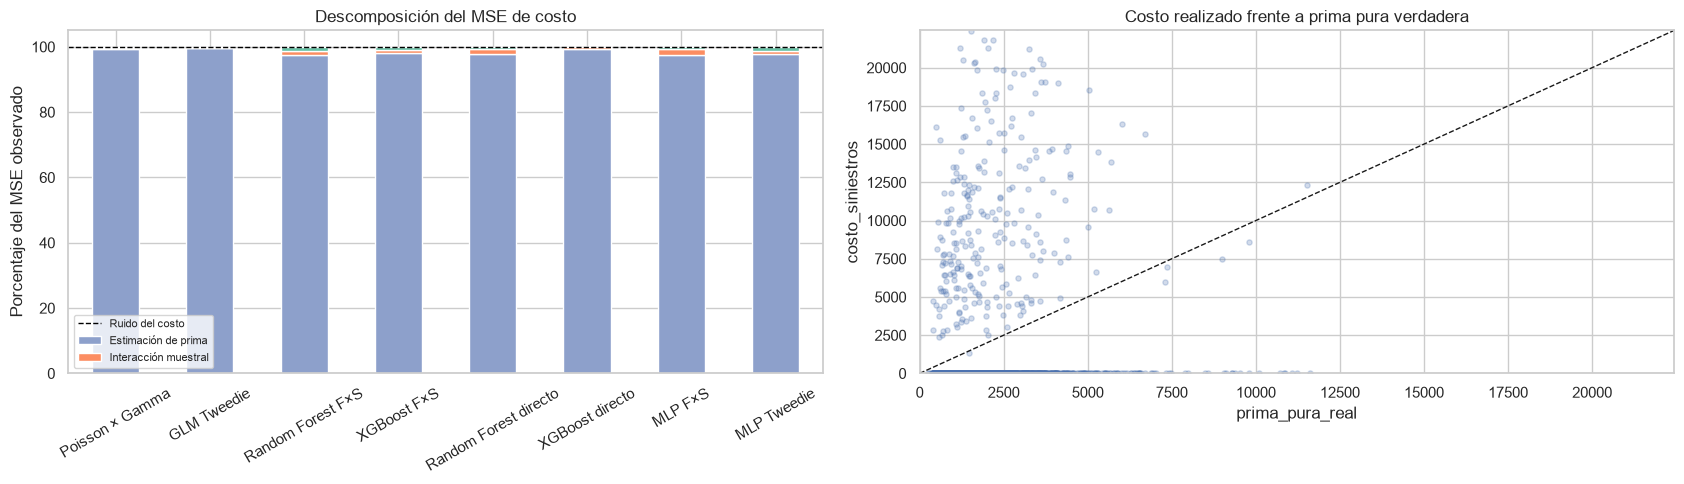

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
components = premium_mse_decomposition.set_index("modelo")[["% MSE ruido", "% MSE estimación", "% MSE interacción"]]
components.plot(kind="bar", stacked=True, ax=axes[0], color=["#8da0cb", "#fc8d62", "#66c2a5"])
axes[0].axhline(100, color="black", ls="--", lw=1)
axes[0].set(title="Descomposición del MSE de costo", xlabel="", ylabel="Porcentaje del MSE observado")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(["Ruido del costo", "Estimación de prima", "Interacción muestral"], fontsize=8)

axes[1].scatter(policy_predictions["prima_pura_real"], policy_predictions["costo_siniestros"], s=14, alpha=.25)
limit = np.percentile(np.r_[policy_predictions["prima_pura_real"], policy_predictions["costo_siniestros"]], 99)
axes[1].plot([0, limit], [0, limit], "k--", lw=1)
axes[1].set_xlim(0, limit); axes[1].set_ylim(0, limit)
axes[1].set(title="Costo realizado frente a prima pura verdadera", xlabel="prima_pura_real", ylabel="costo_siniestros")

plt.tight_layout(); plt.show()

`prima_pura_real` tiene RMSE observado cercano a 6,369 y Tweedie deviance cercana a 1,154. Para los modelos, aproximadamente 98%–100% del MSE observado procede del ruido del costo. El componente de estimación de prima pura representa aproximadamente 0.2%–1.6%, según el modelo, y la interacción completa la identidad en esta muestra.

Por ello, una diferencia pequeña de RMSE observado puede corresponder a una reducción relevante del componente controlable. A la inversa, mejorar accidentalmente MAE sobre esta realización no demuestra una mejor estimación de la prima pura verdadera.

## 27. Calibración agregada

Se compara la predicción total con el costo total realizado y con la prima pura total oracle. La primera referencia incorpora la experiencia aleatoria de este test; la segunda representa el nivel esperado verdadero de la cartera.

In [166]:
pp_aggregate_rows = []
observed_cost_mean = policy_predictions["costo_siniestros"].mean()
oracle_premium_mean = policy_predictions["prima_pura_real"].mean()

for model, spec in PURE_PREMIUM_MODELS.items():
    values = policy_predictions[spec["columna"]]
    pp_aggregate_rows.append({
        "paradigma": spec["paradigma"],
        "estrategia": spec["estrategia"],
        "modelo": model,
        "costo_medio_observado": observed_cost_mean,
        "prima_pura_media_real": oracle_premium_mean,
        "predicción_media": values.mean(),
        "sesgo_vs_costo": values.mean() - observed_cost_mean,
        "sesgo_vs_costo_%": 100 * (values.mean() / observed_cost_mean - 1),
        "sesgo_vs_prima_real": values.mean() - oracle_premium_mean,
        "sesgo_vs_prima_real_%": 100 * (values.mean() / oracle_premium_mean - 1),
    })

pure_premium_aggregate_calibration = pd.DataFrame(pp_aggregate_rows)
display(pure_premium_aggregate_calibration.round(4))

,paradigma,estrategia,modelo,costo_medio_observado,prima_pura_media_real,predicción_media,sesgo_vs_costo,sesgo_vs_costo_%,sesgo_vs_prima_real,sesgo_vs_prima_real_%
0,Estadístico,Frecuencia × Severidad,Poisson × Gamma,2008.6816,1982.5289,1900.5431,-108.1385,-5.3836,-81.9859,-4.1354
1,Estadístico,Directo,GLM Tweedie,2008.6816,1982.5289,1907.0464,-101.6352,-5.0598,-75.4825,-3.8074
2,Machine Learning,Frecuencia × Severidad,Random Forest F×S,2008.6816,1982.5289,1867.9499,-140.7317,-7.0062,-114.5790,-5.7794
3,Machine Learning,Frecuencia × Severidad,XGBoost F×S,2008.6816,1982.5289,1835.7544,-172.9272,-8.6090,-146.7745,-7.4034
4,Machine Learning,Directo,Random Forest directo,2008.6816,1982.5289,1919.7569,-88.9247,-4.4270,-62.7720,-3.1663
5,Machine Learning,Directo,XGBoost directo,2008.6816,1982.5289,1869.4188,-139.2628,-6.9330,-113.1101,-5.7053
6,Deep Learning,Frecuencia × Severidad,MLP F×S,2008.6816,1982.5289,2056.9452,48.2636,2.4027,74.4162,3.7536
7,Deep Learning,Directo,MLP Tweedie,2008.6816,1982.5289,1842.5774,-166.1042,-8.2693,-139.9515,-7.0592


El costo medio observado es aproximadamente 2,009 y la prima pura media real, 1,983; la experiencia de test quedó alrededor de 1.3% por encima de su esperanza. Casi todos los modelos subestiman ambas referencias. MLP F×S es la excepción: sobreestima la prima pura real cerca de 3.8% y el costo observado cerca de 2.4%.

Las predicciones agregadas no describen por sí solas la segmentación. Un modelo puede acertar el total compensando sobreestimación de riesgos bajos con subestimación de riesgos altos.

## 28. Calibración por cuantiles de `prima_pura_real`

Los deciles se forman con el oracle. Esta agrupación es posible únicamente porque el experimento es sintético; permite observar directamente dónde se comprime o desplaza la estructura de riesgo. El costo medio realizado se incluye para mostrar cuánto ruido permanece incluso con 200 pólizas por decil.

In [167]:
pp_quantiles = policy_predictions[[
    "policy_id", "costo_siniestros", "prima_pura_real",
    *[spec["columna"] for spec in PURE_PREMIUM_MODELS.values()],
]].copy()
pp_quantiles["decil_riesgo"] = pd.qcut(
    pp_quantiles["prima_pura_real"], q=10, labels=range(1, 11), duplicates="drop"
)

pp_quantile_means = pp_quantiles.groupby("decil_riesgo", observed=True).agg(
    n=("policy_id", "size"),
    costo_observado=("costo_siniestros", "mean"),
    prima_real=("prima_pura_real", "mean"),
    Poisson_Gamma=("pp_poisson_gamma", "mean"),
    GLM_Tweedie=("pp_tweedie", "mean"),
    RF_FS=("pp_rf_fs", "mean"),
    XGB_FS=("pp_xgb_fs", "mean"),
    RF_directo=("pp_rf_direct", "mean"),
    XGB_directo=("pp_xgb_direct", "mean"),
    MLP_FS=("pp_mlp_fs", "mean"),
    MLP_Tweedie=("pp_mlp_tweedie", "mean"),
).reset_index()

PP_PLOT_COLUMNS = {
    "Poisson × Gamma": "Poisson_Gamma", "GLM Tweedie": "GLM_Tweedie",
    "RF F×S": "RF_FS", "XGB F×S": "XGB_FS",
    "RF directo": "RF_directo", "XGB directo": "XGB_directo",
    "MLP F×S": "MLP_FS", "MLP Tweedie": "MLP_Tweedie",
}
for label, column in PP_PLOT_COLUMNS.items():
    pp_quantile_means[f"ratio_{column}"] = pp_quantile_means[column] / pp_quantile_means["prima_real"]

display(pp_quantile_means.round(4))

,decil_riesgo,n,costo_observado,prima_real,Poisson_Gamma,GLM_Tweedie,RF_FS,XGB_FS,RF_directo,XGB_directo,MLP_FS,MLP_Tweedie,ratio_Poisson_Gamma,ratio_GLM_Tweedie,ratio_RF_FS,ratio_XGB_FS,ratio_RF_directo,ratio_XGB_directo,ratio_MLP_FS,ratio_MLP_Tweedie
0,1,200,704.2502,549.3387,520.7417,512.2429,779.2554,684.6757,642.5903,677.3452,777.0540,539.7588,0.9479,0.9325,1.4185,1.2464,1.1698,1.2330,1.4145,0.9826
1,2,201,798.9073,787.7369,741.5804,730.3301,986.1993,900.6407,846.9572,859.2715,1032.2025,744.1497,0.9414,0.9271,1.2519,1.1433,1.0752,1.0908,1.3103,0.9447
2,3,199,911.8688,992.0154,948.6073,938.4456,1157.6062,1080.3993,1099.0826,1025.9251,1271.4609,944.1506,0.9562,0.9460,1.1669,1.0891,1.1079,1.0342,1.2817,0.9517
3,4,200,1072.9440,1184.8936,1130.9150,1123.0718,1260.8645,1197.9372,1156.2278,1160.7652,1458.5814,1127.8325,0.9544,0.9478,1.0641,1.0110,0.9758,0.9796,1.2310,0.9518
4,5,200,1434.8420,1385.6967,1351.3250,1339.1791,1477.0839,1412.3994,1382.1947,1390.7875,1717.6505,1341.9439,0.9752,0.9664,1.0660,1.0193,0.9975,1.0037,1.2396,0.9684
5,6,200,1460.7151,1638.0556,1581.1670,1577.9065,1657.8065,1585.7545,1729.5341,1595.6470,1949.5731,1611.4656,0.9653,0.9633,1.0121,0.9681,1.0558,0.9741,1.1902,0.9838
6,7,200,1526.7789,2002.8546,1936.9188,1943.1767,1930.7043,1899.0893,1969.8852,1929.1592,2258.0962,2010.4846,0.9671,0.9702,0.9640,0.9482,0.9835,0.9632,1.1274,1.0038
7,8,200,2450.9012,2467.7432,2376.1525,2393.4086,2322.2877,2270.4210,2448.2275,2320.9374,2701.6887,2440.7365,0.9629,0.9699,0.9411,0.9200,0.9921,0.9405,1.0948,0.9891
8,9,200,3052.1525,3198.6282,3048.2621,3077.4912,2863.9343,2907.0974,3061.9574,2973.7720,3245.6324,3092.6453,0.9530,0.9621,0.8954,0.9089,0.9573,0.9297,1.0147,0.9669
9,10,200,6674.0210,5619.3478,5370.7960,5436.2523,4244.6141,4420.0286,4862.1729,4761.4113,4158.7083,4573.6065,0.9558,0.9674,0.7554,0.7866,0.8653,0.8473,0.7401,0.8139


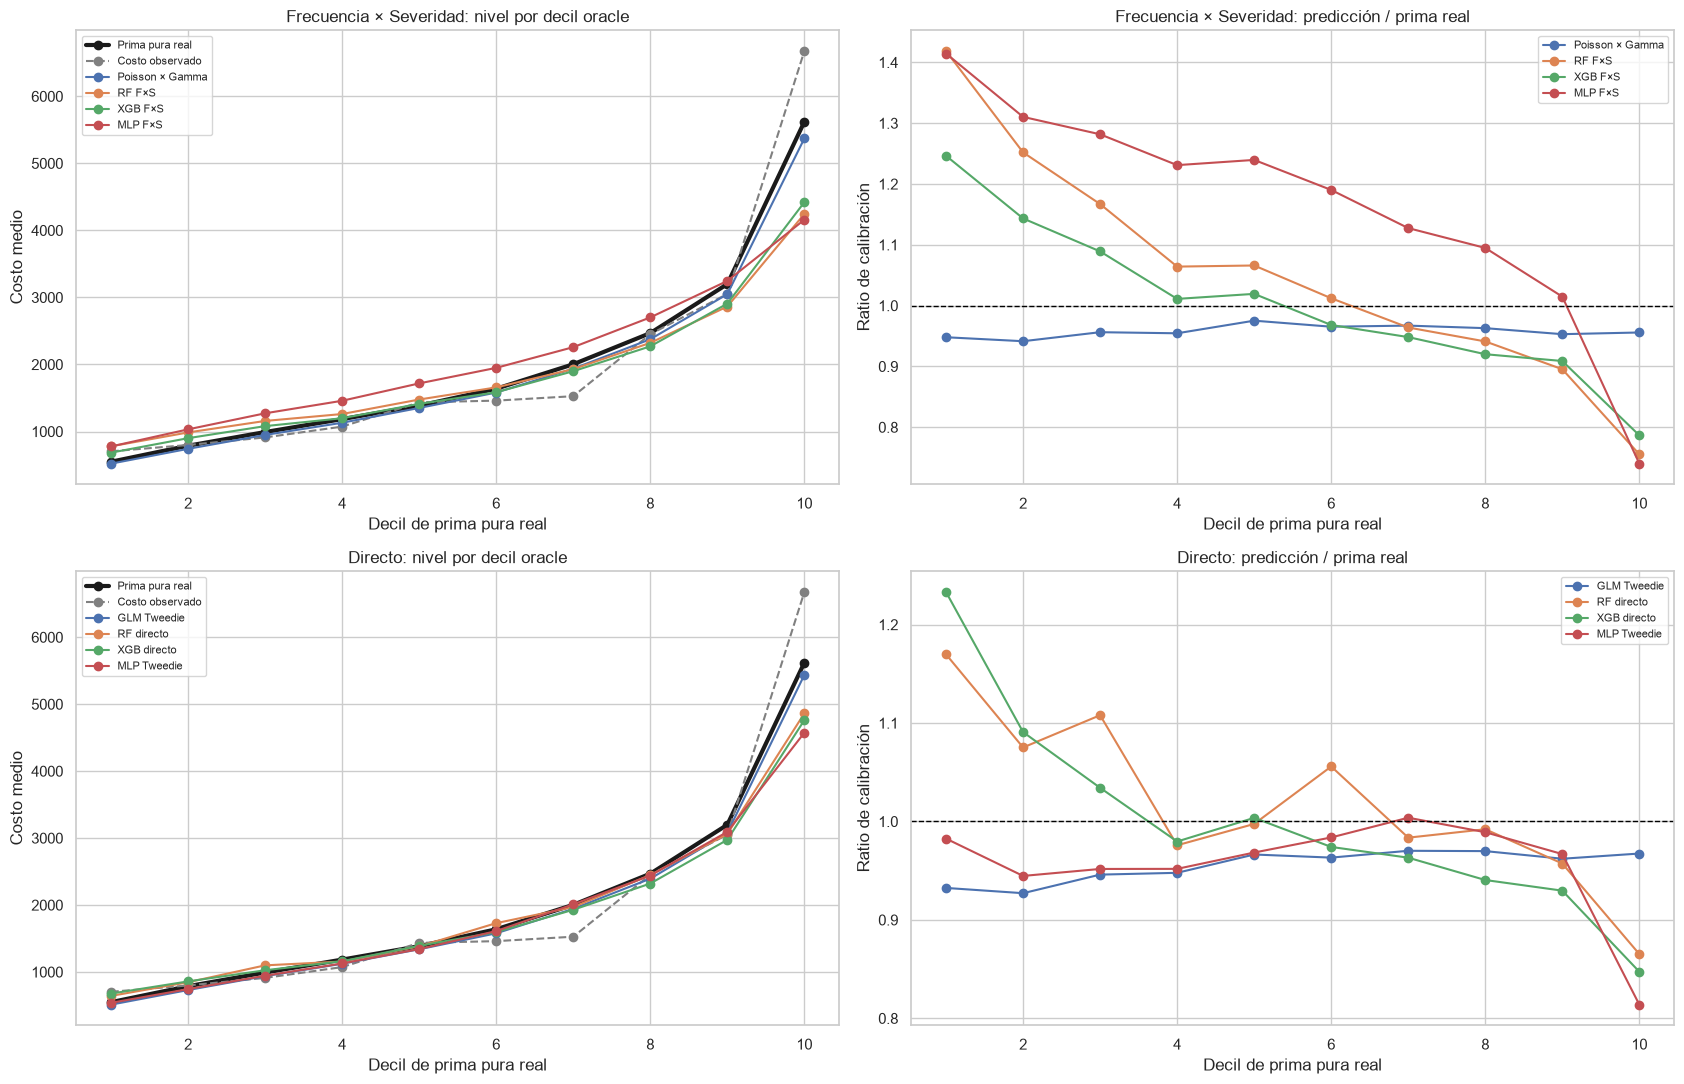

In [168]:
strategy_plot_columns = {
    "Frecuencia × Severidad": ["Poisson × Gamma", "RF F×S", "XGB F×S", "MLP F×S"],
    "Directo": ["GLM Tweedie", "RF directo", "XGB directo", "MLP Tweedie"],
}

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
for row, (strategy, labels) in enumerate(strategy_plot_columns.items()):
    axes[row, 0].plot(pp_quantile_means["decil_riesgo"], pp_quantile_means["prima_real"], "k-o", lw=3, label="Prima pura real")
    axes[row, 0].plot(pp_quantile_means["decil_riesgo"], pp_quantile_means["costo_observado"], color="gray", ls="--", marker="o", label="Costo observado")
    for label in labels:
        column = PP_PLOT_COLUMNS[label]
        axes[row, 0].plot(pp_quantile_means["decil_riesgo"], pp_quantile_means[column], marker="o", label=label)
        axes[row, 1].plot(pp_quantile_means["decil_riesgo"], pp_quantile_means[f"ratio_{column}"], marker="o", label=label)
    axes[row, 0].set(title=f"{strategy}: nivel por decil oracle", xlabel="Decil de prima pura real", ylabel="Costo medio")
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].axhline(1, color="black", ls="--", lw=1)
    axes[row, 1].set(title=f"{strategy}: predicción / prima real", xlabel="Decil de prima pura real", ylabel="Ratio de calibración")
    axes[row, 1].legend(fontsize=8)

plt.tight_layout(); plt.show()

Los dos modelos estadísticos mantienen ratios relativamente próximos a uno a lo largo de los deciles. Poisson×Gamma pasa aproximadamente de −5% en el primer decil a −4% en el décimo; GLM Tweedie, de −7% a −3%.

Los modelos flexibles muestran mayor compresión. En el primer decil, RF F×S y MLP F×S sobreestiman alrededor de 42%, mientras en el décimo subestiman cerca de 24%–26%. XGBoost F×S presenta el mismo patrón con menor intensidad. Entre los directos, MLP Tweedie calibra bien el primer decil pero subestima aproximadamente 19% el décimo; RF y XGBoost directos también elevan el bajo riesgo y reducen el alto.

El costo observado por decil puede estar por encima o por debajo de la prima pura real debido a la realización aleatoria. No debe utilizarse esa oscilación para retocar modelos después de observar test.

## 29. Predicción frente a `prima_pura_real`

La diagonal representa recuperación perfecta de la prima pura. Una nube creciente pero comprimida puede conservar Spearman alto y, al mismo tiempo, tener peor Pearson, error oracle y calibración en los extremos.

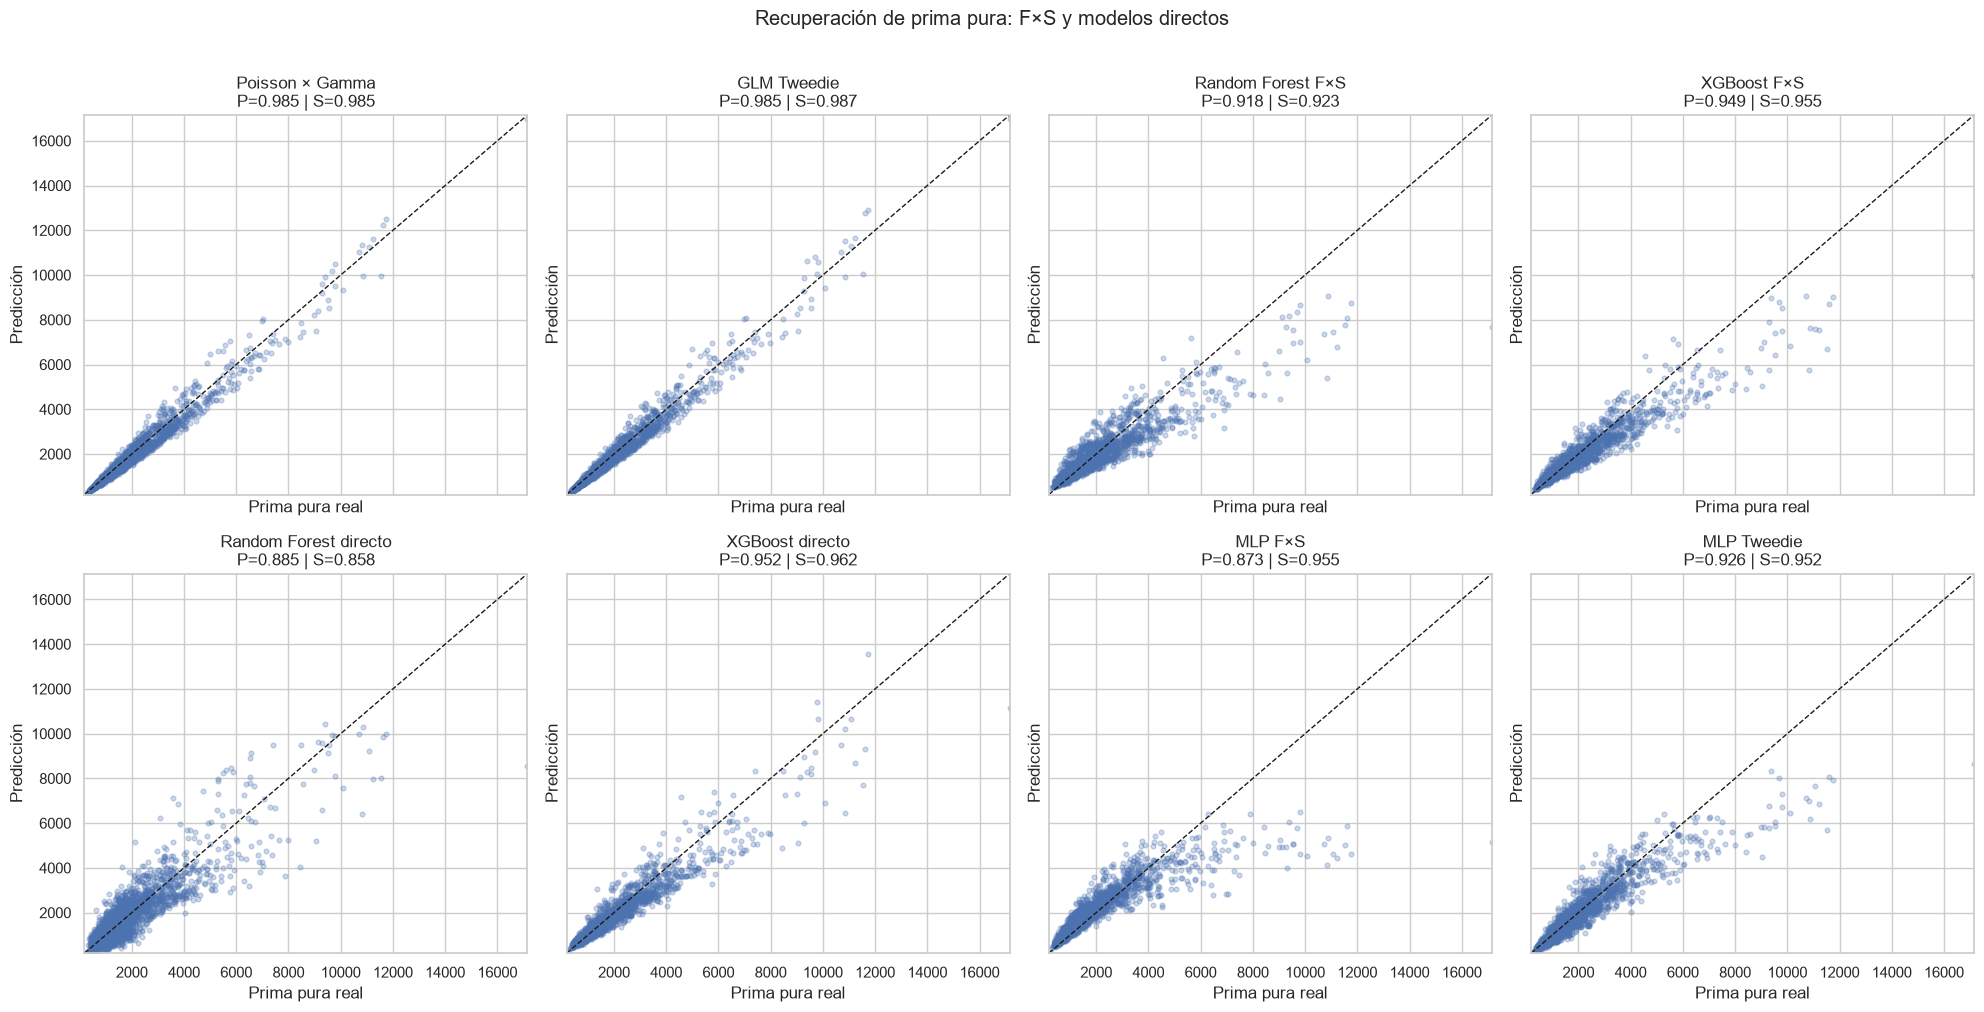

In [169]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
lower = min(policy_predictions["prima_pura_real"].min(), policy_predictions[[spec["columna"] for spec in PURE_PREMIUM_MODELS.values()]].min().min())
upper = max(policy_predictions["prima_pura_real"].max(), policy_predictions[[spec["columna"] for spec in PURE_PREMIUM_MODELS.values()]].max().max())

for ax, (model, spec) in zip(axes.ravel(), PURE_PREMIUM_MODELS.items()):
    ax.scatter(policy_predictions["prima_pura_real"], policy_predictions[spec["columna"]], s=12, alpha=.28)
    ax.plot([lower, upper], [lower, upper], "k--", lw=1)
    row = pure_premium_diagnostics.loc[pure_premium_diagnostics.modelo.eq(model)].iloc[0]
    ax.set(
        title=f"{model}\nP={row['Pearson_prima']:.3f} | S={row['Spearman_prima']:.3f}",
        xlabel="Prima pura real", ylabel="Predicción",
    )
    ax.set_xlim(lower, upper); ax.set_ylim(lower, upper)

fig.suptitle("Recuperación de prima pura: F×S y modelos directos", y=1.01)
plt.tight_layout(); plt.show()

MLP F×S es un ejemplo claro de por qué Pearson y Spearman deben separarse: Spearman es aproximadamente 0.955, pero Pearson cae a 0.873. El modelo conserva buena parte del orden relativo mientras comprime fuertemente la escala. RF directo muestra el Spearman más bajo del conjunto (`≈0.858`), señal de que su problema no es sólo calibración sino también ordenamiento.

## 30. Distribución de errores oracle

La distribución de `predicción − prima_pura_real` muestra el componente modelable sin el ruido del costo realizado. Se separan las estrategias para conservar legibilidad.

media  mediana  desviación     mínimo    máximo
estrategia             modelo                                                                  
Directo                GLM Tweedie            -75.483  -72.724     270.606  -1559.401  1695.553
                       MLP Tweedie           -139.952  -82.235     621.326  -8518.770  1999.922
                       Random Forest directo  -62.772  -53.047     740.722  -8588.686  3526.465
                       XGBoost directo       -113.110  -49.008     510.679  -6016.071  2606.950
Frecuencia × Severidad MLP F×S                 74.416  189.041     825.036 -11993.839  1975.879
                       Poisson × Gamma        -81.986  -65.789     275.803  -1551.246  1484.955
                       Random Forest F×S     -114.579    6.765     692.353  -9491.946  1760.379
                       XGBoost F×S           -146.774  -28.128     580.167  -7211.881  1833.012

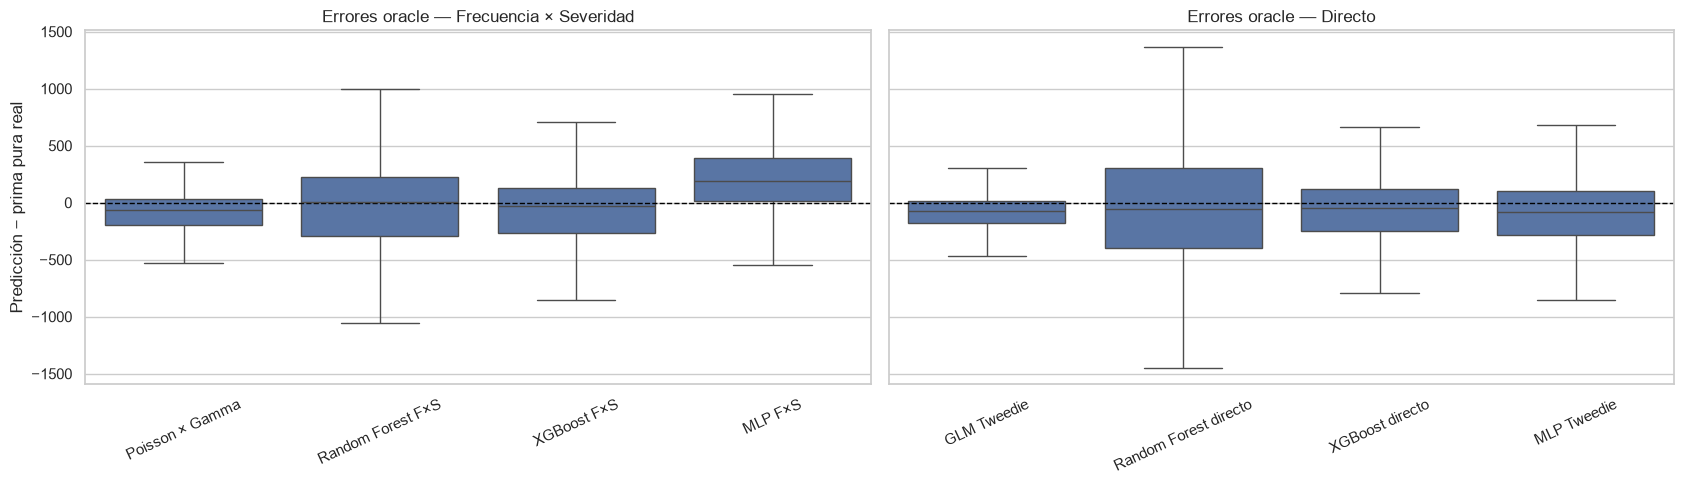

In [170]:
pp_oracle_errors = pd.concat([
    pd.DataFrame({
        "modelo": model,
        "estrategia": spec["estrategia"],
        "error_oracle": policy_predictions[spec["columna"]] - policy_predictions["prima_pura_real"],
    })
    for model, spec in PURE_PREMIUM_MODELS.items()
], ignore_index=True)

pp_error_summary = pp_oracle_errors.groupby(["estrategia", "modelo"])["error_oracle"].agg(
    media="mean", mediana="median", desviación="std", mínimo="min", máximo="max"
)
display(pp_error_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for ax, strategy in zip(axes, ["Frecuencia × Severidad", "Directo"]):
    subset = pp_oracle_errors.loc[pp_oracle_errors["estrategia"].eq(strategy)]
    sns.boxplot(data=subset, x="modelo", y="error_oracle", showfliers=False, ax=ax)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set(title=f"Errores oracle — {strategy}", xlabel="", ylabel="Predicción − prima pura real")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

**Interpretación.** Las distribuciones confirman que la diferencia entre estrategias depende del algoritmo. Los dos enfoques estadísticos producen errores estrechos y semejantes; XGBoost y MLP directos reducen la dispersión frente a sus productos F×S, mientras Random Forest muestra el patrón contrario.

## 31. Propagación conjunta del error en F×S

Los CSV guardan las predicciones de frecuencia y severidad a nivel póliza, por lo que puede verificarse la identidad:

\[
\hat\lambda\hat\mu_S-\lambda\mu_S
=\mu_S(\hat\lambda-\lambda)
+\lambda(\hat\mu_S-\mu_S)
+(\hat\lambda-\lambda)(\hat\mu_S-\mu_S).
\]

Los términos representan contribución de frecuencia, contribución de severidad e interacción. Se muestran magnitudes absolutas medias: no deben sumarse como si fueran independientes, porque pueden tener signos opuestos y cancelarse.

In [171]:
FS_COMPONENTS = {
    "Poisson × Gamma": ("freq_glm_poisson", "sev_glm_gamma", "pp_poisson_gamma"),
    "Random Forest F×S": ("freq_rf", "sev_rf", "pp_rf_fs"),
    "XGBoost F×S": ("freq_xgb", "sev_xgb", "pp_xgb_fs"),
    "MLP F×S": ("freq_mlp", "sev_mlp", "pp_mlp_fs"),
}

product_identity_error = np.max(np.abs(
    policy_predictions["prima_pura_real"]
    - policy_predictions["lambda_real"] * policy_predictions["severidad_esperada_real"]
))
assert product_identity_error < 1e-8

propagation_rows = []
for model, (frequency_col, severity_col, premium_col) in FS_COMPONENTS.items():
    frequency_error = policy_predictions[frequency_col] - policy_predictions["lambda_real"]
    severity_error = policy_predictions[severity_col] - policy_predictions["severidad_esperada_real"]
    frequency_term = policy_predictions["severidad_esperada_real"] * frequency_error
    severity_term = policy_predictions["lambda_real"] * severity_error
    interaction_term = frequency_error * severity_error
    total_error = policy_predictions[premium_col] - policy_predictions["prima_pura_real"]
    identity_error = total_error - frequency_term - severity_term - interaction_term
    propagation_rows.append({
        "modelo": model,
        "MAE_oracle_prima": np.mean(np.abs(total_error)),
        "|aporte frecuencia| medio": np.mean(np.abs(frequency_term)),
        "|aporte severidad| medio": np.mean(np.abs(severity_term)),
        "|interacción| media": np.mean(np.abs(interaction_term)),
        "correlación_aportes_F_S": np.corrcoef(frequency_term, severity_term)[0, 1],
        "error_identidad_máximo": np.max(np.abs(identity_error)),
    })

premium_error_propagation = pd.DataFrame(propagation_rows)
display(premium_error_propagation.round(6))
assert premium_error_propagation["error_identidad_máximo"].max() < 0.002

,modelo,MAE_oracle_prima,|aporte frecuencia| medio,|aporte severidad| medio,|interacción| media,correlación_aportes_F_S,error_identidad_máximo
0,Poisson × Gamma,198.187975,167.539550,99.626906,7.498545,-0.064835,0.000000
1,Random Forest F×S,423.432449,340.054057,158.094460,28.672175,0.542894,0.000000
2,XGBoost F×S,338.743817,291.229874,127.962618,19.212323,0.445906,0.001132
3,MLP F×S,438.083456,348.462362,175.111846,32.214502,0.488098,0.000732


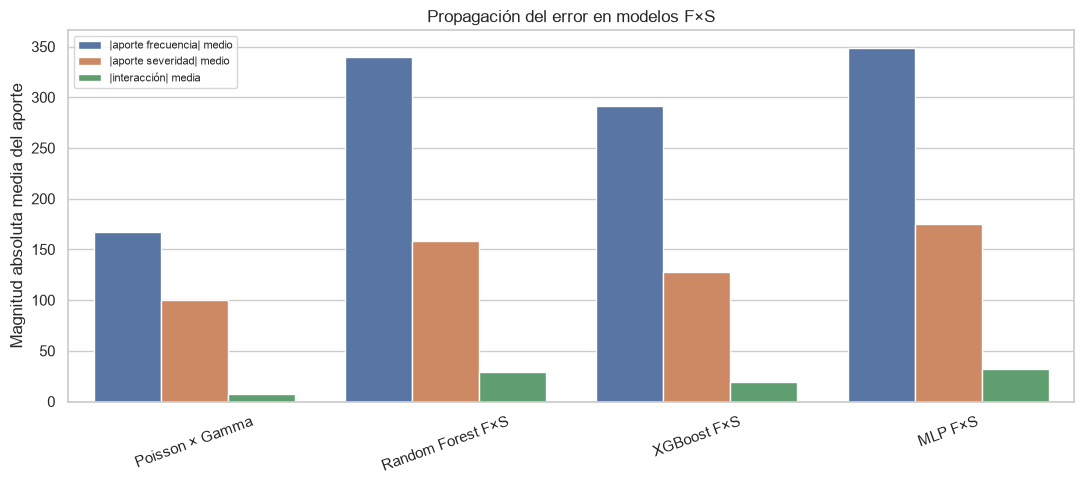

In [172]:
propagation_long = premium_error_propagation.melt(
    id_vars="modelo",
    value_vars=["|aporte frecuencia| medio", "|aporte severidad| medio", "|interacción| media"],
    var_name="componente", value_name="magnitud_absoluta_media",
)
plt.figure(figsize=(11, 5))
sns.barplot(data=propagation_long, x="modelo", y="magnitud_absoluta_media", hue="componente")
plt.title("Propagación del error en modelos F×S")
plt.xlabel(""); plt.ylabel("Magnitud absoluta media del aporte")
plt.xticks(rotation=20); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

En los cuatro productos F×S, la contribución de frecuencia es mayor que la de severidad. Para Poisson×Gamma las magnitudes absolutas medias son aproximadamente 168 por frecuencia, 100 por severidad y 7.5 por interacción. En RF, XGBoost y MLP F×S, la contribución de frecuencia aumenta a aproximadamente 291–348, la de severidad a 128–175 y la interacción a 19–32.

Los aportes no se suman al MAE final porque pueden cancelarse. Además, en los modelos flexibles los errores de frecuencia y severidad presentan correlación positiva, por lo que tienden con mayor frecuencia a empujar la prima en la misma dirección. Esta propagación explica por qué un buen componente aislado no garantiza automáticamente una buena prima pura compuesta.

## 32. F×S frente a directo dentro de cada paradigma

La comparación correcta no es sólo “estadístico contra ML contra DL”. También debe preguntar si, manteniendo aproximadamente la familia de modelado, conviene descomponer o modelar directamente. Para Machine Learning se muestran por separado los pares Random Forest y XGBoost.

En la tabla, un porcentaje negativo significa que el modelo directo tiene menor error que su alternativa F×S. Las diferencias de correlación se expresan como directo menos F×S.

In [173]:
WITHIN_PARADIGM_PAIRS = [
    ("Estadístico", "Poisson × Gamma", "GLM Tweedie"),
    ("Machine Learning — RF", "Random Forest F×S", "Random Forest directo"),
    ("Machine Learning — XGBoost", "XGBoost F×S", "XGBoost directo"),
    ("Deep Learning", "MLP F×S", "MLP Tweedie"),
]

within_rows = []
for comparison, fs_model, direct_model in WITHIN_PARADIGM_PAIRS:
    fs = pure_premium_diagnostics.loc[pure_premium_diagnostics.modelo.eq(fs_model)].iloc[0]
    direct = pure_premium_diagnostics.loc[pure_premium_diagnostics.modelo.eq(direct_model)].iloc[0]
    row = {"comparación": comparison, "modelo_F×S": fs_model, "modelo_directo": direct_model}
    for metric in ["MAE_test", "RMSE_test", "Tweedie_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
        row[f"Directo vs F×S — Δ {metric} (%)"] = 100 * (direct[metric] / fs[metric] - 1)
    row["Directo − F×S — Pearson"] = direct["Pearson_prima"] - fs["Pearson_prima"]
    row["Directo − F×S — Spearman"] = direct["Spearman_prima"] - fs["Spearman_prima"]
    within_rows.append(row)

within_strategy_comparison = pd.DataFrame(within_rows)
display(within_strategy_comparison.round(3))

,comparación,modelo_F×S,modelo_directo,Directo vs F×S — Δ MAE_test (%),Directo vs F×S — Δ RMSE_test (%),Directo vs F×S — Δ Tweedie_deviance_test (%),Directo vs F×S — Δ Oracle_MAE (%),Directo vs F×S — Δ Oracle_RMSE (%),Directo − F×S — Pearson,Directo − F×S — Spearman
0,Estadístico,Poisson × Gamma,GLM Tweedie,0.071,-0.089,-0.090,-3.777,-2.362,0.001,0.002
1,Machine Learning — RF,Random Forest F×S,Random Forest directo,0.572,-0.129,0.394,19.328,5.928,-0.033,-0.065
2,Machine Learning — XGBoost,XGBoost F×S,XGBoost directo,0.318,-0.552,-0.988,-9.054,-12.598,0.003,0.007
3,Deep Learning,MLP F×S,MLP Tweedie,-5.339,-0.130,-0.029,-18.598,-23.116,0.053,-0.002


### Lectura por paradigma

- **Estadístico:** GLM Tweedie directo y Poisson×Gamma son muy próximos frente al costo observado. El directo reduce Oracle MAE aproximadamente 3.8% y Oracle RMSE 2.4%, con correlaciones apenas superiores. Ambas estrategias recuperan bien el DGP.
- **Random Forest:** F×S recupera mejor la prima pura que RF directo. El directo aumenta Oracle MAE cerca de 19% y Oracle RMSE cerca de 6%, además de perder ordenamiento. Un RMSE observado ligeramente menor no compensa necesariamente ese deterioro estructural.
- **XGBoost:** el directo reduce Tweedie deviance cerca de 1%, Oracle MAE aproximadamente 9% y Oracle RMSE cerca de 13% frente a XGBoost F×S. Su MAE observado aumenta ligeramente, otra señal de que el MAE sobre una distribución con muchos ceros no equivale a recuperación de la media.
- **Deep Learning:** MLP Tweedie directo reduce MAE observado alrededor de 5%, Oracle MAE alrededor de 19% y Oracle RMSE cerca de 23% frente a MLP F×S. Pearson mejora claramente; Spearman permanece casi igual. La ventaja principal es calibración de escala, no un cambio fuerte de ranking.

No emerge una superioridad universal de F×S o directo: el resultado depende del algoritmo, de cómo se propagan los errores de componentes y del objetivo operativo. F×S ofrece trazabilidad actuarial; directo puede evitar multiplicar errores, pero también puede aprender peor el ordenamiento o la cola si la señal de costo es muy ruidosa.

## 33. Síntesis de prima pura, sin ranking global

- Las métricas frente al costo observado están dominadas por una realización con muchos ceros y alta cola. Por eso comprimen las diferencias entre modelos.
- Las métricas oracle revelan diferencias sustanciales en la recuperación de la prima pura verdadera.
- Pearson y Spearman separan calibración lineal de ordenamiento. Un Spearman alto puede coexistir con compresión fuerte del rango.
- La calibración agregada puede ocultar subsidios cruzados; los deciles muestran con claridad sobreestimación de bajo riesgo y subestimación de alto riesgo en varios modelos flexibles.
- En los productos F×S, el error de frecuencia es la principal contribución media, seguido por severidad; la interacción es menor pero no nula.
- El modelado directo mejora frente a F×S para XGBoost y MLP en recuperación oracle, es prácticamente equivalente en los GLM y empeora para Random Forest. La estrategia no puede elegirse independientemente del algoritmo.

La fase 4 termina con los ocho modelos evaluados bajo `Tweedie power = 1.25`. No se retunea ni se selecciona un nuevo modelo a partir de test.

# Fase 5 — Complejidad, costo computacional e interpretabilidad

Esta fase no añade modelos ni reabre la selección. Su objetivo es contextualizar las diferencias predictivas de las fases 2–4 mediante cuatro costos distintos:

1. **Costo de entrenamiento final:** ajustar una configuración ya elegida.
2. **Costo de búsqueda:** evaluar múltiples configuraciones mediante CV o HPO.
3. **Costo de inferencia:** producir predicciones después del entrenamiento.
4. **Complejidad interpretativa:** esfuerzo necesario para explicar, auditar y gobernar el modelo.

Los tiempos disponibles no constituyen un benchmark controlado. Fueron medidos en secciones diferentes, con distintos números de observaciones, folds, trials, early stopping, paralelización y objetivos. Se reportan como evidencia del experimento, no como una comparación universal de velocidad.

## 34. Complejidad estructural de los modelos finales

Los GLM resumen el modelo en un vector pequeño de coeficientes. Los Random Forest agregan 300 árboles; XGBoost suma entre 150 y 200 árboles poco profundos; las redes finales son MLP pequeños en número de parámetros, pero su entrenamiento y selección siguen siendo no convexos.

El número de parámetros no es comparable de forma directa entre familias: 529 pesos neuronales, 300 árboles y 13 coeficientes representan estructuras matemáticas diferentes.

In [174]:
structural_complexity = pd.DataFrame([
    {"modelo":"GLM Poisson","tarea":"Frecuencia","estructura":"GLM log-link","tamaño":"13 coeficientes","detalle":"edad centrada, edad², variables numéricas y dummies"},
    {"modelo":"GLM Gamma","tarea":"Severidad","estructura":"GLM Gamma log-link","tamaño":"10 coeficientes","detalle":"especificación reducida"},
    {"modelo":"Log-severidad + Duan","tarea":"Severidad","estructura":"OLS sobre log(Y) + smearing","tamaño":"10 coeficientes + factor Duan","detalle":"retransformación necesaria"},
    {"modelo":"GLM Tweedie","tarea":"Prima pura directa","estructura":"GLM Tweedie log-link","tamaño":"13 coeficientes","detalle":"p=1.25"},
    {"modelo":"Random Forest frecuencia","tarea":"Frecuencia","estructura":"Bagging de árboles","tamaño":"300 árboles","detalle":"depth=4; min_leaf=20; max_features=0.7"},
    {"modelo":"Random Forest severidad","tarea":"Severidad","estructura":"Bagging de árboles","tamaño":"300 árboles","detalle":"depth=6; min_leaf=5; max_features=sqrt"},
    {"modelo":"Random Forest directo","tarea":"Prima pura directa","estructura":"Bagging de árboles","tamaño":"300 árboles","detalle":"depth=None; min_leaf=30; max_features=0.5"},
    {"modelo":"XGBoost frecuencia","tarea":"Frecuencia","estructura":"Boosting secuencial","tamaño":"200 árboles","detalle":"depth=2; lr=0.05; L1=0.5; L2=10"},
    {"modelo":"XGBoost severidad","tarea":"Severidad","estructura":"Boosting secuencial","tamaño":"150 árboles","detalle":"depth=2; lr=0.05; L1=0.5; L2=10"},
    {"modelo":"XGBoost directo","tarea":"Prima pura directa","estructura":"Boosting Tweedie","tamaño":"150 árboles","detalle":"depth=2; lr=0.05; L1=0.5; L2=10"},
    {"modelo":"MLP Poisson","tarea":"Frecuencia","estructura":"Dense 16→8→8→8→1","tamaño":"529 parámetros","detalle":"dropout=0.20; L2≈3.79e-6"},
    {"modelo":"MLP Gamma","tarea":"Severidad","estructura":"Dense 16→1","tamaño":"257 parámetros","detalle":"dropout=0.25; L2≈3.04e-5"},
    {"modelo":"MLP Tweedie","tarea":"Prima pura directa","estructura":"Dense 32→1","tamaño":"513 parámetros","detalle":"dropout=0.20; L2≈3.04e-5"},
])
display(structural_complexity)

,modelo,tarea,estructura,tamaño,detalle
0,GLM Poisson,Frecuencia,GLM log-link,13 coeficientes,"edad centrada, edad², variables numéricas y du..."
1,GLM Gamma,Severidad,GLM Gamma log-link,10 coeficientes,especificación reducida
2,Log-severidad + Duan,Severidad,OLS sobre log(Y) + smearing,10 coeficientes + factor Duan,retransformación necesaria
3,GLM Tweedie,Prima pura directa,GLM Tweedie log-link,13 coeficientes,p=1.25
4,Random Forest frecuencia,Frecuencia,Bagging de árboles,300 árboles,depth=4; min_leaf=20; max_features=0.7
5,Random Forest severidad,Severidad,Bagging de árboles,300 árboles,depth=6; min_leaf=5; max_features=sqrt
6,Random Forest directo,Prima pura directa,Bagging de árboles,300 árboles,depth=None; min_leaf=30; max_features=0.5
7,XGBoost frecuencia,Frecuencia,Boosting secuencial,200 árboles,depth=2; lr=0.05; L1=0.5; L2=10
8,XGBoost severidad,Severidad,Boosting secuencial,150 árboles,depth=2; lr=0.05; L1=0.5; L2=10
9,XGBoost directo,Prima pura directa,Boosting Tweedie,150 árboles,depth=2; lr=0.05; L1=0.5; L2=10


### Implicación estructural

Las configuraciones seleccionadas son relativamente regularizadas. Los XGBoost finales usan profundidad 2, penalización L1/L2 fuerte y todos los registros por árbol (`subsample=1`). Los Random Forest limitan profundidad o tamaño mínimo de hoja; incluso el RF directo sin límite explícito de profundidad conserva `min_samples_leaf=30`. Las redes finales tampoco son grandes: el tuner eligió una sola capa para severidad y Tweedie directo, y una arquitectura embudo pequeña para frecuencia.

Esto importa porque “Machine Learning” o “Deep Learning” no equivale automáticamente a máxima capacidad. Los procesos de selección favorecieron modelos suavizados, consistentes con el tamaño de la muestra y el ruido de los targets.

## 35. Hiperparámetros y protocolos de búsqueda

Machine Learning utilizó `RandomizedSearchCV`. Frecuencia se evaluó con 5 folds; severidad con `GroupKFold(5)` por `policy_id`; prima pura directa con `KFold(5, shuffle=True, random_state=42)`. Cada búsqueda incluyó un refit de la configuración seleccionada.

Deep Learning utilizó optimización bayesiana sobre número de capas, unidades iniciales, reducción de anchura, dropout, L2 y learning rate. Cada trial utilizó early stopping sobre validation.

In [175]:
ml_hyperparameters = pd.DataFrame([
    {"modelo":"RF frecuencia","trials":20,"folds":5,"fits_planificados":100,"hiperparámetros seleccionados":"n_estimators=300; depth=4; min_leaf=20; max_features=0.7; criterion=poisson"},
    {"modelo":"XGBoost frecuencia","trials":25,"folds":5,"fits_planificados":125,"hiperparámetros seleccionados":"trees=200; lr=0.05; depth=2; child=1; subsample=1; colsample=0.8; L1=0.5; L2=10"},
    {"modelo":"RF severidad","trials":25,"folds":5,"fits_planificados":125,"hiperparámetros seleccionados":"trees=300; depth=6; min_leaf=5; max_features=sqrt; squared_error"},
    {"modelo":"XGBoost severidad","trials":25,"folds":5,"fits_planificados":125,"hiperparámetros seleccionados":"trees=150; lr=0.05; depth=2; child=1; subsample=1; colsample=0.8; L1=0.5; L2=10"},
    {"modelo":"RF directo","trials":30,"folds":5,"fits_planificados":150,"hiperparámetros seleccionados":"trees=300; depth=None; min_leaf=30; max_features=0.5; squared_error"},
    {"modelo":"XGBoost directo","trials":30,"folds":5,"fits_planificados":150,"hiperparámetros seleccionados":"trees=150; lr=0.05; depth=2; child=1; subsample=1; colsample=0.8; L1=0.5; L2=10"},
])

dl_hyperparameters = pd.DataFrame([
    {"modelo":"MLP Poisson","trials":20,"arquitectura":"16→8→8→8","dropout":0.20,"L2":3.792121e-6,"learning_rate":5.406084e-4,"época final/mejor":34},
    {"modelo":"MLP Gamma","trials":15,"arquitectura":"16","dropout":0.25,"L2":3.035474e-5,"learning_rate":1.095653e-3,"época final/mejor":37},
    {"modelo":"MLP Tweedie","trials":20,"arquitectura":"32","dropout":0.20,"L2":3.035474e-5,"learning_rate":1.514922e-3,"época final/mejor":5},
])

display(ml_hyperparameters)
display(dl_hyperparameters)

,modelo,trials,folds,fits_planificados,hiperparámetros seleccionados
0,RF frecuencia,20,5,100,n_estimators=300; depth=4; min_leaf=20; max_fe...
1,XGBoost frecuencia,25,5,125,trees=200; lr=0.05; depth=2; child=1; subsampl...
2,RF severidad,25,5,125,trees=300; depth=6; min_leaf=5; max_features=s...
3,XGBoost severidad,25,5,125,trees=150; lr=0.05; depth=2; child=1; subsampl...
4,RF directo,30,5,150,trees=300; depth=None; min_leaf=30; max_featur...
5,XGBoost directo,30,5,150,trees=150; lr=0.05; depth=2; child=1; subsampl...


,modelo,trials,arquitectura,dropout,L2,learning_rate,época final/mejor
0,MLP Poisson,20,16→8→8→8,0.20,0.000004,0.000541,34
1,MLP Gamma,15,16,0.25,0.000030,0.001096,37
2,MLP Tweedie,20,32,0.20,0.000030,0.001515,5


Los hiperparámetros seleccionados reflejan sensibilidad diferente. Random Forest depende principalmente del grado de suavización de los árboles; XGBoost combina número de árboles, learning rate, profundidad, muestreo y regularización; las redes añaden arquitectura, dropout, L2, learning rate y duración del entrenamiento. Cuantos más controles interactúan, más importante resulta separar selección de hiperparámetros y evaluación final.

## 36. Tiempos registrados: búsqueda frente a entrenamiento final

Los tiempos siguientes provienen directamente de los notebooks o CSV. En ML, `Search_time_seconds` corresponde a `RandomizedSearchCV` e incluye múltiples fits y el refit final; no se exportó por separado el tiempo del modelo final. En DL se registraron por separado Bayesian HPO y entrenamiento final.

Para F×S se suman los tiempos de los dos componentes sólo como costo acumulado del experimento; si los componentes ya existen y se reutilizan, generar la prima F×S no requiere volver a buscarlos.

In [176]:
compute_records = pd.DataFrame([
    {"modelo":"RF frecuencia","paradigma":"Machine Learning","tarea":"Frecuencia","búsqueda_s":34.353675,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"XGBoost frecuencia","paradigma":"Machine Learning","tarea":"Frecuencia","búsqueda_s":10.126873,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"RF severidad","paradigma":"Machine Learning","tarea":"Severidad","búsqueda_s":14.058264,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"XGBoost severidad","paradigma":"Machine Learning","tarea":"Severidad","búsqueda_s":4.834363,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"RF directo","paradigma":"Machine Learning","tarea":"Prima pura directa","búsqueda_s":28.42,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"XGBoost directo","paradigma":"Machine Learning","tarea":"Prima pura directa","búsqueda_s":17.65,"entrenamiento_final_s":np.nan,"fuente":"RandomizedSearchCV; incluye refit"},
    {"modelo":"MLP Poisson","paradigma":"Deep Learning","tarea":"Frecuencia","búsqueda_s":337.161389,"entrenamiento_final_s":12.267598,"fuente":"Bayesian HPO + refit 8,000"},
    {"modelo":"MLP Gamma","paradigma":"Deep Learning","tarea":"Severidad","búsqueda_s":315.660124,"entrenamiento_final_s":7.712415,"fuente":"Bayesian HPO + train/validation"},
    {"modelo":"MLP Tweedie","paradigma":"Deep Learning","tarea":"Prima pura directa","búsqueda_s":325.494325,"entrenamiento_final_s":7.241770,"fuente":"Bayesian HPO + train/validation"},
    {"modelo":"MLP F×S","paradigma":"Deep Learning","tarea":"Prima pura F×S","búsqueda_s":652.821513,"entrenamiento_final_s":19.980013,"fuente":"Suma de componentes; reutilizable"},
])
display(compute_records.round(3))

,modelo,paradigma,tarea,búsqueda_s,entrenamiento_final_s,fuente
0,RF frecuencia,Machine Learning,Frecuencia,34.354,NaN,RandomizedSearchCV; incluye refit
1,XGBoost frecuencia,Machine Learning,Frecuencia,10.127,NaN,RandomizedSearchCV; incluye refit
2,RF severidad,Machine Learning,Severidad,14.058,NaN,RandomizedSearchCV; incluye refit
3,XGBoost severidad,Machine Learning,Severidad,4.834,NaN,RandomizedSearchCV; incluye refit
4,RF directo,Machine Learning,Prima pura directa,28.420,NaN,RandomizedSearchCV; incluye refit
5,XGBoost directo,Machine Learning,Prima pura directa,17.650,NaN,RandomizedSearchCV; incluye refit
6,MLP Poisson,Deep Learning,Frecuencia,337.161,12.268,"Bayesian HPO + refit 8,000"
7,MLP Gamma,Deep Learning,Severidad,315.660,7.712,Bayesian HPO + train/validation
8,MLP Tweedie,Deep Learning,Prima pura directa,325.494,7.242,Bayesian HPO + train/validation
9,MLP F×S,Deep Learning,Prima pura F×S,652.822,19.980,Suma de componentes; reutilizable


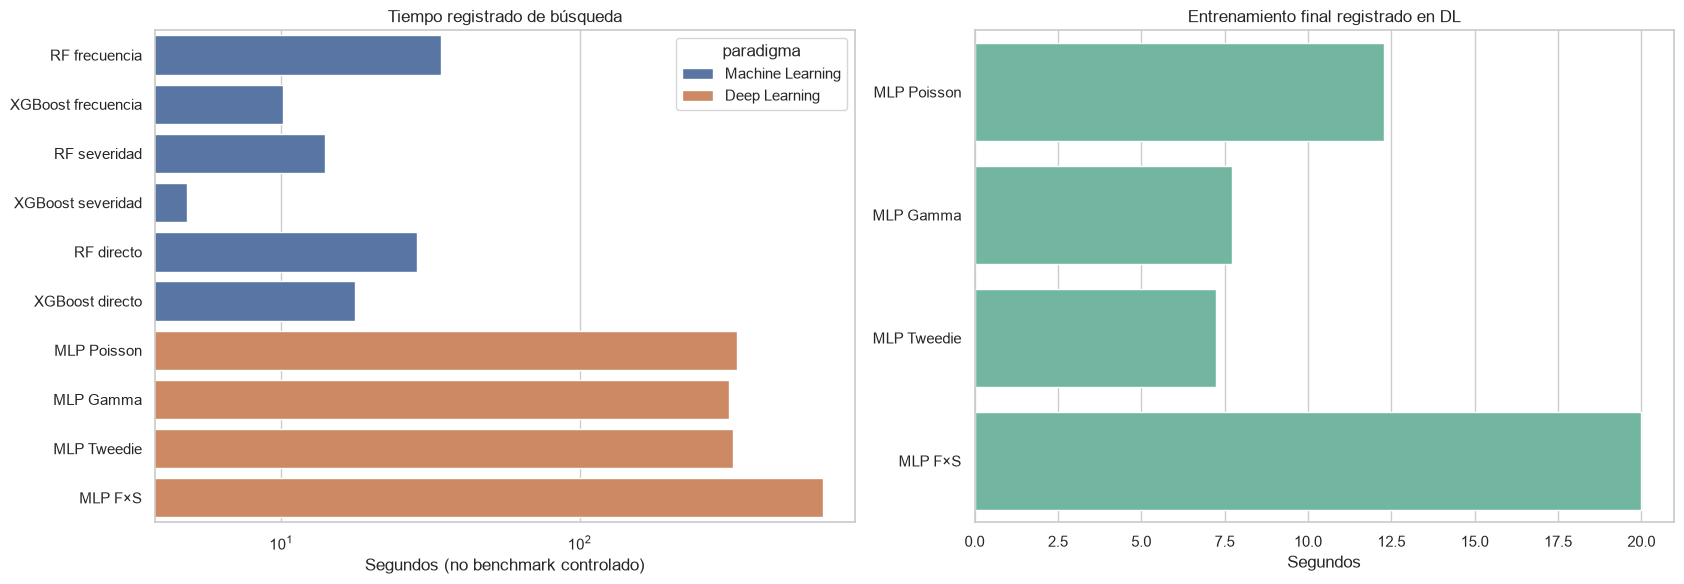

In [177]:
plot_compute = compute_records.dropna(subset=["búsqueda_s"]).copy()
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=plot_compute, y="modelo", x="búsqueda_s", hue="paradigma", dodge=False, ax=axes[0])
axes[0].set(title="Tiempo registrado de búsqueda", xlabel="Segundos (no benchmark controlado)", ylabel="")
axes[0].set_xscale("log")

dl_train = compute_records.dropna(subset=["entrenamiento_final_s"])
sns.barplot(data=dl_train, y="modelo", x="entrenamiento_final_s", color="#66c2a5", ax=axes[1])
axes[1].set(title="Entrenamiento final registrado en DL", xlabel="Segundos", ylabel="")

plt.tight_layout(); plt.show()

Los tiempos muestran que, en este experimento, la búsqueda bayesiana de cada MLP costó alrededor de 5–5.6 minutos, mientras los `RandomizedSearchCV` reportados tardaron aproximadamente 5–34 segundos. No debe concluirse que DL es siempre un múltiplo fijo más lento: ML utilizó `n_jobs=-1`, los espacios y números de fits fueron distintos, y no se registraron hardware, calentamiento ni latencias bajo un protocolo común.

Dentro de DL, el entrenamiento de una configuración elegida tardó aproximadamente 7–12 segundos, muy por debajo del HPO. Esto distingue el costo de desarrollar/seleccionar el modelo del costo de volver a entrenarlo una vez fijada la arquitectura.

## 37. Costo de inferencia

No se midió latencia de inferencia con un benchmark común, por lo que no se reportan milisegundos inventados. La comparación sólo puede ser estructural:

| Familia | Operación de inferencia | Implicación |
|---|---|---|
| GLM/OLS | producto matriz–vector y función de enlace | muy compacto; sencillo de implementar y auditar |
| Random Forest | recorrer 300 árboles y promediar | costo crece con número y profundidad de árboles; paralelizable |
| XGBoost | recorrer secuencialmente 150–200 árboles de profundidad 2 | árboles poco profundos, pero suma secuencial |
| MLP | multiplicaciones densas entre capas | redes finales pequeñas y vectorizables; requieren el pipeline de escalamiento |
| F×S | dos inferencias y un producto | costo y mantenimiento de ambos componentes; pueden reutilizarse para otros análisis |

Una comparación operativa fuerte requeriría medir el mismo lote, mismo hardware, mismo número de hilos, mismo formato de datos y varias repeticiones después de calentamiento.

## 38. Interpretabilidad y gobernanza

La interpretabilidad tiene varias dimensiones: comprensión global de la fórmula, explicación de una predicción individual, trazabilidad de componentes y facilidad de monitoreo.

In [178]:
interpretability = pd.DataFrame([
    {"familia":"GLM/OLS","global":"Alta","individual":"Alta","componentes":"Coeficientes multiplicativos, intervalos y signos","limitación":"Depende de especificar correctamente transformaciones e interacciones"},
    {"familia":"F×S","global":"Alta en modelos estadísticos; media en ML/DL","individual":"Descomponible","componentes":"Separa frecuencia y severidad","limitación":"Los errores de componentes se propagan e interactúan"},
    {"familia":"Random Forest","global":"Media-baja","individual":"Post-hoc","componentes":"Importancias, PDP/SHAP","limitación":"Muchos árboles; importancia puede ser sesgada o inestable"},
    {"familia":"XGBoost","global":"Media-baja","individual":"Post-hoc","componentes":"SHAP y perfiles","limitación":"Interacciones distribuidas entre árboles secuenciales"},
    {"familia":"MLP","global":"Baja","individual":"Post-hoc","componentes":"Perfiles, gradients o SHAP","limitación":"Pesos no tienen interpretación actuarial directa"},
    {"familia":"Directo","global":"Depende del algoritmo","individual":"Una sola predicción","componentes":"No requiere multiplicar F y S","limitación":"No explica si el riesgo procede de frecuencia o severidad"},
])
display(interpretability)

,familia,global,individual,componentes,limitación
0,GLM/OLS,Alta,Alta,"Coeficientes multiplicativos, intervalos y signos",Depende de especificar correctamente transform...
1,F×S,Alta en modelos estadísticos; media en ML/DL,Descomponible,Separa frecuencia y severidad,Los errores de componentes se propagan e inter...
2,Random Forest,Media-baja,Post-hoc,"Importancias, PDP/SHAP",Muchos árboles; importancia puede ser sesgada ...
3,XGBoost,Media-baja,Post-hoc,SHAP y perfiles,Interacciones distribuidas entre árboles secue...
4,MLP,Baja,Post-hoc,"Perfiles, gradients o SHAP",Pesos no tienen interpretación actuarial directa
5,Directo,Depende del algoritmo,Una sola predicción,No requiere multiplicar F y S,No explica si el riesgo procede de frecuencia ...


Los GLM ofrecen la explicación más directa: con enlace log, exponenciar un coeficiente produce un efecto multiplicativo manteniendo las demás variables constantes. Además, los resúmenes incluyen errores estándar e intervalos. Log+Duan añade una capa de explicación porque la retransfomación requiere el factor de smearing.

F×S añade valor interpretativo incluso cuando sus componentes son complejos: permite atribuir cambios a frecuencia o severidad y monitorear ambos procesos. Los modelos directos son operativamente más compactos, pero pierden esa descomposición causal-actuarial. Para árboles y redes, explicaciones post-hoc son útiles, aunque no equivalen a una fórmula global identificable.

## 39. Sensibilidad a tuning

- **GLM/OLS:** tienen pocos hiperparámetros de optimización. Su sensibilidad principal está en la especificación: link, distribución, transformaciones, términos no lineales y selección de variables. La potencia Tweedie se eligió en validation y quedó fijada en 1.25.
- **Random Forest:** profundidad, tamaño mínimo de hoja y fracción de variables controlan el sesgo–varianza. La búsqueda eligió configuraciones regularizadas; el RF directo mantuvo profundidad ilimitada, compensada por hojas de al menos 30 observaciones.
- **XGBoost:** número de árboles y learning rate deben leerse conjuntamente. Profundidad, child weight, subsampling y L1/L2 interactúan. Los tres modelos finales convergieron a árboles de profundidad 2 y regularización fuerte.
- **MLP:** arquitectura, learning rate, dropout, L2 y early stopping interactúan. Un buen resultado no se atribuye sólo al número de parámetros; depende del camino de optimización y de la semilla.

La mayor flexibilidad aumenta la necesidad de un protocolo de validación claro. No implica necesariamente mayor modelo final: el HPO de severidad y Tweedie seleccionó redes de una sola capa.

## 40. Estabilidad observada en Deep Learning

Cada configuración DL seleccionada se reconstruyó con semillas 42, 123 y 2026. Se reportan la mejor época y el criterio de validation. Las escalas no son comparables entre tareas: frecuencia usa `val_loss` Poisson penalizada, severidad reporta Gamma deviance externa y Tweedie reporta Tweedie deviance externa.

In [179]:
dl_stability = pd.DataFrame([
    {"tarea":"Frecuencia","seed":42,"best_epoch":51,"validation_metric":0.427359,"métrica":"val_loss penalizada"},
    {"tarea":"Frecuencia","seed":123,"best_epoch":21,"validation_metric":0.430866,"métrica":"val_loss penalizada"},
    {"tarea":"Frecuencia","seed":2026,"best_epoch":34,"validation_metric":0.429259,"métrica":"val_loss penalizada"},
    {"tarea":"Severidad","seed":42,"best_epoch":37,"validation_metric":0.314234,"métrica":"Gamma deviance"},
    {"tarea":"Severidad","seed":123,"best_epoch":25,"validation_metric":0.304036,"métrica":"Gamma deviance"},
    {"tarea":"Severidad","seed":2026,"best_epoch":60,"validation_metric":0.317215,"métrica":"Gamma deviance"},
    {"tarea":"Prima pura directa","seed":42,"best_epoch":5,"validation_metric":1123.874512,"métrica":"Tweedie deviance"},
    {"tarea":"Prima pura directa","seed":123,"best_epoch":4,"validation_metric":1130.508301,"métrica":"Tweedie deviance"},
    {"tarea":"Prima pura directa","seed":2026,"best_epoch":13,"validation_metric":1135.132446,"métrica":"Tweedie deviance"},
])

stability_summary = dl_stability.groupby(["tarea", "métrica"]).agg(
    épocas_media=("best_epoch", "mean"),
    épocas_std=("best_epoch", "std"),
    épocas_mín=("best_epoch", "min"),
    épocas_máx=("best_epoch", "max"),
    métrica_media=("validation_metric", "mean"),
    métrica_std=("validation_metric", "std"),
    métrica_mín=("validation_metric", "min"),
    métrica_máx=("validation_metric", "max"),
).reset_index()
display(dl_stability)
display(stability_summary.round(6))

,tarea,seed,best_epoch,validation_metric,métrica
0,Frecuencia,42,51,0.427359,val_loss penalizada
1,Frecuencia,123,21,0.430866,val_loss penalizada
2,Frecuencia,2026,34,0.429259,val_loss penalizada
3,Severidad,42,37,0.314234,Gamma deviance
4,Severidad,123,25,0.304036,Gamma deviance
5,Severidad,2026,60,0.317215,Gamma deviance
6,Prima pura directa,42,5,1123.874512,Tweedie deviance
7,Prima pura directa,123,4,1130.508301,Tweedie deviance
8,Prima pura directa,2026,13,1135.132446,Tweedie deviance


,tarea,métrica,épocas_media,épocas_std,épocas_mín,épocas_máx,métrica_media,métrica_std,métrica_mín,métrica_máx
0,Frecuencia,val_loss penalizada,35.333333,15.044379,21,51,0.429161,0.001756,0.427359,0.430866
1,Prima pura directa,Tweedie deviance,7.333333,4.932883,4,13,1129.838420,5.658783,1123.874512,1135.132446
2,Severidad,Gamma deviance,40.666667,17.785762,25,60,0.311828,0.006911,0.304036,0.317215


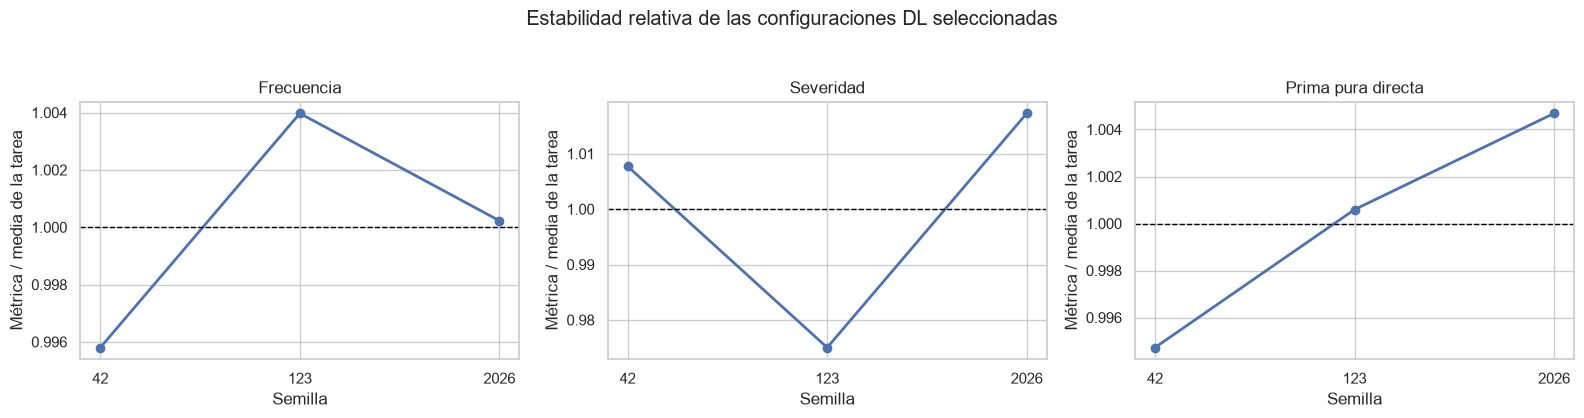

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, task in zip(axes, ["Frecuencia", "Severidad", "Prima pura directa"]):
    subset = dl_stability.loc[dl_stability["tarea"].eq(task)]
    normalized = subset["validation_metric"] / subset["validation_metric"].mean()
    ax.plot(subset["seed"].astype(str), normalized, marker="o", lw=2)
    ax.axhline(1, color="black", ls="--", lw=1)
    ax.set(title=task, xlabel="Semilla", ylabel="Métrica / media de la tarea")
fig.suptitle("Estabilidad relativa de las configuraciones DL seleccionadas", y=1.04)
plt.tight_layout(); plt.show()

Las métricas de validation son relativamente estables entre semillas, pero la mejor época varía: 21–51 en frecuencia, 25–60 en severidad y 4–13 en Tweedie directo. Esto indica que el nivel predictivo de la configuración es más estable que la trayectoria exacta de optimización.

La estabilidad se estudió formalmente sólo para DL. Los modelos ML fijaron `random_state=42`, pero los CSV no contienen repeticiones por semilla; no debe inferirse estabilidad empírica equivalente a partir de una sola ejecución. Los GLM son deterministas condicionado al dataset y la especificación, aunque siguen siendo sensibles a cambios de fórmula y datos.

## 41. Diferencia de protocolos finales en Deep Learning

La frecuencia DL tomó la mediana de las mejores épocas (`34`), reajustó el preprocesamiento y entrenó el modelo final con las 8,000 pólizas, sin validation durante ese refit. Severidad y Tweedie directo mantuvieron el split train/validation y conservaron pesos mediante early stopping.

Por tanto, las diferencias finales combinan:

\[
\text{efecto del algoritmo}
+\text{efecto de la cantidad de datos usada para ajustar pesos}
+\text{efecto del protocolo de parada/refit}.
\]

No es posible atribuir toda diferencia entre los tres MLP únicamente a la dificultad del target o a la arquitectura.

## 42. `val_loss` penalizada frente a deviance externa

Los tuners de Keras minimizaron `val_loss`. Como L2 estaba incluida mediante `kernel_regularizer`, el objetivo de HPO fue conceptualmente:

\[
\text{pérdida predictiva de validation}
+\text{penalización L2}.
\]

Las Poisson, Gamma y Tweedie deviances externas se calcularon sobre las predicciones y **no incluyen** la penalización. Esto no invalida HPO: significa que la selección favorece un compromiso entre ajuste y complejidad, mientras la evaluación final mide sólo desempeño predictivo. No se deben comparar numéricamente `val_loss` y deviance externa ni afirmar que el tuner optimizó exactamente la tabla final.

## 43. Cautelas metodológicas transversales

1. **Uso de test:** test no participó en fitting, CV, HPO ni early stopping, pero fue inspeccionado durante el desarrollo. Debe describirse como conjunto común de evaluación, no como un holdout nunca observado.
2. **No retuning:** ninguna observación de este notebook autoriza modificar hiperparámetros o elegir una nueva especificación. Eso constituiría selección post-hoc sobre test.
3. **Pearson y Spearman:** Pearson mide asociación lineal y sensibilidad a escala; Spearman describe ordenamiento. Ninguno sustituye calibración.
4. **Tiempos no controlados:** faltan cronometrajes equivalentes para GLM, entrenamiento final ML e inferencia. Los tiempos registrados mezclan diferentes cantidades de trabajo y paralelización.
5. **Estabilidad incompleta:** DL tiene tres semillas; ML no. CV cuantifica variación entre folds, no reemplaza una repetición completa del pipeline con otras semillas.
6. **Complejidad total:** no debe reducirse al conteo de parámetros. Incluye diseño de variables, búsqueda, mantenimiento, explicación, monitoreo y dependencia de software.

## 44. Síntesis de complejidad y costo

- Los modelos estadísticos son los más compactos e interpretables, pero dependen de una especificación adecuada. En este DGP esa especificación es una ventaja material.
- Random Forest y XGBoost requieren búsqueda y explicaciones post-hoc. Las configuraciones finales resultaron fuertemente regularizadas, no máximamente complejas.
- Las redes finales son pequeñas, pero su HPO y estabilidad añaden un costo de desarrollo considerable. El entrenamiento posterior de una arquitectura fija es mucho más barato que la búsqueda inicial.
- F×S cuesta dos pipelines, pero ofrece trazabilidad de frecuencia y severidad y permite reutilizar componentes. El directo reduce componentes operativos, a cambio de perder esa descomposición.
- El costo de inferencia no fue medido; sólo puede discutirse por estructura. Un benchmark futuro necesitaría condiciones idénticas.

La complejidad debe justificarse por mejoras que sobrevivan a evaluación observable, oracle, calibración, estabilidad y necesidades de gobernanza. Esta fase no modifica la selección congelada ni declara un ganador global.

# Fase 6 — Síntesis final del proyecto

## 45. Respuesta ejecutiva

> **¿Cuánto valor adicional aporta la complejidad de Machine Learning y Deep Learning frente a modelos estadísticos clásicos correctamente especificados en este DGP controlado?**

En este experimento, el valor adicional de la complejidad es **limitado, localizado y dependiente del objetivo**, no general. ML y DL producen en algunos casos pequeñas mejoras frente a las realizaciones observadas o mejoras dentro de una estrategia concreta —especialmente XGBoost y MLP directos frente a sus equivalentes F×S—, pero no superan de forma consistente a los modelos estadísticos en recuperación del oracle, calibración de extremos, interpretabilidad ni costo de desarrollo.

La explicación está conectada con el diseño del DGP: frecuencia, severidad y prima pura fueron generadas con estructuras que los GLM con enlace log y términos adecuados representan razonablemente bien. Cuando la forma paramétrica está cerca de la verdad, la flexibilidad adicional tiene poco sesgo que corregir y sí introduce varianza, regularización, tuning y riesgo de comprimir extremos. Este resultado no demuestra que GLM sea universalmente superior; demuestra que la complejidad debe resolver una deficiencia real de especificación para justificar su costo.

## 46. Escala de las diferencias observadas y oracle

La siguiente tabla no construye un ranking. Resume cuánto se separan el valor mínimo y máximo entre los modelos finales dentro de cada tarea. La amplitud observada se contrasta con la amplitud de Oracle RMSE.

In [181]:
def metric_span(frame, task, deviance_column):
    return {
        "tarea": task,
        "modelos": len(frame),
        "RMSE observado mínimo": frame["RMSE_test"].min(),
        "RMSE observado máximo": frame["RMSE_test"].max(),
        "amplitud RMSE observado (%)": 100 * (frame["RMSE_test"].max() / frame["RMSE_test"].min() - 1),
        "deviance mínima": frame[deviance_column].min(),
        "deviance máxima": frame[deviance_column].max(),
        "amplitud deviance (%)": 100 * (frame[deviance_column].max() / frame[deviance_column].min() - 1),
        "Oracle RMSE mínimo": frame["Oracle_RMSE"].min(),
        "Oracle RMSE máximo": frame["Oracle_RMSE"].max(),
        "amplitud Oracle RMSE (%)": 100 * (frame["Oracle_RMSE"].max() / frame["Oracle_RMSE"].min() - 1),
    }

materiality_overview = pd.DataFrame([
    metric_span(frequency_diagnostics, "Frecuencia", "Poisson_deviance_test"),
    metric_span(severity_diagnostics, "Severidad", "Gamma_deviance_test"),
    metric_span(pure_premium_diagnostics, "Prima pura", "Tweedie_deviance_test"),
])
display(materiality_overview.round(4))

,tarea,modelos,RMSE observado mínimo,RMSE observado máximo,amplitud RMSE observado (%),deviance mínima,deviance máxima,amplitud deviance (%),Oracle RMSE mínimo,Oracle RMSE máximo,amplitud Oracle RMSE (%)
0,Frecuencia,4,0.3910,0.3921,0.2837,0.5872,0.5925,0.9133,0.0179,0.0465,160.2763
1,Severidad,5,8807.1037,8962.8628,1.7686,0.3157,0.3250,2.9707,1043.5305,1643.3485,57.4797
2,Prima pura,8,6382.1159,6448.4118,1.0388,1159.8191,1184.5414,2.1316,280.8709,828.1799,194.8614


La escala cambia radicalmente según la referencia. La amplitud entre RMSE observados es aproximadamente 0.3% en frecuencia, 1.8% en severidad y 1.0% en prima pura. Las deviances abarcan menos de 1% en frecuencia y alrededor de 2%–3% en severidad y prima pura. En cambio, la amplitud de Oracle RMSE es aproximadamente 160%, 57% y 195%, respectivamente.

Esto no convierte automáticamente toda diferencia oracle en “estadísticamente significativa”: no se construyeron intervalos de confianza o bootstrap pareado para las diferencias. Sí muestra que, descriptivamente, las realizaciones ruidosas ocultan diferencias estructurales mucho mayores. Las mejoras observadas de décimas de punto porcentual deben tratarse como pequeñas hasta demostrar estabilidad fuera de esta muestra.

## 47. Desempeño frente a realizaciones observadas

### Frecuencia

Los cuatro RMSE están alrededor de `0.391–0.392`. XGBoost, RF y MLP no producen una mejora observable material frente al GLM; las diferencias de Poisson deviance son inferiores a 1%. Con conteos de baja frecuencia, una gran parte del error individual es variación Poisson que ningún modelo de la media puede eliminar.

### Severidad

MAE, RMSE y Gamma deviance también están próximos. Log+Duan y XGBoost presentan pequeñas ventajas en algunas métricas observadas, pero son del orden de menos de 1% frente al GLM Gamma en los casos más favorables. El oracle mismo tiene RMSE observado cercano a 8,743, frente a 8,807–8,963 para los modelos: casi todo el error corresponde a variación del claim.

### Prima pura

Los RMSE observados se concentran alrededor de 6,382–6,449. XGBoost directo obtiene una Tweedie deviance ligeramente menor que los GLM, pero la diferencia es pequeña. Además, 85.4% de los costos son cero: MAE puede premiar predicciones bajas y no debe interpretarse como una medida pura de recuperación de la media.

**Conclusión observable:** la complejidad no genera una mejora grande y consistente sobre las realizaciones. Donde aparecen ventajas, suelen ser pequeñas respecto al nivel de ruido y no justifican por sí solas una conclusión fuerte.

## 48. Recuperación del oracle

Aquí la evidencia es más clara. En frecuencia, GLM Poisson obtiene Oracle RMSE `≈0.0179`, frente a `0.0318` para XGBoost, `0.0375` para RF y `0.0465` para MLP. En severidad, GLM Gamma y log+Duan quedan cerca de `1,044–1,068`, mientras XGBoost, RF y MLP se sitúan aproximadamente en `1,285`, `1,432` y `1,643`. En prima pura, Poisson×Gamma y GLM Tweedie quedan cerca de `281–288`; los modelos flexibles abarcan aproximadamente `523–828`.

Estas diferencias son materialmente relevantes para este DGP: no son décimas de punto en una métrica dominada por ruido, sino aumentos grandes en el error del componente que el modelo pretende aprender. La ventaja estadística procede de coincidencia estructural, no simplemente de menor número de parámetros.

El oracle también muestra por qué algunos resultados observados aparentemente mejores no deben sobreinterpretarse. Un modelo puede acercarse por azar a los costos o claims realizados y, simultáneamente, alejarse de la esperanza condicional verdadera.

## 49. Calibración y discriminación del riesgo

Los modelos estadísticos mantienen en general una relación más cercana a la diagonal y ratios por decil próximos a uno. Los modelos flexibles tienden a comprimir la distribución: elevan predicciones de bajo riesgo y reducen las de alto riesgo. Esa compresión es material cuando alcanza aproximadamente 20%–40% en los extremos, porque puede producir subsidios cruzados aun si la media total parece razonable.

Pearson y Spearman separan dos propiedades:

- Pearson alto exige una relación aproximadamente lineal y una escala adecuada.
- Spearman alto exige preservar el orden, aunque la escala esté desplazada o comprimida.

MLP Poisson y MLP F×S ilustran la diferencia: conservan un Spearman relativamente alto, pero Pearson y la calibración por deciles revelan problemas de escala. Por tanto, no es correcto describir Pearson como “ranking”; para segmentación, Spearman es más directo, y para tarifa se necesita además calibración.

## 50. Robustez, interpretabilidad y costo computacional

Los GLM son deterministas condicionado al dataset y la fórmula, compactos y auditables mediante coeficientes, intervalos y efectos multiplicativos. Su fragilidad potencial es la mala especificación; en este DGP esa fragilidad fue reducida porque se conocían transformaciones relevantes.

Random Forest y XGBoost requieren explicar cientos de árboles mediante herramientas post-hoc. Las redes requieren además escalamiento, optimización no convexa y explicación indirecta. Las repeticiones DL mostraron métricas de validation razonablemente estables, pero mejores épocas variables. ML no fue repetido con varias semillas, por lo que su estabilidad empírica completa no está demostrada.

Los tiempos tampoco son equivalentes: las búsquedas ML registradas tardaron aproximadamente 5–34 segundos con paralelización; cada HPO DL, unos 315–337 segundos. El refit de una red ya seleccionada tardó 7–12 segundos. No hay un benchmark homogéneo de GLM, entrenamiento final ML o inferencia, de modo que sólo puede concluirse que HPO añade costo de desarrollo, no una razón universal de velocidades.

## 51. Beneficio marginal del HPO

El HPO no produjo una mejora uniforme. La tabla usa las comparaciones heurístico/final conservadas en `05_deep_learning.ipynb`. Un porcentaje negativo implica menor error después de HPO; la correlación se expresa como diferencia absoluta.

In [182]:
hpo_comparisons = pd.DataFrame([
    {"tarea":"Frecuencia DL","MAE_antes":0.260476,"MAE_después":0.270559,"deviance_antes":0.592861,"deviance_después":0.592096,"Oracle_RMSE_antes":0.033638,"Oracle_RMSE_después":0.046499,"correlación_antes":0.914875,"correlación_después":0.837959},
    {"tarea":"Severidad DL","MAE_antes":6011.442383,"MAE_después":5820.470703,"deviance_antes":0.336529,"deviance_después":0.322431,"Oracle_RMSE_antes":2057.525820,"Oracle_RMSE_después":1643.348563,"correlación_antes":0.936759,"correlación_después":0.950288},
    {"tarea":"Prima pura DL directa","MAE_antes":3158.505859,"MAE_después":3170.163330,"deviance_antes":1182.915771,"deviance_después":1175.522583,"Oracle_RMSE_antes":719.436954,"Oracle_RMSE_después":636.741510,"correlación_antes":0.906065,"correlación_después":0.925930},
])
for metric in ["MAE", "deviance", "Oracle_RMSE"]:
    hpo_comparisons[f"Δ {metric} (%)"] = 100 * (
        hpo_comparisons[f"{metric}_después"] / hpo_comparisons[f"{metric}_antes"] - 1
    )
hpo_comparisons["Δ correlación"] = hpo_comparisons["correlación_después"] - hpo_comparisons["correlación_antes"]
display(hpo_comparisons[[
    "tarea", "Δ MAE (%)", "Δ deviance (%)", "Δ Oracle_RMSE (%)", "Δ correlación"
]].round(3))

,tarea,Δ MAE (%),Δ deviance (%),Δ Oracle_RMSE (%),Δ correlación
0,Frecuencia DL,3.871,-0.129,38.234,-0.077
1,Severidad DL,-3.177,-4.189,-20.130,0.014
2,Prima pura DL directa,0.369,-0.625,-11.494,0.020


En severidad, HPO DL aporta una mejora clara: Gamma deviance baja alrededor de 4.2% y Oracle RMSE cerca de 20%. En Tweedie directo, la mejora observable de deviance es modesta (`≈0.6%`), pero Oracle RMSE baja alrededor de 11.5%. En frecuencia ocurre lo contrario: la deviance mejora apenas `≈0.13%`, mientras Oracle RMSE empeora cerca de 38% y la correlación disminuye.

Por tanto, HPO es una herramienta de selección, no una garantía de mejora en todos los criterios. En frecuencia, además, el modelo final utilizó un refit con 8,000 pólizas distinto del protocolo de severidad y Tweedie; no puede atribuirse causalmente todo el cambio al buscador. En ML también hubo casos donde tuning corrigió configuraciones iniciales claramente sobreajustadas, pero las mejoras finales frente a GLM siguieron siendo pequeñas o inexistentes.

El beneficio marginal debe juzgarse frente a su costo y al criterio optimizado. Keras seleccionó `val_loss` con L2, mientras las deviances externas excluyen la penalización; por diseño, no se optimizó exactamente la tabla final.

## 52. Frecuencia × Severidad frente a modelado directo

No existe una estrategia universalmente superior:

- En modelos estadísticos, Poisson×Gamma y GLM Tweedie son casi equivalentes; el directo mejora ligeramente el oracle, mientras F×S ofrece la descomposición más transparente.
- En Random Forest, F×S recupera mejor la prima pura que el modelo directo.
- En XGBoost y MLP, los modelos directos reducen de forma relevante Oracle RMSE frente a sus productos F×S.

La descomposición mostró que el error de frecuencia fue la mayor contribución media al error F×S, seguido de severidad e interacción. Modelar directamente puede evitar esa multiplicación de errores, pero pierde trazabilidad y no garantiza mejor ordenamiento, como muestra RF directo.

La decisión práctica depende del uso: F×S favorece explicación, monitoreo y reutilización de componentes; el directo puede mejorar la prima final cuando aprende bien la señal agregada. La evidencia del algoritmo concreto debe decidir, no una preferencia abstracta por una estrategia.

## 53. Cuándo una diferencia es material

En este proyecto se considera **descriptivamente material** una diferencia que cambia de forma visible la recuperación oracle, la calibración en segmentos o la estabilidad operativa. Ejemplos: duplicar Oracle RMSE, desviar 20%–40% los deciles extremos o reducir Oracle RMSE 20% dentro de una estrategia.

Se considera **pequeña y no concluyente por sí sola** una diferencia de décimas de punto porcentual en RMSE o deviance observada, especialmente con targets dominados por ruido, sin intervalos de incertidumbre y después de haber inspeccionado test durante el desarrollo.

Esta regla es práctica, no una prueba estadística. Una extensión rigurosa podría usar bootstrap pareado por póliza —y agrupado por `policy_id` para claims— sobre un nuevo conjunto nunca inspeccionado. No se implementa aquí porque implicaría ampliar el protocolo después de revisar test.

## 54. Conclusión final

La complejidad de ML y DL **sí aporta capacidades**: aprende relaciones sin especificarlas manualmente, conserva ordenamiento útil en varios casos y, bajo modelado directo, mejora algunas alternativas complejas F×S. HPO también puede reducir de forma importante el error oracle de una configuración neuronal.

Sin embargo, en este DGP esas capacidades no se traducen en una ganancia predictiva general frente a modelos estadísticos correctamente especificados. Las mejoras observadas son pequeñas y no consistentes; la recuperación oracle y la calibración de extremos favorecen ampliamente a los modelos clásicos; y el costo adicional aparece en búsqueda, estabilidad, explicación y gobernanza.

La lección no es “usar siempre GLM”. Es más precisa:

> **Cuando la estructura estadística representa razonablemente el proceso generador, la complejidad adicional debe demostrar una mejora material y reproducible en señal, calibración o decisión de negocio. Si sólo mejora marginalmente una realización ruidosa, no compensa automáticamente su costo.**

En datos reales el DGP no se conoce y pueden existir interacciones o no linealidades omitidas; allí ML/DL pueden aportar más valor. Pero ese valor debe demostrarse con validación verdaderamente externa, calibración segmentada, estabilidad y una comparación de costo total. Este experimento muestra precisamente por qué una especificación clásica bien elegida sigue siendo una referencia exigente y no un baseline trivial.

No se fuerza un ganador universal, no se retunea ningún modelo y todas las conclusiones quedan condicionadas al DGP, tamaño muestral, features, protocolos y test utilizados.